# FCDD polar unwrap 




In [ ]:
from pathlib import Path
import shutil

# ============================================================
# TP26 depthmap dataset setup
# ============================================================
# Pôvodný Roboflow classification export má štruktúru:
# train/good, train/bad, valid/good, valid/bad, test/good, test/bad
# Náš FCDD notebook očakáva:
# train/good, val/good, val/anomaly, test/good, test/anomaly
# Preto si raz vytvoríme "fcdd_ready" kópiu s potrebnými názvami priečinkov.

DATASET_SPLITS_ROOT = Path(r'C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits')
RAW_CLASS_ROOT = DATASET_SPLITS_ROOT / 'TP26_depthmap_classification'
DATA_ROOT = DATASET_SPLITS_ROOT / 'TP26_depthmap_fcdd_ready'
CACHE_ROOT = DATASET_SPLITS_ROOT / 'TP26_depthmap_polar_cache_v1'
OUT_DIR = r'runs/fcdd_tp26_depthmap_v1'


def prepare_tp26_fcdd_dataset(src: Path, dst: Path) -> None:
    """Pripraví dáta do štruktúry, ktorú používa FCDD notebook.

    FCDD sa trénuje iba na dobrých kusoch z train/good.
    Trieda bad sa používa ako anomaly iba pri validácii a teste.
    """
    if not src.exists():
        raise FileNotFoundError(f'Nenájdený zdrojový dataset: {src}')

    mapping = [
        ('train', 'good', 'train', 'good'),
        ('train', 'bad',  'train', 'anomaly'),   # nekŕmime do tréningu FCDD, ale nechávame pre prípadnú kontrolu
        ('valid', 'good', 'val',   'good'),
        ('valid', 'bad',  'val',   'anomaly'),
        ('test',  'good', 'test',  'good'),
        ('test',  'bad',  'test',  'anomaly'),
    ]

    for src_split, src_cls, dst_split, dst_cls in mapping:
        s = src / src_split / src_cls
        d = dst / dst_split / dst_cls
        if not s.exists():
            raise FileNotFoundError(f'Chýba priečinok: {s}')
        d.mkdir(parents=True, exist_ok=True)
        for p in s.iterdir():
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
                target = d / p.name
                if not target.exists():
                    shutil.copy2(p, target)

    print('TP26 depthmap FCDD-ready dataset pripravený tu:', dst)
    for split in ['train', 'val', 'test']:
        for cls in ['good', 'anomaly']:
            folder = dst / split / cls
            if folder.exists():
                n = len([p for p in folder.iterdir() if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}])
                print(f'{split:5s}/{cls:8s}: {n}')


prepare_tp26_fcdd_dataset(RAW_CLASS_ROOT, DATA_ROOT)

CFG = {
    'data_root': str(DATA_ROOT),
    'cache_root': str(CACHE_ROOT),
    'out_dir': OUT_DIR,

    # PRE PRVÝ BEH NA DEPTHMAPÁCH MUSÍ BYŤ False, aby sa model normálne natrénoval.
    # Keď už bude checkpoint hotový a chceš iba prerenderovať heatmapy/report, prepni na True.
    'only_export_heatmaps': False,

    # polar representation
    'radial_bins': 128,
    'angular_bins': 512,
    'unwrap_margin_frac': 0.00,

    # depthmap preprocessing: odlesky neriešime, používame grayscale mapu hĺbky
    'suppress_reflections': False,
    'illum_sigma_px': 35.0,
    'illum_blend': 0.50,
    'glare_clip_q': 0.985,
    'glare_blur_sigma_px': 5.0,
    'glare_dilate_px': 2,
    'glare_min_v': 0.72,
    'glare_sat_max': 0.80,

    # high-pass unwrap preprocessing
    'hp_sigma_r': 1.5,
    'hp_sigma_t': 14.0,
    'hp_blend': 0.25,

    # training
    'batch_size': 8,
    'epochs': 24,
    'lr': 1e-4,
    'weight_decay': 1e-6,
    'base_channels': 32,
    'grayscale': True,
    'seed': 42,
    'threshold_q': 0.70,
    'topk_ratio': 0.015,
    'train_edge_margin_frac': 0.04,
    'score_edge_margin_frac': 0.02,

    # threshold kalibrácia z validačnej množiny
    'use_val_threshold_sweep': True,
    'threshold_selection_mode': 'specificity_guard',
    'min_val_anomaly_recall': 0.80,
    'min_val_specificity': 0.60,
    'threshold_prefer_recall_margin': 0.004,

    # classification score maska
    'score_center_trim_frac': 0.13,
    'score_edge_min_weight': 0.10,
    'score_smooth_kernel': 5,

    # hybrid heatmapy — nemení klasifikáciu, iba vizualizáciu/localization
    'use_hybrid_heatmap': True,
    'heatmap_model_weight': 0.72,
    'heatmap_scratch_weight': 0.28,
    'heatmap_scratch_peak_boost': 0.78,

    # display/postprocessing heatmapy — iba vizualizácia, nie classification score
    'heatmap_sparse_q': 0.72,
    'heatmap_display_gamma': 1.28,
    'heatmap_min_component_area': 3,
    'heatmap_min_component_peak': 0.10,
    'overlay_activation_floor': 0.21,
    'overlay_gamma': 1.60,

    # mäkké utlmenie vnútorného/vonkajšieho okraja prstenca pri heatmape
    'heatmap_edge_fade_frac': 0.115,
    'heatmap_edge_min_weight': 0.035,

    # potláča dlhé kruhové hrany/ring artefakty v unwrape, ale ponechá lokálne hotspoty
    'heatmap_suppress_circular_bg': True,
    'heatmap_circular_bg_strength': 0.56,
    'heatmap_circular_bg_sigma_t': 26.0,
    'heatmap_circular_bg_q': 0.60,

    # detail mapa pre lokálne hĺbkové zmeny/defekty
    'scratch_detail_blur_r': 1.0,
    'scratch_detail_blur_t': 16.0,
    'scratch_detail_dark_weight': 1.30,
    'scratch_detail_bright_weight': 0.05,
    'scratch_detail_q_hi': 0.992,
    'scratch_detail_gradient_weight': 0.30,
    'scratch_detail_keep_q': 0.72,
    'scratch_detail_gamma': 1.15,

    # potlačenie jasných izolovaných hotspotov v detail mape
    'scratch_specular_suppress': True,
    'scratch_specular_q': 0.965,
    'scratch_specular_strength': 0.98,
    'scratch_preprocess_reflections': False,

    # finálny display guard proti špeculárnym odleskom
    'heatmap_glare_suppress': True,
    'heatmap_glare_q': 0.965,
    'heatmap_glare_min_v': 0.66,
    'heatmap_glare_sat_max': 0.82,
    'heatmap_glare_strength': 0.72,
    'heatmap_glare_blur_sigma': 3.0,

    # cleaning malých bodiek pre overlay
    'heatmap_opening_px': 1,
    'heatmap_closing_px': 1,

    # output
    'max_heatmaps_per_split': 80,
    'heatmap_limit_per_class': 60,
    'num_workers': 0,
    'persistent_workers': False,
    'pin_memory': False,

    # nechávame False: ak cache ešte nie je, vytvorí sa; ak už je, preskočí existujúce súbory
    'rebuild_cache': False,
}

print('DATA_ROOT =', CFG['data_root'])
print('CACHE_ROOT =', CFG['cache_root'])
print('OUT_DIR =', CFG['out_dir'])


TP26 depthmap FCDD-ready dataset pripravený tu: C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits\TP26_depthmap_fcdd_ready
train/good    : 177
train/anomaly : 159
val  /good    : 17
val  /anomaly : 15
test /good    : 8
test /anomaly : 7
DATA_ROOT = C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits\TP26_depthmap_fcdd_ready
CACHE_ROOT = C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits\TP26_depthmap_polar_cache_v1
OUT_DIR = runs/fcdd_tp26_depthmap_v1


In [2]:

import json
import math
import random
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


# =========================
# Utility
# =========================
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def list_images(root: Path) -> List[Path]:
    return sorted([p for p in Path(root).rglob('*') if p.suffix.lower() in IMG_EXTS])

def pil_to_rgb01(img: Image.Image) -> np.ndarray:
    arr = np.asarray(img.convert('RGB'), dtype=np.float32) / 255.0
    return np.clip(arr, 0.0, 1.0)


def annulus_mask_from_geom(shape_hw: Tuple[int, int], geom: Dict[str, float], margin_frac: float = 0.03) -> np.ndarray:
    """Maska iba na ploche podložky. Používa sa pri potláčaní odleskov, aby sa nebralo pozadie ani otvor."""
    h, w = shape_hw
    yy, xx = np.indices((h, w), dtype=np.float32)
    cx, cy = float(geom['cx']), float(geom['cy'])
    r_in, r_out = float(geom['r_in']), float(geom['r_out'])
    thickness = max(r_out - r_in, 1.0)
    r0 = r_in + margin_frac * thickness
    r1 = r_out - margin_frac * thickness
    rr = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    return ((rr >= r0) & (rr <= r1))


def normalize_illumination_rgb01(
    arr: np.ndarray,
    mask: Optional[np.ndarray] = None,
    sigma_px: float = 35.0,
    blend: float = 0.50,
) -> np.ndarray:
    """Jemné vyrovnanie veľkoplošných zmien jasu bez výraznej zmeny detailov."""
    arr = np.asarray(arr, dtype=np.float32)
    if blend <= 0:
        return np.clip(arr, 0.0, 1.0).astype(np.float32)

    # luminancia; nepoužívame len mean, aby sa menej menila farba kovu
    lum = 0.299 * arr[..., 0] + 0.587 * arr[..., 1] + 0.114 * arr[..., 2]
    illum = ndi.gaussian_filter(lum, sigma=float(sigma_px), mode='nearest')

    if mask is not None and np.any(mask):
        target = float(np.median(illum[mask]))
    else:
        target = float(np.median(illum))
    target = max(target, 1e-4)

    gain = target / np.maximum(illum, 1e-4)
    gain = np.clip(gain, 0.65, 1.45).astype(np.float32)

    norm = np.clip(arr * gain[..., None], 0.0, 1.0)
    out = (1.0 - blend) * arr + blend * norm
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def suppress_specular_reflections_rgb01(
    arr: np.ndarray,
    mask: Optional[np.ndarray] = None,
    clip_q: float = 0.985,
    blur_sigma_px: float = 5.0,
    dilate_px: int = 2,
    min_v: float = 0.72,
    sat_max: float = 0.80,
) -> np.ndarray:
    """Potlačí malé až stredné lesklé hotspoty nahradením lokálne rozmazanou hodnotou.

    Cieľ nie je odstrániť defekty, ale znížiť vplyv špeculárnych odleskov, ktoré sa opakujú aj na good kusoch.
    """
    arr = np.clip(np.asarray(arr, dtype=np.float32), 0.0, 1.0)
    v = arr.max(axis=2)
    mn = arr.min(axis=2)
    sat = (v - mn) / np.maximum(v, 1e-6)

    if mask is None or not np.any(mask):
        region = np.ones(v.shape, dtype=bool)
    else:
        region = mask.astype(bool)

    vals = v[region]
    if vals.size == 0:
        return arr.astype(np.float32)

    v_thr = max(float(np.quantile(vals, clip_q)), float(min_v))
    v_smooth = ndi.gaussian_filter(v, sigma=float(blur_sigma_px), mode='nearest')
    peak = v - v_smooth
    peak_vals = peak[region]
    peak_thr = max(float(np.quantile(peak_vals, clip_q)), 0.035)

    spec = region & (
        ((v >= v_thr) & (sat <= sat_max)) |
        ((peak >= peak_thr) & (v >= min_v) & (sat <= min(0.95, sat_max + 0.10)))
    )

    if dilate_px and dilate_px > 0:
        spec = ndi.binary_dilation(spec, iterations=int(dilate_px))

    if not np.any(spec):
        return arr.astype(np.float32)

    blurred = np.empty_like(arr, dtype=np.float32)
    for c in range(3):
        blurred[..., c] = ndi.gaussian_filter(arr[..., c], sigma=float(blur_sigma_px), mode='nearest')

    out = arr.copy()
    # nie úplná náhrada, len stlmenie odlesku
    out[spec] = 0.25 * out[spec] + 0.75 * blurred[spec]
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def preprocess_reflections_before_unwrap(
    base: np.ndarray,
    geom: Dict[str, float],
    enabled: bool = True,
    illum_sigma_px: float = 35.0,
    illum_blend: float = 0.50,
    glare_clip_q: float = 0.985,
    glare_blur_sigma_px: float = 5.0,
    glare_dilate_px: int = 2,
    glare_min_v: float = 0.72,
    glare_sat_max: float = 0.80,
) -> np.ndarray:
    """Hlavné predspracovanie proti odleskom pred polar unwrapom."""
    base = np.clip(np.asarray(base, dtype=np.float32), 0.0, 1.0)
    if not enabled:
        return base.astype(np.float32)

    mask = annulus_mask_from_geom(base.shape[:2], geom, margin_frac=0.03)
    out = normalize_illumination_rgb01(
        base,
        mask=mask,
        sigma_px=illum_sigma_px,
        blend=illum_blend,
    )
    out = suppress_specular_reflections_rgb01(
        out,
        mask=mask,
        clip_q=glare_clip_q,
        blur_sigma_px=glare_blur_sigma_px,
        dilate_px=glare_dilate_px,
        min_v=glare_min_v,
        sat_max=glare_sat_max,
    )
    return out.astype(np.float32)

def robust_otsu_threshold(values: np.ndarray, bins: int = 256) -> float:
    x = np.asarray(values, dtype=np.float32)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    vmin, vmax = float(x.min()), float(x.max())
    if vmax <= vmin + 1e-8:
        return vmin
    hist, edges = np.histogram(x, bins=bins, range=(vmin, vmax))
    hist = hist.astype(np.float64)
    centers = 0.5 * (edges[:-1] + edges[1:])
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * centers) / np.maximum(weight1, 1e-12)
    mean2 = (np.cumsum((hist * centers)[::-1]) / np.maximum(weight2[::-1], 1e-12))[::-1]
    inter_class = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
    if inter_class.size == 0:
        return float(np.median(x))
    idx = int(np.argmax(inter_class))
    return float(centers[idx])

def largest_component(mask: np.ndarray, prefer_center: bool = True) -> np.ndarray:
    lbl, n = ndi.label(mask > 0)
    if n == 0:
        return np.zeros_like(mask, dtype=np.uint8)

    h, w = mask.shape
    cy0 = (h - 1) / 2.0
    cx0 = (w - 1) / 2.0
    best_label = 0
    best_score = -1e18

    for i in range(1, n + 1):
        comp = (lbl == i)
        area = float(comp.sum())
        if area <= 0:
            continue
        ys, xs = np.nonzero(comp)
        cy = float(ys.mean())
        cx = float(xs.mean())
        dist2 = (cy - cy0) ** 2 + (cx - cx0) ** 2
        score = area
        if prefer_center:
            score -= 0.0025 * dist2 * area / max(h * w, 1)
        if score > best_score:
            best_score = score
            best_label = i

    return (lbl == best_label).astype(np.uint8)

def estimate_background_color(base: np.ndarray, border: int = 12) -> np.ndarray:
    h, w, _ = base.shape
    b = int(max(4, min(border, min(h, w) // 8)))
    samples = np.concatenate([
        base[:b, :, :].reshape(-1, 3),
        base[-b:, :, :].reshape(-1, 3),
        base[:, :b, :].reshape(-1, 3),
        base[:, -b:, :].reshape(-1, 3),
    ], axis=0)
    return np.median(samples, axis=0).astype(np.float32)

def segment_washer(base: np.ndarray) -> np.ndarray:
    bg = estimate_background_color(base)
    dist = np.sqrt(np.sum((base - bg[None, None, :]) ** 2, axis=2))
    dist = ndi.gaussian_filter(dist, sigma=1.25)

    thr = robust_otsu_threshold(dist)
    thr = max(thr, float(np.quantile(dist, 0.70) * 0.50))

    mask = (dist >= thr).astype(np.uint8)
    mask = ndi.binary_opening(mask, structure=np.ones((3, 3))).astype(np.uint8)
    mask = ndi.binary_closing(mask, structure=np.ones((7, 7))).astype(np.uint8)
    mask = largest_component(mask, prefer_center=True)

    if mask.sum() < 0.01 * mask.size:
        gray = base.mean(axis=2)
        gray_blur = ndi.gaussian_filter(gray, sigma=1.25)
        thr2 = robust_otsu_threshold(gray_blur)
        alt = (gray_blur <= min(thr2, float(np.quantile(gray_blur, 0.85)))).astype(np.uint8)
        alt = ndi.binary_opening(alt, structure=np.ones((3, 3))).astype(np.uint8)
        alt = ndi.binary_closing(alt, structure=np.ones((7, 7))).astype(np.uint8)
        alt = largest_component(alt, prefer_center=True)
        if alt.sum() > 0:
            mask = alt

    return mask.astype(np.uint8)

def estimate_washer_geometry(base: np.ndarray) -> Dict[str, float]:
    mask = segment_washer(base)
    if mask.sum() == 0:
        h, w = base.shape[:2]
        cx = (w - 1) / 2.0
        cy = (h - 1) / 2.0
        r_out = 0.40 * min(h, w)
        r_in = 0.45 * r_out
        return {'cx': float(cx), 'cy': float(cy), 'r_in': float(r_in), 'r_out': float(r_out)}

    ys, xs = np.nonzero(mask > 0)
    cy = float(ys.mean())
    cx = float(xs.mean())

    yy, xx = np.indices(mask.shape)
    dist = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    d = dist[mask > 0]

    r_in = float(np.percentile(d, 5.0))
    r_out = float(np.percentile(d, 99.4))

    if r_out <= r_in + 2.0:
        h, w = base.shape[:2]
        r_out = max(r_out, 0.40 * min(h, w))
        r_in = min(r_in, 0.55 * r_out)

    return {'cx': float(cx), 'cy': float(cy), 'r_in': float(r_in), 'r_out': float(r_out)}

def unwrap_annulus(
    base: np.ndarray,
    geom: Dict[str, float],
    radial_bins: int,
    angular_bins: int,
    margin_frac: float = 0.0,
) -> np.ndarray:
    cx, cy = geom['cx'], geom['cy']
    r_in, r_out = geom['r_in'], geom['r_out']
    thickness = max(r_out - r_in, 1.0)
    margin = margin_frac * thickness
    r0 = r_in + margin
    r1 = r_out - margin
    if r1 <= r0:
        r0, r1 = r_in, r_out

    rs = np.linspace(r0, r1, radial_bins, dtype=np.float32)
    thetas = np.linspace(0.0, 2.0 * np.pi, angular_bins, endpoint=False, dtype=np.float32)
    rr, tt = np.meshgrid(rs, thetas, indexing='ij')
    xs = cx + rr * np.cos(tt)
    ys = cy + rr * np.sin(tt)

    out = np.empty((radial_bins, angular_bins, 3), dtype=np.float32)
    for c in range(3):
        out[..., c] = ndi.map_coordinates(base[..., c], [ys, xs], order=1, mode='nearest')
    return np.clip(out, 0.0, 1.0)

def wrap_heatmap_to_original(
    heat_unwrap: np.ndarray,
    geom: Dict[str, float],
    out_hw: Tuple[int, int],
    valid_margin_frac: float = 0.0,
) -> np.ndarray:
    h, w = out_hw
    cx, cy = geom['cx'], geom['cy']
    r_in, r_out = geom['r_in'], geom['r_out']
    thickness = max(r_out - r_in, 1.0)
    margin = valid_margin_frac * thickness
    r0 = r_in + margin
    r1 = r_out - margin
    if r1 <= r0:
        r0, r1 = r_in, r_out

    yy, xx = np.indices((h, w), dtype=np.float32)
    dx = xx - cx
    dy = yy - cy
    rr = np.sqrt(dx * dx + dy * dy)
    theta = np.mod(np.arctan2(dy, dx), 2.0 * np.pi)

    H, W = heat_unwrap.shape
    r_idx = (rr - r0) / max(r1 - r0, 1e-6) * (H - 1)
    t_idx = theta / (2.0 * np.pi) * W

    heat_pad = np.concatenate([heat_unwrap, heat_unwrap[:, :1]], axis=1)
    sample = ndi.map_coordinates(heat_pad, [r_idx, t_idx], order=1, mode='nearest')

    valid = (rr >= r0) & (rr <= r1)
    out = np.zeros((h, w), dtype=np.float32)
    out[valid] = sample[valid]
    return np.clip(out, 0.0, 1.0)

def normalize_to_tensor(arr: np.ndarray, grayscale: bool) -> torch.Tensor:
    arr = np.clip(arr, 0.0, 1.0)
    if grayscale:
        g = arr.mean(axis=2, keepdims=True)
        t = torch.from_numpy(g.transpose(2, 0, 1).astype(np.float32))
    else:
        t = torch.from_numpy(arr.transpose(2, 0, 1).astype(np.float32))
    t = (t - 0.5) / 0.5
    return t

def tensor_to_base_image(x: np.ndarray) -> np.ndarray:
    if x.shape[0] == 1:
        base = np.repeat(x.transpose(1, 2, 0), 3, axis=2)
    else:
        base = x.transpose(1, 2, 0)
    base = np.clip(base * 0.5 + 0.5, 0.0, 1.0)
    return base.astype(np.float32)

def horizontal_roll_np(arr: np.ndarray, shift: int) -> np.ndarray:
    return np.roll(arr, shift=shift, axis=1)

def apply_unwrap_highpass(
    arr: np.ndarray,
    sigma_r: float = 1.5,
    sigma_t: float = 14.0,
    blend: float = 0.35,
) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float32)
    low = np.empty_like(arr, dtype=np.float32)

    # blur po unwrape:
    # - radiálne len mierne
    # - uhlovo výraznejšie, aby sa potlačilo osvetlenie po obvode
    for c in range(arr.shape[2]):
        low[..., c] = ndi.gaussian_filter(
            arr[..., c],
            sigma=(sigma_r, sigma_t),
            mode=('nearest', 'wrap')
        )

    hp = arr - low

    # robustná normalizácia high-pass zložky
    scale = np.percentile(np.abs(hp), 99.0, axis=(0, 1), keepdims=True).astype(np.float32)
    scale = np.maximum(scale, 1e-4)

    hp01 = np.clip(0.5 + 0.5 * hp / scale, 0.0, 1.0)

    # blend originálu a high-passu
    out = np.clip((1.0 - blend) * arr + blend * hp01, 0.0, 1.0)
    return out.astype(np.float32)


def save_rgb01_npy(arr: np.ndarray, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, np.clip(arr, 0.0, 1.0).astype(np.float16))


def load_rgb01_npy(path: Path) -> np.ndarray:
    arr = np.load(path).astype(np.float32)
    return np.clip(arr, 0.0, 1.0)


def mirrored_cache_paths(cache_root: Path, data_root: Path, img_path: Path) -> Tuple[Path, Path]:
    rel = img_path.relative_to(data_root)
    cache_arr = cache_root / 'arrays' / rel.with_suffix('.npy')
    cache_meta = cache_root / 'meta' / rel.with_suffix('.json')
    return cache_arr, cache_meta


def build_polar_cache(
    data_root: Path,
    cache_root: Path,
    radial_bins: int,
    angular_bins: int,
    unwrap_margin_frac: float,
    hp_sigma_r: float,
    hp_sigma_t: float,
    hp_blend: float,
    suppress_reflections: bool = True,
    illum_sigma_px: float = 35.0,
    illum_blend: float = 0.50,
    glare_clip_q: float = 0.985,
    glare_blur_sigma_px: float = 5.0,
    glare_dilate_px: int = 2,
    glare_min_v: float = 0.72,
    glare_sat_max: float = 0.80,
    force: bool = False,
):
    all_imgs = list_images(data_root)
    if not all_imgs:
        raise FileNotFoundError(f'No images found under {data_root}')

    if force and cache_root.exists():
        shutil.rmtree(cache_root)

    cache_root.mkdir(parents=True, exist_ok=True)
    written = 0
    skipped = 0

    for i, img_path in enumerate(all_imgs, 1):
        cache_arr, cache_meta = mirrored_cache_paths(cache_root, data_root, img_path)

        if cache_arr.exists() and cache_meta.exists() and not force:
            skipped += 1
            continue

        base_raw = pil_to_rgb01(Image.open(img_path))
        geom = estimate_washer_geometry(base_raw)

        base = preprocess_reflections_before_unwrap(
            base_raw,
            geom=geom,
            enabled=suppress_reflections,
            illum_sigma_px=illum_sigma_px,
            illum_blend=illum_blend,
            glare_clip_q=glare_clip_q,
            glare_blur_sigma_px=glare_blur_sigma_px,
            glare_dilate_px=glare_dilate_px,
            glare_min_v=glare_min_v,
            glare_sat_max=glare_sat_max,
        )

        unwrap = unwrap_annulus(
            base,
            geom,
            radial_bins=radial_bins,
            angular_bins=angular_bins,
            margin_frac=unwrap_margin_frac,
        )

        unwrap = apply_unwrap_highpass(
            unwrap,
            sigma_r=hp_sigma_r,
            sigma_t=hp_sigma_t,
            blend=hp_blend,
        )

        save_rgb01_npy(unwrap, cache_arr)

        cache_meta.parent.mkdir(parents=True, exist_ok=True)
        with open(cache_meta, 'w', encoding='utf-8') as f:
            json.dump({
                'orig_path': str(img_path),
                'orig_h': int(base.shape[0]),
                'orig_w': int(base.shape[1]),
                'geom': {k: float(v) for k, v in geom.items()},
                'radial_bins': int(radial_bins),
                'angular_bins': int(angular_bins),
                'unwrap_margin_frac': float(unwrap_margin_frac),
                'hp_sigma_r': float(hp_sigma_r),
                'hp_sigma_t': float(hp_sigma_t),
                'hp_blend': float(hp_blend),
                'suppress_reflections': bool(suppress_reflections),
                'illum_sigma_px': float(illum_sigma_px),
                'illum_blend': float(illum_blend),
                'glare_clip_q': float(glare_clip_q),
                'glare_blur_sigma_px': float(glare_blur_sigma_px),
                'glare_dilate_px': int(glare_dilate_px),
                'glare_min_v': float(glare_min_v),
                'glare_sat_max': float(glare_sat_max),
                'cache_format': 'npy_float16',
            }, f, indent=2)

        written += 1
        if i % 100 == 0 or i == len(all_imgs):
            print(f'cache progress: {i}/{len(all_imgs)} | written={written} | skipped={skipped}')

    print(f'Cache ready: {cache_root}')
    print(f'written={written}, skipped={skipped}, total={len(all_imgs)}')


In [3]:

# =========================
# Build / reuse cache
# =========================
seed_everything(CFG['seed'])
build_polar_cache(
    data_root=Path(CFG['data_root']),
    cache_root=Path(CFG['cache_root']),
    radial_bins=CFG['radial_bins'],
    angular_bins=CFG['angular_bins'],
    unwrap_margin_frac=CFG['unwrap_margin_frac'],
    hp_sigma_r=CFG['hp_sigma_r'],
    hp_sigma_t=CFG['hp_sigma_t'],
    hp_blend=CFG['hp_blend'],
    suppress_reflections=CFG['suppress_reflections'],
    illum_sigma_px=CFG['illum_sigma_px'],
    illum_blend=CFG['illum_blend'],
    glare_clip_q=CFG['glare_clip_q'],
    glare_blur_sigma_px=CFG['glare_blur_sigma_px'],
    glare_dilate_px=CFG['glare_dilate_px'],
    glare_min_v=CFG['glare_min_v'],
    glare_sat_max=CFG['glare_sat_max'],
    force=CFG['rebuild_cache'],
)


cache progress: 100/383 | written=100 | skipped=0
cache progress: 200/383 | written=200 | skipped=0
cache progress: 300/383 | written=300 | skipped=0
cache progress: 383/383 | written=383 | skipped=0
Cache ready: C:\Users\Jakub\Desktop\skola new\Tímový projekt\dataset_splits\TP26_depthmap_polar_cache_v1
written=383, skipped=0, total=383


In [4]:

# =========================
# Cached datasets
# =========================
class CachedPolarTrainDataset(Dataset):
    def __init__(self, cache_root: Path, data_root: Path, radial_bins: int, angular_bins: int, grayscale: bool = False, roll_aug: bool = True):
        train_good = data_root / 'train' / 'good'
        src_paths = list_images(train_good)
        if not src_paths:
            raise FileNotFoundError(f'No images found in {train_good}')
        self.items = []
        for p in src_paths:
            cache_arr, cache_meta = mirrored_cache_paths(cache_root, data_root, p)
            self.items.append((cache_arr, cache_meta, p))
        self.radial_bins = radial_bins
        self.angular_bins = angular_bins
        self.grayscale = grayscale
        self.roll_aug = roll_aug

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        cache_arr, cache_meta, orig_path = self.items[idx]
        arr = load_rgb01_npy(cache_arr)
        if self.roll_aug:
            shift = np.random.randint(0, self.angular_bins)
            arr = horizontal_roll_np(arr, shift)
        x = normalize_to_tensor(arr, grayscale=self.grayscale)
        return x, str(orig_path)


class CachedPolarEvalDataset(Dataset):
    def __init__(self, cache_root: Path, data_root: Path, split: str, radial_bins: int, angular_bins: int, grayscale: bool = False):
        good_root = data_root / split / 'good'
        anom_root = data_root / split / 'anomaly'
        good_paths = list_images(good_root)
        anom_paths = list_images(anom_root)
        if not good_paths:
            raise FileNotFoundError(f'No good images found in {good_root}')
        if not anom_paths:
            raise FileNotFoundError(f'No anomaly images found in {anom_root}')
        self.items = []
        for label, paths in [(0, good_paths), (1, anom_paths)]:
            for p in paths:
                cache_arr, cache_meta = mirrored_cache_paths(cache_root, data_root, p)
                self.items.append((label, cache_arr, cache_meta, p))
        self.grayscale = grayscale

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        label, cache_arr, cache_meta, orig_path = self.items[idx]
        arr = load_rgb01_npy(cache_arr)
        x = normalize_to_tensor(arr, grayscale=self.grayscale)
        return x, int(label), str(orig_path), str(cache_meta)


class CachedPolarGoodDataset(Dataset):
    def __init__(self, cache_root: Path, data_root: Path, split: str, grayscale: bool = False):
        good_root = data_root / split / 'good'
        good_paths = list_images(good_root)
        if not good_paths:
            raise FileNotFoundError(f'No images found in {good_root}')
        self.items = []
        for p in good_paths:
            cache_arr, cache_meta = mirrored_cache_paths(cache_root, data_root, p)
            self.items.append((cache_arr, cache_meta, p))
        self.grayscale = grayscale

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        cache_arr, cache_meta, orig_path = self.items[idx]
        arr = load_rgb01_npy(cache_arr)
        x = normalize_to_tensor(arr, grayscale=self.grayscale)
        return x, str(orig_path), str(cache_meta)

def make_cached_loaders(cfg: dict):
    data_root = Path(cfg['data_root'])
    cache_root = Path(cfg['cache_root'])

    train_ds = CachedPolarTrainDataset(
        cache_root=cache_root, data_root=data_root,
        radial_bins=cfg['radial_bins'], angular_bins=cfg['angular_bins'],
        grayscale=cfg['grayscale'], roll_aug=True
    )
    val_ds = CachedPolarEvalDataset(
        cache_root=cache_root, data_root=data_root,
        split='val', radial_bins=cfg['radial_bins'], angular_bins=cfg['angular_bins'],
        grayscale=cfg['grayscale']
    )
    test_ds = CachedPolarEvalDataset(
        cache_root=cache_root, data_root=data_root,
        split='test', radial_bins=cfg['radial_bins'], angular_bins=cfg['angular_bins'],
        grayscale=cfg['grayscale']
    )
    val_good_ds = CachedPolarGoodDataset(
        cache_root=cache_root, data_root=data_root, split='val', grayscale=cfg['grayscale']
    )

    loader_kwargs = dict(batch_size=cfg['batch_size'], num_workers=cfg['num_workers'])
    if cfg['num_workers'] > 0:
        loader_kwargs['pin_memory'] = bool(cfg['pin_memory'])
        loader_kwargs['persistent_workers'] = bool(cfg['persistent_workers'])

    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    val_good_loader = DataLoader(val_good_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader, val_good_loader


In [5]:

# =========================
# Model + scoring + viz
# =========================
class CircularWidthConv(nn.Module):
    def __init__(self, c_in: int, c_out: int, stride: int = 1, dilation: int = 1):
        super().__init__()
        self.pad = dilation
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, stride=stride, padding=0, dilation=dilation, bias=False)
        self.bn = nn.BatchNorm2d(c_out)
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        p = self.pad
        x = F.pad(x, (p, p, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, p, p), mode='replicate')
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class FCDDPolarNet(nn.Module):
    def __init__(self, in_channels: int = 3, base: int = 32):
        super().__init__()
        self.features = nn.Sequential(
            CircularWidthConv(in_channels, base),
            CircularWidthConv(base, base),
            CircularWidthConv(base, base * 2, stride=2),
            CircularWidthConv(base * 2, base * 2),
            CircularWidthConv(base * 2, base * 4, stride=2),
            CircularWidthConv(base * 4, base * 4),
            CircularWidthConv(base * 4, base * 4, dilation=2),
            CircularWidthConv(base * 4, base * 4, dilation=2),
            nn.Conv2d(base * 4, base * 2, kernel_size=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(base * 2, 1, kernel_size=1),
        )

    def forward(self, x):
        hm = self.features(x)
        return F.softplus(hm)

@dataclass
class Metrics:
    epoch: int
    train_loss: float
    val_auc: float
    threshold: float
    val_acc: float
    val_bal_acc: float

def binary_auc(y_true: List[int], y_score: List[float]) -> float:
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    wins = 0.0
    total = 0
    for p in pos:
        wins += np.sum(p > neg)
        wins += 0.5 * np.sum(p == neg)
        total += len(neg)
    return float(wins / total)

def make_surface_band_mask(batch: int, height: int, width: int, device: torch.device, edge_margin_frac: float) -> torch.Tensor:
    top = int(round(edge_margin_frac * height))
    bot = int(round(edge_margin_frac * height))
    mask = torch.ones((batch, 1, height, width), device=device, dtype=torch.float32)
    if top > 0:
        mask[:, :, :top, :] = 0.0
    if bot > 0:
        mask[:, :, height - bot:, :] = 0.0
    return mask

def local_contrast_heatmap_torch(heatmap: torch.Tensor, kernel_r: int = 5, kernel_w: int = 25) -> torch.Tensor:
    if kernel_r % 2 == 0:
        kernel_r += 1
    if kernel_w % 2 == 0:
        kernel_w += 1

    pr = kernel_r // 2
    pw = kernel_w // 2

    x = F.pad(heatmap, (pw, pw, 0, 0), mode='circular')
    x = F.pad(x, (0, 0, pr, pr), mode='replicate')

    smooth = F.avg_pool2d(x, kernel_size=(kernel_r, kernel_w), stride=1)
    return torch.relu(heatmap - smooth)

def make_center_band_mask(batch: int, height: int, width: int, device: torch.device, trim_frac: float = 0.18) -> torch.Tensor:
    top = int(round(trim_frac * height))
    bottom = int(round(trim_frac * height))

    mask = torch.zeros((batch, 1, height, width), device=device, dtype=torch.float32)
    mask[:, :, top:height-bottom, :] = 1.0
    return mask


def make_soft_radial_score_mask(
    batch: int,
    height: int,
    width: int,
    device: torch.device,
    taper_frac: float = 0.10,
    edge_min_weight: float = 0.18,
) -> torch.Tensor:
    """Soft maska pre scoring.

    Staršia verzia úplne vyhadzovala horných/dolných ~18 % unwrapu.
    To síce tlmilo hrany, ale pri malých defektoch blízko vnútornej/vonkajšej hrany
    vedelo zraziť score pod threshold. Táto verzia okraje iba zníži váhou.
    """
    y = torch.linspace(0.0, 1.0, int(height), device=device, dtype=torch.float32)
    dist = torch.minimum(y, 1.0 - y)
    t = torch.clamp(dist / max(float(taper_frac), 1e-6), 0.0, 1.0)
    t = t * t * (3.0 - 2.0 * t)  # smoothstep
    weight = float(edge_min_weight) + (1.0 - float(edge_min_weight)) * t
    return weight.view(1, 1, int(height), 1).expand(batch, 1, int(height), int(width))


def masked_topk_score(
    heatmap: torch.Tensor,
    edge_margin_frac: float = 0.06,
    topk_ratio: float = 0.02,
    center_trim_frac: float = 0.10,
    smooth_kernel: int = 3,
    edge_min_weight: float = 0.18,
) -> torch.Tensor:
    b, c, h, w = heatmap.shape

    # Menší smoothing než predtým: malé ryhy sa menej rozmažú.
    if smooth_kernel and smooth_kernel > 1:
        pad = smooth_kernel // 2
        heatmap = F.avg_pool2d(heatmap, kernel_size=smooth_kernel, stride=1, padding=pad)

    # Mäkké váhovanie radiálnych okrajov namiesto tvrdého orezania.
    # edge_margin_frac nechávame v podpise kvôli kompatibilite, reálne taper riadi center_trim_frac.
    mask = make_soft_radial_score_mask(
        b, h, w, heatmap.device,
        taper_frac=center_trim_frac,
        edge_min_weight=edge_min_weight,
    )

    masked = heatmap * mask
    vals = masked.flatten(1)

    # k počítame zo skoro plnohodnotnej časti masky, nie z úplne utlmených okrajov
    valid_count = int((mask[0] > 0.50).sum().item())
    valid_count = max(valid_count, int(h * w * 0.50))
    k = max(1, int(valid_count * topk_ratio))

    topk = torch.topk(vals, k=k, dim=1).values
    return topk.mean(dim=1)


def select_threshold_from_validation(
    y_true: np.ndarray,
    y_score: np.ndarray,
    min_anomaly_recall: float = 0.80,
    min_specificity: float = 0.75,
    prefer_recall_margin: float = 0.004,
    mode: str = 'specificity_guard',
) -> Tuple[float, Dict[str, float]]:
    """Vyberie threshold na validačnej množine.

    v1.6:
    - heatmapy nechávame citlivé,
    - threshold pre klasifikáciu vyberáme konzervatívnejšie,
    - cieľ je nestratiť malé defekty, ale zároveň znížiť FP na good kusoch.

    Režim `specificity_guard`:
    1. preferuje thresholdy, ktoré splnia recall aj specificity,
    2. ak to nejde, preferuje specificity constraint,
    3. potom recall constraint,
    4. nakoniec fallback na balanced accuracy.
    """
    y_true = np.asarray(y_true).astype(np.int64)
    y_score = np.asarray(y_score).astype(np.float32)
    finite = np.isfinite(y_score)
    y_true = y_true[finite]
    y_score = y_score[finite]
    if y_score.size == 0:
        return 0.0, {
            'threshold': 0.0,
            'acc': 0.0,
            'bal_acc': 0.0,
            'recall': 0.0,
            'specificity': 0.0,
            'selected_by': 'empty_scores',
        }

    candidates = np.unique(y_score)
    # jemné rozšírenie, aby sa dalo rozhodovať aj tesne okolo konkrétneho score
    eps = max(float(np.std(y_score)) * 1e-4, 1e-6)
    candidates = np.unique(np.concatenate([candidates, candidates - eps, candidates + eps]))

    rows = []
    for thr in candidates:
        pred = (y_score >= float(thr)).astype(np.int64)
        c = confusion_counts(y_true, pred)
        acc = float((pred == y_true).mean())
        bal = balanced_accuracy_from_counts(c)
        recall = c['tp'] / max(c['tp'] + c['fn'], 1)
        specificity = c['tn'] / max(c['tn'] + c['fp'], 1)
        rows.append({
            'threshold': float(thr),
            'acc': acc,
            'bal_acc': float(bal),
            'recall': float(recall),
            'specificity': float(specificity),
            **c,
        })

    def pick(items, selected_by: str, key_fn):
        chosen = max(items, key=key_fn)
        chosen = dict(chosen)
        chosen['selected_by'] = selected_by
        chosen['min_anomaly_recall'] = float(min_anomaly_recall)
        chosen['min_specificity'] = float(min_specificity)
        chosen['mode'] = str(mode)
        return float(chosen['threshold']), chosen

    if str(mode) == 'specificity_guard':
        both = [
            r for r in rows
            if r['recall'] >= float(min_anomaly_recall)
            and r['specificity'] >= float(min_specificity)
        ]
        if both:
            # Najprv balanced accuracy, potom acc, potom specificity.
            # Threshold berieme skôr vyšší, ak je výkon rovnaký, aby boli good kusy čistejšie.
            return pick(
                both,
                'both_constraints_bal_acc',
                lambda r: (r['bal_acc'], r['acc'], r['specificity'], r['recall'], r['threshold'])
            )

        spec_only = [r for r in rows if r['specificity'] >= float(min_specificity)]
        if spec_only:
            # Ak sa nedá splniť recall aj specificity, zachráň good kusy a zober najlepší bal_acc.
            return pick(
                spec_only,
                'specificity_constraint_fallback',
                lambda r: (r['bal_acc'], r['recall'], r['acc'], r['threshold'])
            )

        recall_only = [r for r in rows if r['recall'] >= float(min_anomaly_recall)]
        if recall_only:
            return pick(
                recall_only,
                'recall_constraint_fallback',
                lambda r: (r['bal_acc'], r['specificity'], r['acc'], r['threshold'])
            )

    # Starší behavior: max balanced accuracy, ale pri skoro rovnakom bal_acc preferuj recall.
    margin = max(float(prefer_recall_margin), 1e-6)
    return pick(
        rows,
        'balanced_accuracy_fallback',
        lambda r: (round(r['bal_acc'] / margin), r['recall'], r['acc'], -r['threshold'])
    )


@torch.no_grad()
def collect_scores(
    model,
    loader,
    device,
    edge_margin_frac: float,
    topk_ratio: float,
    center_trim_frac: float = 0.10,
    smooth_kernel: int = 3,
    edge_min_weight: float = 0.18,
):
    model.eval()
    y_true, y_score = [], []

    for batch in loader:
        x, y = batch[0].to(device), batch[1]
        hm = model(x)
        s = masked_topk_score(
            hm,
            edge_margin_frac=edge_margin_frac,
            topk_ratio=topk_ratio,
            center_trim_frac=center_trim_frac,
            smooth_kernel=smooth_kernel,
            edge_min_weight=edge_min_weight,
        ).detach().cpu().numpy()

        y_true.extend(np.asarray(y).tolist())
        y_score.extend(s.tolist())

    return np.asarray(y_true), np.asarray(y_score)


@torch.no_grad()
def compute_threshold(
    model,
    loader,
    device,
    q: float,
    edge_margin_frac: float,
    topk_ratio: float,
    center_trim_frac: float = 0.10,
    smooth_kernel: int = 3,
    edge_min_weight: float = 0.18,
) -> float:
    model.eval()
    scores = []

    for batch in loader:
        x = batch[0].to(device)
        hm = model(x)
        s = masked_topk_score(
            hm,
            edge_margin_frac=edge_margin_frac,
            topk_ratio=topk_ratio,
            center_trim_frac=center_trim_frac,
            smooth_kernel=smooth_kernel,
            edge_min_weight=edge_min_weight,
        ).detach().cpu().numpy()

        scores.extend(s.tolist())

    return float(np.quantile(scores, q))


def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, int]:
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

def balanced_accuracy_from_counts(c: Dict[str, int]) -> float:
    tpr = c['tp'] / max(c['tp'] + c['fn'], 1)
    tnr = c['tn'] / max(c['tn'] + c['fp'], 1)
    return 0.5 * (tpr + tnr)

@torch.no_grad()
def evaluate_with_confusion(
    model,
    loader,
    device,
    threshold: float,
    edge_margin_frac: float,
    topk_ratio: float,
    center_trim_frac: float = 0.10,
    smooth_kernel: int = 3,
    edge_min_weight: float = 0.18,
):
    y_true, y_score = collect_scores(
        model,
        loader,
        device,
        edge_margin_frac=edge_margin_frac,
        topk_ratio=topk_ratio,
        center_trim_frac=center_trim_frac,
        smooth_kernel=smooth_kernel,
        edge_min_weight=edge_min_weight,
    )
    y_pred = (y_score >= threshold).astype(int)
    counts = confusion_counts(y_true, y_pred)
    acc = float((y_true == y_pred).mean())
    bal_acc = balanced_accuracy_from_counts(counts)
    auc = binary_auc(y_true.tolist(), y_score.tolist())
    out = {'acc': acc, 'bal_acc': bal_acc, 'auc': auc}
    out.update(counts)
    return out


def save_confusion_outputs(metrics: Dict, out_dir: Path, prefix: str, show_inline: bool = False):
    cm = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]], dtype=np.int64)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm)
    ax.set_title(f'{prefix.upper()} confusion matrix')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred good', 'Pred anomaly'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['True good', 'True anomaly'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=12)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_dir / f'{prefix}_confusion_matrix.png', dpi=150)
    plt.close(fig)
    with open(out_dir / f'{prefix}_confusion_matrix.json', 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2)

@torch.no_grad()
def compute_heatmap_reference(
    model,
    loader,
    device,
    unwrap_h: int,
    unwrap_w: int,
    edge_margin_frac: float,
    max_images: int = 80
) -> Tuple[np.ndarray, float]:
    model.eval()
    heatmaps = []
    seen = 0

    for batch in loader:
        x = batch[0].to(device)
        hm = model(x)
        hm = local_contrast_heatmap_torch(hm, kernel_r=5, kernel_w=25)
        hm_up = F.interpolate(
            hm,
    size=(unwrap_h, unwrap_w),
    mode='bilinear',
    align_corners=False
)
        hm_up = hm_up.squeeze(1).detach().cpu().numpy()

        for heat in hm_up:
            heatmaps.append(heat.astype(np.float32))
            seen += 1
            if seen >= max_images:
                break

        if seen >= max_images:
            break

    if not heatmaps:
        return np.zeros((unwrap_h, unwrap_w), dtype=np.float32), 1.0

    heat_stack = np.stack(heatmaps, axis=0)

    band = np.ones((unwrap_h, unwrap_w), dtype=np.float32)
    m = int(round(edge_margin_frac * unwrap_h))
    if m > 0:
        band[:m, :] = 0.0
        band[-m:, :] = 0.0

    ref_map = np.percentile(heat_stack, 75, axis=0).astype(np.float32) * band
    residuals = np.maximum(heat_stack - ref_map[None, ...], 0.0) * band[None, ...]
    mask = band > 0
    vals = residuals[:, mask]

    if vals.size == 0:
        residual_hi = 1.0
    else:
        residual_hi = float(np.percentile(vals, 99.7))
        residual_hi = max(residual_hi, 1e-6)

    return ref_map, residual_hi

def colorize_heatmap(hm01: np.ndarray) -> np.ndarray:
    cmap = plt.get_cmap('turbo')
    rgb = cmap(np.clip(hm01, 0.0, 1.0))[..., :3]
    return rgb.astype(np.float32)

def normalize_heatmap_for_display(residual_unwrap: np.ndarray, residual_hi: float) -> np.ndarray:
    return np.clip(residual_unwrap / max(residual_hi, 1e-6), 0.0, 1.0)




def robust_normalize_map01(
    x: np.ndarray,
    q_hi: float = 0.997,
    q_lo: float = 0.50,
    mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Robustná normalizácia mapy do 0..1 bez toho, aby pár extrémov zničilo kontrast."""
    x = np.asarray(x, dtype=np.float32)
    if mask is not None and np.any(mask):
        vals = x[mask.astype(bool)]
    else:
        vals = x.reshape(-1)

    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)

    # povolené je zadať 0.997 alebo 99.7
    hi_q = q_hi * 100.0 if q_hi <= 1.0 else q_hi
    lo_q = q_lo * 100.0 if q_lo <= 1.0 else q_lo

    lo = float(np.percentile(vals, lo_q))
    hi = float(np.percentile(vals, hi_q))
    if hi <= lo + 1e-8:
        hi = float(np.max(vals))
        lo = float(np.min(vals))

    if hi <= lo + 1e-8:
        return np.zeros_like(x, dtype=np.float32)

    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def radial_edge_fade_unwrap(
    height: int,
    width: int,
    edge_frac: float = 0.075,
    min_weight: float = 0.12,
) -> np.ndarray:
    """Mäkké stlmenie vnútorného a vonkajšieho okraja unwrapu.

    Nevymaže okraje úplne, iba zníži ich váhu, lebo tam najčastejšie vznikajú falošné kruhové odlesky.
    """
    if edge_frac <= 0:
        return np.ones((height, width), dtype=np.float32)

    y = np.linspace(0.0, 1.0, int(height), dtype=np.float32)
    dist = np.minimum(y, 1.0 - y)
    t = np.clip(dist / max(float(edge_frac), 1e-6), 0.0, 1.0)
    # smoothstep
    t = t * t * (3.0 - 2.0 * t)
    weights = float(min_weight) + (1.0 - float(min_weight)) * t
    return np.repeat(weights[:, None], int(width), axis=1).astype(np.float32)

def suppress_circular_background_unwrap(
    hm01: np.ndarray,
    strength: float = 0.48,
    sigma_t: float = 26.0,
    row_q: float = 0.55,
    mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Potlačí dlhé kruhové/radiálne konštantné artefakty v polar unwrape.

    V unwrape sú vnútorné/vonkajšie hrany prstenca dlhé horizontálne štruktúry.
    Malý defekt je naopak lokálny hotspot. Preto odčítame pomalé pozadie po uhlovej osi
    a následne mapu znovu robustne normalizujeme. Je to iba vizualizačný postprocessing.
    """
    hm = np.clip(np.asarray(hm01, dtype=np.float32), 0.0, 1.0)
    if strength <= 0:
        return hm

    smooth_bg = ndi.gaussian_filter(
        hm,
        sigma=(0.0, float(sigma_t)),
        mode=('nearest', 'wrap')
    ).astype(np.float32)

    q = float(row_q)
    q = q if q <= 1.0 else q / 100.0
    q = float(np.clip(q, 0.0, 0.95))
    row_base = np.quantile(hm, q, axis=1).astype(np.float32)[:, None]

    bg = np.maximum(smooth_bg, row_base)
    out = np.clip(hm - float(strength) * bg, 0.0, 1.0)

    valid = mask.astype(bool) if mask is not None and np.any(mask) else None
    out = robust_normalize_map01(out, q_hi=0.995, q_lo=0.50, mask=valid)
    return out.astype(np.float32)



def sparsify_heatmap01(
    hm01: np.ndarray,
    q_keep: float = 0.75,
    gamma: float = 1.30,
    min_component_area: int = 3,
    min_component_peak: float = 0.10,
    mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    # Redší display mapy: nechá hlavne lokálne silné hotspoty a potlačí slabý plošný šum.
    hm01 = np.clip(np.asarray(hm01, dtype=np.float32), 0.0, 1.0)

    if mask is not None and np.any(mask):
        valid = mask.astype(bool)
        vals = hm01[valid]
    else:
        valid = np.ones_like(hm01, dtype=bool)
        vals = hm01.reshape(-1)

    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.zeros_like(hm01, dtype=np.float32)

    q = float(q_keep)
    q = q if q <= 1.0 else q / 100.0
    q = float(np.clip(q, 0.0, 0.995))
    floor = float(np.quantile(vals, q))

    out = np.clip((hm01 - floor) / max(1.0 - floor, 1e-6), 0.0, 1.0)
    if gamma and abs(float(gamma) - 1.0) > 1e-6:
        out = out ** float(gamma)

    out = out * valid.astype(np.float32)

    # Vyhoď úplne drobné izolované speckles, ale nechaj aj tenké ryhy.
    if min_component_area > 1 or min_component_peak > 0:
        labels, n = ndi.label(out > 1e-6)
        for lab in range(1, n + 1):
            comp = labels == lab
            area = int(comp.sum())
            peak = float(out[comp].max()) if area > 0 else 0.0
            if area < int(min_component_area) or peak < float(min_component_peak):
                out[comp] = 0.0

    return np.clip(out, 0.0, 1.0).astype(np.float32)


def compute_scratch_detail_unwrap(
    base_rgb01: np.ndarray,
    geom: Dict[str, float],
    radial_bins: int,
    angular_bins: int,
    unwrap_margin_frac: float = 0.0,
    blur_r: float = 1.0,
    blur_t: float = 16.0,
    dark_weight: float = 1.15,
    bright_weight: float = 0.18,
    q_hi: float = 0.995,
    gradient_weight: float = 0.22,
    keep_q: float = 0.72,
    gamma: float = 1.25,
    edge_fade_frac: float = 0.075,
    edge_min_weight: float = 0.15,
    specular_suppress: bool = True,
    specular_q: float = 0.985,
    specular_strength: float = 0.85,

    # v1.7: použiť rovnaký anti-glare preprocessing ako cache/model input
    preprocess_reflections: bool = False,
    illum_sigma_px: float = 35.0,
    illum_blend: float = 0.50,
    glare_clip_q: float = 0.985,
    glare_blur_sigma_px: float = 5.0,
    glare_dilate_px: int = 2,
    glare_min_v: float = 0.72,
    glare_sat_max: float = 0.80,
) -> np.ndarray:
    """Detail mapa z pôvodného obrazu, určená hlavne na tenké ryhy.

    Dôležité: táto mapa sa používa iba pre vizualizáciu heatmapy.
    Skóre a predikcia sa tým nemenia.
    """
    base_for_detail = preprocess_reflections_before_unwrap(
        np.clip(base_rgb01, 0.0, 1.0).astype(np.float32),
        geom=geom,
        enabled=bool(preprocess_reflections),
        illum_sigma_px=illum_sigma_px,
        illum_blend=illum_blend,
        glare_clip_q=glare_clip_q,
        glare_blur_sigma_px=glare_blur_sigma_px,
        glare_dilate_px=glare_dilate_px,
        glare_min_v=glare_min_v,
        glare_sat_max=glare_sat_max,
    )

    unwrap_raw = unwrap_annulus(
        base_for_detail,
        geom,
        radial_bins=radial_bins,
        angular_bins=angular_bins,
        margin_frac=unwrap_margin_frac,
    )

    gray = (
        0.299 * unwrap_raw[..., 0] +
        0.587 * unwrap_raw[..., 1] +
        0.114 * unwrap_raw[..., 2]
    ).astype(np.float32)

    # lokálny priemer hlavne po uhlovej osi; ryhy/škrabance zostanú ako lokálny rozdiel
    low = ndi.gaussian_filter(
        gray,
        sigma=(float(blur_r), float(blur_t)),
        mode=('nearest', 'wrap')
    ).astype(np.float32)

    # tmavé ryhy sú pre nás dôležitejšie ako svetlé odlesky
    dark_detail = np.maximum(low - gray, 0.0)
    bright_detail = np.maximum(gray - low, 0.0)
    detail = float(dark_weight) * dark_detail + float(bright_weight) * bright_detail

    # Extra citlivosť na malé úzke ryhy: gradient zachytí tenké hrany,
    # ale má nízku váhu, aby nerozbil mapu odleskami a textúrou kovu.
    if gradient_weight and gradient_weight > 0:
        grad_r = np.abs(ndi.sobel(gray, axis=0, mode='nearest')).astype(np.float32)
        grad_t = np.abs(ndi.sobel(gray, axis=1, mode='wrap')).astype(np.float32)
        grad = 0.55 * grad_r + 0.45 * grad_t
        detail = detail + float(gradient_weight) * grad

    fade = radial_edge_fade_unwrap(
        radial_bins,
        angular_bins,
        edge_frac=edge_fade_frac,
        min_weight=edge_min_weight,
    )

    if specular_suppress:
        v = unwrap_raw.max(axis=2)
        mn = unwrap_raw.min(axis=2)
        sat = (v - mn) / np.maximum(v, 1e-6)

        valid = fade > (float(edge_min_weight) + 1e-4)
        vals = v[valid] if np.any(valid) else v.reshape(-1)
        thr = float(np.quantile(vals, float(specular_q))) if vals.size else 1.0

        spec = (v >= thr) & (sat <= 0.85)
        spec = ndi.binary_dilation(spec, iterations=2)
        spec_soft = ndi.gaussian_filter(
            spec.astype(np.float32),
            sigma=(1.0, 2.0),
            mode=('nearest', 'wrap')
        )
        detail = detail * (1.0 - float(specular_strength) * np.clip(spec_soft, 0.0, 1.0))

    detail = detail * fade
    heat = robust_normalize_map01(detail, q_hi=q_hi, q_lo=0.55, mask=(fade > 0.30))
    heat = sparsify_heatmap01(
        heat,
        q_keep=keep_q,
        gamma=gamma,
        min_component_area=2,
        min_component_peak=0.06,
        mask=(fade > 0.30),
    )
    return heat.astype(np.float32)




def compute_glare_guard_unwrap(
    base_rgb01: np.ndarray,
    geom: Dict[str, float],
    radial_bins: int,
    angular_bins: int,
    unwrap_margin_frac: float = 0.0,
    q: float = 0.965,
    min_v: float = 0.66,
    sat_max: float = 0.82,
    dilate_px: int = 2,
    blur_sigma: float = 2.2,
    preserve_map: Optional[np.ndarray] = None,
    preserve_scratch_thr: float = 0.38,
) -> np.ndarray:
    """Display-only maska na potlačenie odleskov v heatmape.

    Hľadá hlavne jasné, málo saturované špeculárne miesta. Aby sme nezabili skutočné
    ryhy, guard sa vypína tam, kde scratch/detail mapa hovorí, že ide o ostrú štruktúru.
    """
    unwrap_raw = unwrap_annulus(
        np.clip(base_rgb01, 0.0, 1.0).astype(np.float32),
        geom,
        radial_bins=radial_bins,
        angular_bins=angular_bins,
        margin_frac=unwrap_margin_frac,
    )

    v = unwrap_raw.max(axis=2).astype(np.float32)
    mn = unwrap_raw.min(axis=2).astype(np.float32)
    sat = (v - mn) / np.maximum(v, 1e-6)

    gray = (
        0.299 * unwrap_raw[..., 0] +
        0.587 * unwrap_raw[..., 1] +
        0.114 * unwrap_raw[..., 2]
    ).astype(np.float32)

    # Lokálne jasné peak-y oproti okoliu po uhlovej osi.
    bg = ndi.gaussian_filter(gray, sigma=(1.0, 10.0), mode=('nearest', 'wrap')).astype(np.float32)
    peak = np.maximum(gray - bg, 0.0)

    valid = np.isfinite(v)
    vals_v = v[valid]
    vals_peak = peak[valid]
    if vals_v.size == 0:
        return np.zeros((radial_bins, angular_bins), dtype=np.float32)

    q = float(q)
    q = q if q <= 1.0 else q / 100.0
    q = float(np.clip(q, 0.50, 0.995))

    v_thr = max(float(np.quantile(vals_v, q)), float(min_v))
    peak_thr = max(float(np.quantile(vals_peak, q)), 0.025)

    glare = (
        ((v >= v_thr) & (sat <= float(sat_max))) |
        ((peak >= peak_thr) & (v >= float(min_v)) & (sat <= min(0.95, float(sat_max) + 0.10)))
    )

    if preserve_map is not None:
        preserve = np.asarray(preserve_map, dtype=np.float32)
        preserve = np.clip(preserve, 0.0, 1.0)
        preserve_soft = ndi.gaussian_filter(preserve, sigma=(1.0, 2.0), mode=('nearest', 'wrap'))
        glare = glare & (preserve_soft < float(preserve_scratch_thr))

    if dilate_px and int(dilate_px) > 0:
        glare = ndi.binary_dilation(glare, iterations=int(dilate_px))

    if not np.any(glare):
        return np.zeros((radial_bins, angular_bins), dtype=np.float32)

    guard = ndi.gaussian_filter(
        glare.astype(np.float32),
        sigma=(float(blur_sigma), float(blur_sigma)),
        mode=('nearest', 'wrap')
    )
    return np.clip(guard, 0.0, 1.0).astype(np.float32)


def apply_glare_guard_unwrap(
    hm01: np.ndarray,
    base_rgb01: np.ndarray,
    geom: Dict[str, float],
    radial_bins: int,
    angular_bins: int,
    unwrap_margin_frac: float = 0.0,
    strength: float = 0.72,
    q: float = 0.965,
    min_v: float = 0.66,
    sat_max: float = 0.82,
    dilate_px: int = 2,
    blur_sigma: float = 2.2,
    preserve_map: Optional[np.ndarray] = None,
    preserve_scratch_thr: float = 0.38,
) -> np.ndarray:
    hm = np.clip(np.asarray(hm01, dtype=np.float32), 0.0, 1.0)
    if strength <= 0:
        return hm

    guard = compute_glare_guard_unwrap(
        base_rgb01=base_rgb01,
        geom=geom,
        radial_bins=radial_bins,
        angular_bins=angular_bins,
        unwrap_margin_frac=unwrap_margin_frac,
        q=q,
        min_v=min_v,
        sat_max=sat_max,
        dilate_px=dilate_px,
        blur_sigma=blur_sigma,
        preserve_map=preserve_map,
        preserve_scratch_thr=preserve_scratch_thr,
    )

    out = hm * (1.0 - float(strength) * guard)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def combine_hybrid_heatmap_unwrap(
    model_heat01: np.ndarray,
    scratch_heat01: Optional[np.ndarray],
    model_weight: float = 0.70,
    scratch_weight: float = 0.30,
    scratch_peak_boost: float = 0.55,
) -> np.ndarray:
    """Spojí modelovú residual mapu s detail mapou.

    Modelová mapa ostáva hlavná. Scratch mapa iba pomáha zvýrazniť malé ryhy,
    ktoré sa po potlačení odleskov často stratia.
    """
    model_heat01 = np.clip(np.asarray(model_heat01, dtype=np.float32), 0.0, 1.0)

    if scratch_heat01 is None or scratch_weight <= 0:
        return model_heat01

    scratch_heat01 = np.clip(np.asarray(scratch_heat01, dtype=np.float32), 0.0, 1.0)

    weighted = float(model_weight) * model_heat01 + float(scratch_weight) * scratch_heat01

    # jemný boost: ak je niekde jasná tenká ryha, nech je aspoň viditeľná,
    # ale nech neprebije model tak silno ako skutočný veľký defekt
    boosted_scratch = float(scratch_peak_boost) * scratch_heat01
    out = np.maximum(weighted, boosted_scratch)

    return np.clip(out, 0.0, 1.0).astype(np.float32)


def make_overlay(
    base: np.ndarray,
    hm01: np.ndarray,
    alpha_scale: float = 0.82,
    activation_floor: float = 0.22,
    gamma: float = 1.65,
) -> np.ndarray:
    color = colorize_heatmap(hm01)
    hm01 = np.clip(hm01, 0.0, 1.0)
    # Slabé modré/tyrkysové plošné aktivácie nech nie sú v overlayi rušivé.
    alpha01 = np.clip((hm01 - float(activation_floor)) / max(1.0 - float(activation_floor), 1e-6), 0.0, 1.0)
    if gamma and abs(float(gamma) - 1.0) > 1e-6:
        alpha01 = alpha01 ** float(gamma)
    alpha = alpha01[..., None] * float(alpha_scale)
    out = base * (1.0 - alpha) + color * alpha
    return np.clip(out, 0.0, 1.0)

def save_panel(base: np.ndarray, heat: np.ndarray, overlay: np.ndarray, path: Path, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(base)
    axes[0].set_title('Original image')
    axes[1].imshow(heat, cmap='turbo', vmin=0.0, vmax=1.0)
    axes[1].set_title('Hybrid residual + scratch heatmap')
    axes[2].imshow(overlay)
    axes[2].set_title('Hotspot overlay')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

def load_meta(meta_path: str) -> Dict:
    with open(meta_path, 'r', encoding='utf-8') as f:
        return json.load(f)

@torch.no_grad()
def save_heatmaps(
    model,
    loader,
    val_good_loader,
    device,
    out_dir: Path,
    threshold: float,
    radial_bins: int,
    angular_bins: int,
    edge_margin_frac: float,
    topk_ratio: float,
    center_trim_frac: float = 0.10,
    smooth_kernel: int = 3,
    edge_min_weight: float = 0.18,
    limit_per_class: int = 20,

    # hybrid heatmap visualization only
    use_hybrid_heatmap: bool = True,
    heatmap_model_weight: float = 0.78,
    heatmap_scratch_weight: float = 0.22,
    heatmap_scratch_peak_boost: float = 0.68,
    heatmap_sparse_q: float = 0.75,
    heatmap_display_gamma: float = 1.30,
    heatmap_min_component_area: int = 3,
    heatmap_min_component_peak: float = 0.10,
    overlay_activation_floor: float = 0.22,
    overlay_gamma: float = 1.65,
    heatmap_edge_fade_frac: float = 0.075,
    heatmap_edge_min_weight: float = 0.15,
    heatmap_suppress_circular_bg: bool = True,
    heatmap_circular_bg_strength: float = 0.48,
    heatmap_circular_bg_sigma_t: float = 26.0,
    heatmap_circular_bg_q: float = 0.55,
    scratch_detail_blur_r: float = 1.0,
    scratch_detail_blur_t: float = 16.0,
    scratch_detail_dark_weight: float = 1.15,
    scratch_detail_bright_weight: float = 0.18,
    scratch_detail_q_hi: float = 0.995,
    scratch_detail_gradient_weight: float = 0.22,
    scratch_detail_keep_q: float = 0.72,
    scratch_detail_gamma: float = 1.25,
    scratch_specular_suppress: bool = True,
    scratch_specular_q: float = 0.985,
    scratch_specular_strength: float = 0.85,

    scratch_preprocess_reflections: bool = False,
    illum_sigma_px: float = 35.0,
    illum_blend: float = 0.50,
    glare_clip_q: float = 0.985,
    glare_blur_sigma_px: float = 5.0,
    glare_dilate_px: int = 2,
    glare_min_v: float = 0.72,
    glare_sat_max: float = 0.80,

    heatmap_glare_suppress: bool = True,
    heatmap_glare_q: float = 0.965,
    heatmap_glare_min_v: float = 0.66,
    heatmap_glare_sat_max: float = 0.82,
    heatmap_glare_strength: float = 0.72,
    heatmap_glare_dilate_px: int = 2,
    heatmap_glare_blur_sigma: float = 2.2,
    heatmap_glare_preserve_scratch_thr: float = 0.38,

    heatmap_wrap_margin_frac: float = 0.028,
):
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / 'good').mkdir(parents=True, exist_ok=True)
    (out_dir / 'anomaly').mkdir(parents=True, exist_ok=True)

    model.eval()
    ref_map, residual_hi = compute_heatmap_reference(
        model, val_good_loader, device,
        unwrap_h=radial_bins, unwrap_w=angular_bins,
        edge_margin_frac=edge_margin_frac,
    )

    rows = []
    saved_good = 0
    saved_anomaly = 0

    for batch in loader:
        x, y, paths, meta_paths = batch
        x = x.to(device)

        hm = model(x)

        scores = masked_topk_score(
            hm,
            edge_margin_frac=edge_margin_frac,
            topk_ratio=topk_ratio,
            center_trim_frac=center_trim_frac,
            smooth_kernel=smooth_kernel,
            edge_min_weight=edge_min_weight,
        ).detach().cpu().numpy()

        preds = (scores >= threshold).astype(int)

        hm_vis = local_contrast_heatmap_torch(hm, kernel_r=5, kernel_w=25)

        hm_up = F.interpolate(
            hm_vis,
            size=(radial_bins, angular_bins),
            mode='bilinear',
            align_corners=False
        )
        hm_up = hm_up.squeeze(1).detach().cpu().numpy()

        for heat_unwrap, label, path, meta_path, score, pred in zip(hm_up, y, paths, meta_paths, scores, preds):
            label = int(label)
            pred = int(pred)

            if label == 0 and saved_good >= limit_per_class:
                continue
            if label == 1 and saved_anomaly >= limit_per_class:
                continue

            meta = load_meta(meta_path)
            orig_path = Path(meta['orig_path'])
            base = pil_to_rgb01(Image.open(orig_path))
            geom = meta['geom']
            out_hw = (int(meta['orig_h']), int(meta['orig_w']))

            residual_unwrap = np.maximum(heat_unwrap - ref_map, 0.0)
            heat01_model_unwrap = normalize_heatmap_for_display(residual_unwrap, residual_hi)

            # mäkké utlmenie okrajov unwrapu iba pre vizualizáciu heatmapy
            edge_fade = radial_edge_fade_unwrap(
                radial_bins,
                angular_bins,
                edge_frac=heatmap_edge_fade_frac,
                min_weight=heatmap_edge_min_weight,
            )
            heat01_model_unwrap = heat01_model_unwrap * edge_fade

            scratch_unwrap = None
            if use_hybrid_heatmap:
                scratch_unwrap = compute_scratch_detail_unwrap(
                    base,
                    geom=geom,
                    radial_bins=radial_bins,
                    angular_bins=angular_bins,
                    unwrap_margin_frac=float(meta.get('unwrap_margin_frac', 0.0)),
                    blur_r=scratch_detail_blur_r,
                    blur_t=scratch_detail_blur_t,
                    dark_weight=scratch_detail_dark_weight,
                    bright_weight=scratch_detail_bright_weight,
                    q_hi=scratch_detail_q_hi,
                    gradient_weight=scratch_detail_gradient_weight,
                    keep_q=scratch_detail_keep_q,
                    gamma=scratch_detail_gamma,
                    edge_fade_frac=heatmap_edge_fade_frac,
                    edge_min_weight=heatmap_edge_min_weight,
                    specular_suppress=scratch_specular_suppress,
                    specular_q=scratch_specular_q,
                    specular_strength=scratch_specular_strength,
                    preprocess_reflections=scratch_preprocess_reflections,
                    illum_sigma_px=illum_sigma_px,
                    illum_blend=illum_blend,
                    glare_clip_q=glare_clip_q,
                    glare_blur_sigma_px=glare_blur_sigma_px,
                    glare_dilate_px=glare_dilate_px,
                    glare_min_v=glare_min_v,
                    glare_sat_max=glare_sat_max,
                )

            heat01_unwrap = combine_hybrid_heatmap_unwrap(
                heat01_model_unwrap,
                scratch_unwrap,
                model_weight=heatmap_model_weight,
                scratch_weight=heatmap_scratch_weight,
                scratch_peak_boost=heatmap_scratch_peak_boost,
            )

            # v1.7: finálny guard proti jasným odleskom v overlayi.
            # Toto nemení classification score, iba vizualizáciu/localization panel.
            if heatmap_glare_suppress:
                heat01_unwrap = apply_glare_guard_unwrap(
                    heat01_unwrap,
                    base_rgb01=base,
                    geom=geom,
                    radial_bins=radial_bins,
                    angular_bins=angular_bins,
                    unwrap_margin_frac=float(meta.get('unwrap_margin_frac', 0.0)),
                    strength=heatmap_glare_strength,
                    q=heatmap_glare_q,
                    min_v=heatmap_glare_min_v,
                    sat_max=heatmap_glare_sat_max,
                    dilate_px=heatmap_glare_dilate_px,
                    blur_sigma=heatmap_glare_blur_sigma,
                    preserve_map=scratch_unwrap,
                    preserve_scratch_thr=heatmap_glare_preserve_scratch_thr,
                )

            if heatmap_suppress_circular_bg:
                heat01_unwrap = suppress_circular_background_unwrap(
                    heat01_unwrap,
                    strength=heatmap_circular_bg_strength,
                    sigma_t=heatmap_circular_bg_sigma_t,
                    row_q=heatmap_circular_bg_q,
                    mask=(edge_fade > 0.20),
                )

            # Display-only postprocessing: zachová silné lokálne hotspoty, ale odstráni plošný speckle.
            # Skóre/predikcia vyššie zostávajú nezmenené z pôvodného modelu.
            heat01_unwrap = sparsify_heatmap01(
                heat01_unwrap,
                q_keep=heatmap_sparse_q,
                gamma=heatmap_display_gamma,
                min_component_area=heatmap_min_component_area,
                min_component_peak=heatmap_min_component_peak,
                mask=(edge_fade > 0.20),
            )

            heat01 = wrap_heatmap_to_original(
                heat01_unwrap,
                geom=geom,
                out_hw=out_hw,
                valid_margin_frac=max(float(edge_margin_frac), float(heatmap_wrap_margin_frac)),
            )
            overlay = make_overlay(
                base,
                heat01,
                activation_floor=overlay_activation_floor,
                gamma=overlay_gamma,
            )

            stem = Path(path).stem
            if label == 0:
                prefix = f'good_{saved_good:03d}'
                target_dir = out_dir / 'good'
                saved_good += 1
            else:
                prefix = f'anomaly_{saved_anomaly:03d}'
                target_dir = out_dir / 'anomaly'
                saved_anomaly += 1

            true_txt = 'good' if label == 0 else 'anomaly'
            pred_txt = 'good' if pred == 0 else 'anomaly'
            title = f'{stem} | true={true_txt} | pred={pred_txt} | score={score:.4f} | thr={threshold:.4f}'

            panel_path = target_dir / f'{prefix}_{stem}_panel.png'
            overlay_path = target_dir / f'{prefix}_{stem}_overlay.png'
            heat_path = target_dir / f'{prefix}_{stem}_heatmap.png'
            img_path = target_dir / f'{prefix}_{stem}_original.png'

            save_panel(base, heat01, overlay, panel_path, title)
            Image.fromarray((base * 255).astype(np.uint8)).save(img_path)
            Image.fromarray((overlay * 255).astype(np.uint8)).save(overlay_path)
            Image.fromarray((np.clip(heat01, 0, 1) * 255).astype(np.uint8)).save(heat_path)

            rows.append({
                'file': str(path),
                'true_label': true_txt,
                'pred_label': pred_txt,
                'score': float(score),
                'threshold': float(threshold),
                'panel': str(panel_path),
                'original': str(img_path),
                'heatmap': str(heat_path),
                'overlay': str(overlay_path),
            })

        if saved_good >= limit_per_class and saved_anomaly >= limit_per_class:
            break

    with open(out_dir / 'heatmaps_index.json', 'w', encoding='utf-8') as f:
        json.dump(rows, f, indent=2)

def train_one_epoch(model, loader, optimizer, device, edge_margin_frac: float):
    model.train()
    total = 0.0
    for batch in loader:
        x = batch[0].to(device)
        heatmap = model(x)
        mask = make_surface_band_mask(x.size(0), heatmap.shape[-2], heatmap.shape[-1], device, edge_margin_frac=edge_margin_frac)
        loss = ((heatmap * mask) ** 2).sum() / (mask.sum() + 1e-6)
        loss = loss + 1e-6 * torch.mean(torch.abs(heatmap * mask))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += float(loss.item()) * x.size(0)
    return total / len(loader.dataset)


In [6]:

# =========================
# Train / eval
# =========================
from types import SimpleNamespace

def score_kwargs_from_args(args):
    """Spoločné nastavenie classification score.

    Pozor: toto je iba pre rozhodovanie good/anomaly.
    Vizualizačná hybrid heatmapa má vlastné parametre nižšie v save_heatmaps().
    """
    return dict(
        edge_margin_frac=getattr(args, 'score_edge_margin_frac', 0.02),
        topk_ratio=getattr(args, 'topk_ratio', 0.0045),
        center_trim_frac=getattr(args, 'score_center_trim_frac', 0.10),
        smooth_kernel=getattr(args, 'score_smooth_kernel', 3),
        edge_min_weight=getattr(args, 'score_edge_min_weight', 0.18),
    )

def calibrate_threshold_from_val(model, val_loader, device, args, score_kwargs):
    """Rekalibrácia threshold-u na validácii.

    v1.6 default používa specificity_guard:
    - snaží sa udržať recall malých defektov,
    - ale už netlačí threshold príliš nízko, aby nepadali good kusy.
    """
    y_true_val_cal, y_score_val_cal = collect_scores(
        model, val_loader, device, **score_kwargs
    )
    threshold, threshold_info = select_threshold_from_validation(
        y_true_val_cal,
        y_score_val_cal,
        min_anomaly_recall=getattr(args, 'min_val_anomaly_recall', 0.80),
        min_specificity=getattr(args, 'min_val_specificity', 0.75),
        prefer_recall_margin=getattr(args, 'threshold_prefer_recall_margin', 0.004),
        mode=getattr(args, 'threshold_selection_mode', 'specificity_guard'),
    )
    return threshold, threshold_info

def run_cached_experiment(cfg: dict):
    args = SimpleNamespace(**cfg)
    seed_everything(args.seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)

    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / 'run_config.json', 'w', encoding='utf-8') as f:
        json.dump(cfg, f, indent=2)

    train_loader, val_loader, test_loader, val_good_loader = make_cached_loaders(cfg)
    score_kwargs = score_kwargs_from_args(args)
    print('Classification score kwargs:', score_kwargs)

    in_channels = 1 if args.grayscale else 3
    model = FCDDPolarNet(in_channels=in_channels, base=args.base_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

    best_bal_acc = -math.inf
    epochs_no_improve = 0
    early_stop_patience = 4
    min_epochs = 6
    history = []

    for epoch in range(1, args.epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device,
            edge_margin_frac=args.train_edge_margin_frac,
        )

        y_true_val, y_score_val = collect_scores(
            model, val_loader, device, **score_kwargs
        )
        val_auc = binary_auc(y_true_val.tolist(), y_score_val.tolist())

        threshold = compute_threshold(
            model,
            val_good_loader,
            device,
            q=args.threshold_q,
            **score_kwargs,
        )
        threshold_info = None
        if getattr(args, 'use_val_threshold_sweep', False):
            threshold, threshold_info = select_threshold_from_validation(
                y_true_val,
                y_score_val,
                min_anomaly_recall=getattr(args, 'min_val_anomaly_recall', 0.80),
                min_specificity=getattr(args, 'min_val_specificity', 0.75),
                prefer_recall_margin=getattr(args, 'threshold_prefer_recall_margin', 0.004),
                mode=getattr(args, 'threshold_selection_mode', 'specificity_guard'),
            )

        y_pred_val = (y_score_val >= threshold).astype(int)

        val_counts = confusion_counts(y_true_val, y_pred_val)
        val_acc = float((y_pred_val == y_true_val).mean())
        val_bal_acc = balanced_accuracy_from_counts(val_counts)

        metrics = Metrics(
            epoch=epoch,
            train_loss=train_loss,
            val_auc=val_auc,
            threshold=threshold,
            val_acc=val_acc,
            val_bal_acc=val_bal_acc,
        )
        hist_item = asdict(metrics)
        if threshold_info is not None:
            hist_item['threshold_info'] = threshold_info
        history.append(hist_item)

        print(
            f"Epoch {epoch:03d} | loss={train_loss:.6f} | "
            f"val_auc={metrics.val_auc:.4f} | val_acc={metrics.val_acc:.4f} | "
            f"val_bal_acc={metrics.val_bal_acc:.4f} | threshold={threshold:.6f}"
        )
        if threshold_info is not None:
            print(
                f"  selected_by={threshold_info.get('selected_by')} | "
                f"recall={threshold_info.get('recall', 0):.4f} | "
                f"specificity={threshold_info.get('specificity', 0):.4f}"
            )

        if metrics.val_bal_acc > best_bal_acc:
            best_bal_acc = metrics.val_bal_acc
            epochs_no_improve = 0
            torch.save(
                {
                    'model_state': model.state_dict(),
                    'best_metrics': asdict(metrics),
                    'score_kwargs': score_kwargs,
                    'threshold_info': threshold_info,
                },
                out_dir / 'best_fcdd_polar_cached.pt'
            )
        else:
            epochs_no_improve += 1

        if epoch >= min_epochs and epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch:03d}")
            break

    with open(out_dir / 'history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)

    checkpoint = torch.load(out_dir / 'best_fcdd_polar_cached.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    threshold = float(checkpoint['best_metrics']['threshold'])

    # Pri novom scoringu alebo pri exporte zo starého checkpointu threshold radšej znova doladíme na validácii.
    threshold_info = None
    if getattr(args, 'use_val_threshold_sweep', False):
        threshold, threshold_info = calibrate_threshold_from_val(
            model, val_loader, device, args, score_kwargs
        )
        print('=== VALIDATION THRESHOLD SWEEP ===')
        print(json.dumps(threshold_info, indent=2))

    val_metrics_best = evaluate_with_confusion(
        model,
        val_loader,
        device,
        threshold=threshold,
        **score_kwargs,
    )
    val_metrics_best['threshold'] = threshold
    if threshold_info is not None:
        val_metrics_best['threshold_info'] = threshold_info

    test_metrics = evaluate_with_confusion(
        model,
        test_loader,
        device,
        threshold=threshold,
        **score_kwargs,
    )
    test_metrics['threshold'] = threshold

    print('=== BEST CHECKPOINT METRICS ===')
    print(json.dumps(checkpoint['best_metrics'], indent=2))
    print('=== VALIDATION CONFUSION AFTER v1.6 CALIBRATION ===')
    print(json.dumps(val_metrics_best, indent=2))
    print('=== TEST ===')
    print(json.dumps(test_metrics, indent=2))

    save_confusion_outputs(val_metrics_best, out_dir, 'val')
    save_confusion_outputs(test_metrics, out_dir, 'test')

    save_heatmaps(
        model,
        test_loader,
        val_good_loader,
        device,
        out_dir / 'heatmaps',
        threshold=threshold,
        radial_bins=args.radial_bins,
        angular_bins=args.angular_bins,
        **score_kwargs,
        limit_per_class=getattr(args, 'heatmap_limit_per_class', 60),

        use_hybrid_heatmap=getattr(args, 'use_hybrid_heatmap', True),
        heatmap_model_weight=getattr(args, 'heatmap_model_weight', 0.78),
        heatmap_scratch_weight=getattr(args, 'heatmap_scratch_weight', 0.22),
        heatmap_scratch_peak_boost=getattr(args, 'heatmap_scratch_peak_boost', 0.68),
        heatmap_sparse_q=getattr(args, 'heatmap_sparse_q', 0.75),
        heatmap_display_gamma=getattr(args, 'heatmap_display_gamma', 1.30),
        heatmap_min_component_area=getattr(args, 'heatmap_min_component_area', 3),
        heatmap_min_component_peak=getattr(args, 'heatmap_min_component_peak', 0.10),
        overlay_activation_floor=getattr(args, 'overlay_activation_floor', 0.22),
        overlay_gamma=getattr(args, 'overlay_gamma', 1.65),
        heatmap_edge_fade_frac=getattr(args, 'heatmap_edge_fade_frac', 0.075),
        heatmap_edge_min_weight=getattr(args, 'heatmap_edge_min_weight', 0.15),
        heatmap_suppress_circular_bg=getattr(args, 'heatmap_suppress_circular_bg', True),
        heatmap_circular_bg_strength=getattr(args, 'heatmap_circular_bg_strength', 0.48),
        heatmap_circular_bg_sigma_t=getattr(args, 'heatmap_circular_bg_sigma_t', 26.0),
        heatmap_circular_bg_q=getattr(args, 'heatmap_circular_bg_q', 0.55),
        scratch_detail_blur_r=getattr(args, 'scratch_detail_blur_r', 1.0),
        scratch_detail_blur_t=getattr(args, 'scratch_detail_blur_t', 16.0),
        scratch_detail_dark_weight=getattr(args, 'scratch_detail_dark_weight', 1.15),
        scratch_detail_bright_weight=getattr(args, 'scratch_detail_bright_weight', 0.18),
        scratch_detail_q_hi=getattr(args, 'scratch_detail_q_hi', 0.995),
        scratch_detail_gradient_weight=getattr(args, 'scratch_detail_gradient_weight', 0.22),
        scratch_detail_keep_q=getattr(args, 'scratch_detail_keep_q', 0.72),
        scratch_detail_gamma=getattr(args, 'scratch_detail_gamma', 1.25),
        scratch_specular_suppress=getattr(args, 'scratch_specular_suppress', True),
        scratch_specular_q=getattr(args, 'scratch_specular_q', 0.985),
        scratch_specular_strength=getattr(args, 'scratch_specular_strength', 0.85),

        scratch_preprocess_reflections=getattr(args, 'scratch_preprocess_reflections', False),
        illum_sigma_px=getattr(args, 'illum_sigma_px', 35.0),
        illum_blend=getattr(args, 'illum_blend', 0.50),
        glare_clip_q=getattr(args, 'glare_clip_q', 0.985),
        glare_blur_sigma_px=getattr(args, 'glare_blur_sigma_px', 5.0),
        glare_dilate_px=getattr(args, 'glare_dilate_px', 2),
        glare_min_v=getattr(args, 'glare_min_v', 0.72),
        glare_sat_max=getattr(args, 'glare_sat_max', 0.80),

        heatmap_glare_suppress=getattr(args, 'heatmap_glare_suppress', True),
        heatmap_glare_q=getattr(args, 'heatmap_glare_q', 0.965),
        heatmap_glare_min_v=getattr(args, 'heatmap_glare_min_v', 0.66),
        heatmap_glare_sat_max=getattr(args, 'heatmap_glare_sat_max', 0.82),
        heatmap_glare_strength=getattr(args, 'heatmap_glare_strength', 0.72),
        heatmap_glare_dilate_px=getattr(args, 'heatmap_glare_dilate_px', 2),
        heatmap_glare_blur_sigma=getattr(args, 'heatmap_glare_blur_sigma', 2.2),
        heatmap_glare_preserve_scratch_thr=getattr(args, 'heatmap_glare_preserve_scratch_thr', 0.38),

        heatmap_wrap_margin_frac=getattr(args, 'heatmap_wrap_margin_frac', 0.028),
    )

    return {
        'best_checkpoint': checkpoint['best_metrics'],
        'val_metrics': val_metrics_best,
        'test_metrics': test_metrics,
        'out_dir': str(out_dir),
    }

def export_from_checkpoint(cfg: dict):
    args = SimpleNamespace(**cfg)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    out_dir = Path(args.out_dir)

    _, val_loader, test_loader, val_good_loader = make_cached_loaders(cfg)
    score_kwargs = score_kwargs_from_args(args)
    print('Using device:', device)
    print('Classification score kwargs:', score_kwargs)

    model = FCDDPolarNet(in_channels=(1 if args.grayscale else 3), base=args.base_channels).to(device)
    checkpoint = torch.load(out_dir / 'best_fcdd_polar_cached.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    threshold = float(checkpoint['best_metrics']['threshold'])

    threshold_info = None
    if getattr(args, 'use_val_threshold_sweep', False):
        threshold, threshold_info = calibrate_threshold_from_val(
            model, val_loader, device, args, score_kwargs
        )
        print('=== VALIDATION THRESHOLD SWEEP ===')
        print(json.dumps(threshold_info, indent=2))

    val_metrics = evaluate_with_confusion(
        model,
        val_loader,
        device,
        threshold=threshold,
        **score_kwargs,
    )
    val_metrics['threshold'] = threshold
    if threshold_info is not None:
        val_metrics['threshold_info'] = threshold_info

    test_metrics = evaluate_with_confusion(
        model,
        test_loader,
        device,
        threshold=threshold,
        **score_kwargs,
    )
    test_metrics['threshold'] = threshold

    print('=== VALIDATION ===')
    print(json.dumps(val_metrics, indent=2))
    print('=== TEST ===')
    print(json.dumps(test_metrics, indent=2))

    save_confusion_outputs(val_metrics, out_dir, 'val')
    save_confusion_outputs(test_metrics, out_dir, 'test')

    save_heatmaps(
        model,
        test_loader,
        val_good_loader,
        device,
        out_dir / 'heatmaps',
        threshold=threshold,
        radial_bins=args.radial_bins,
        angular_bins=args.angular_bins,
        **score_kwargs,
        limit_per_class=getattr(args, 'heatmap_limit_per_class', 60),

        use_hybrid_heatmap=getattr(args, 'use_hybrid_heatmap', True),
        heatmap_model_weight=getattr(args, 'heatmap_model_weight', 0.78),
        heatmap_scratch_weight=getattr(args, 'heatmap_scratch_weight', 0.22),
        heatmap_scratch_peak_boost=getattr(args, 'heatmap_scratch_peak_boost', 0.68),
        heatmap_sparse_q=getattr(args, 'heatmap_sparse_q', 0.75),
        heatmap_display_gamma=getattr(args, 'heatmap_display_gamma', 1.30),
        heatmap_min_component_area=getattr(args, 'heatmap_min_component_area', 3),
        heatmap_min_component_peak=getattr(args, 'heatmap_min_component_peak', 0.10),
        overlay_activation_floor=getattr(args, 'overlay_activation_floor', 0.22),
        overlay_gamma=getattr(args, 'overlay_gamma', 1.65),
        heatmap_edge_fade_frac=getattr(args, 'heatmap_edge_fade_frac', 0.075),
        heatmap_edge_min_weight=getattr(args, 'heatmap_edge_min_weight', 0.15),
        heatmap_suppress_circular_bg=getattr(args, 'heatmap_suppress_circular_bg', True),
        heatmap_circular_bg_strength=getattr(args, 'heatmap_circular_bg_strength', 0.48),
        heatmap_circular_bg_sigma_t=getattr(args, 'heatmap_circular_bg_sigma_t', 26.0),
        heatmap_circular_bg_q=getattr(args, 'heatmap_circular_bg_q', 0.55),
        scratch_detail_blur_r=getattr(args, 'scratch_detail_blur_r', 1.0),
        scratch_detail_blur_t=getattr(args, 'scratch_detail_blur_t', 16.0),
        scratch_detail_dark_weight=getattr(args, 'scratch_detail_dark_weight', 1.15),
        scratch_detail_bright_weight=getattr(args, 'scratch_detail_bright_weight', 0.18),
        scratch_detail_q_hi=getattr(args, 'scratch_detail_q_hi', 0.995),
        scratch_detail_gradient_weight=getattr(args, 'scratch_detail_gradient_weight', 0.22),
        scratch_detail_keep_q=getattr(args, 'scratch_detail_keep_q', 0.72),
        scratch_detail_gamma=getattr(args, 'scratch_detail_gamma', 1.25),
        scratch_specular_suppress=getattr(args, 'scratch_specular_suppress', True),
        scratch_specular_q=getattr(args, 'scratch_specular_q', 0.985),
        scratch_specular_strength=getattr(args, 'scratch_specular_strength', 0.85),

        scratch_preprocess_reflections=getattr(args, 'scratch_preprocess_reflections', False),
        illum_sigma_px=getattr(args, 'illum_sigma_px', 35.0),
        illum_blend=getattr(args, 'illum_blend', 0.50),
        glare_clip_q=getattr(args, 'glare_clip_q', 0.985),
        glare_blur_sigma_px=getattr(args, 'glare_blur_sigma_px', 5.0),
        glare_dilate_px=getattr(args, 'glare_dilate_px', 2),
        glare_min_v=getattr(args, 'glare_min_v', 0.72),
        glare_sat_max=getattr(args, 'glare_sat_max', 0.80),

        heatmap_glare_suppress=getattr(args, 'heatmap_glare_suppress', True),
        heatmap_glare_q=getattr(args, 'heatmap_glare_q', 0.965),
        heatmap_glare_min_v=getattr(args, 'heatmap_glare_min_v', 0.66),
        heatmap_glare_sat_max=getattr(args, 'heatmap_glare_sat_max', 0.82),
        heatmap_glare_strength=getattr(args, 'heatmap_glare_strength', 0.72),
        heatmap_glare_dilate_px=getattr(args, 'heatmap_glare_dilate_px', 2),
        heatmap_glare_blur_sigma=getattr(args, 'heatmap_glare_blur_sigma', 2.2),
        heatmap_glare_preserve_scratch_thr=getattr(args, 'heatmap_glare_preserve_scratch_thr', 0.38),

        heatmap_wrap_margin_frac=getattr(args, 'heatmap_wrap_margin_frac', 0.028),
    )
    return {
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'out_dir': str(out_dir),
    }


In [7]:

# =========================
# Spustenie
# =========================
# Default:
# - only_export_heatmaps=True  => použije existujúci checkpoint a iba prerenderuje nové hybrid heatmapy
# - only_export_heatmaps=False => znovu natrénuje model a potom vyrenderuje heatmapy

if CFG.get('only_export_heatmaps', False):
    results = export_from_checkpoint(CFG)
else:
    results = run_cached_experiment(CFG)

results.get('test_metrics', results)


Using device: cuda
Classification score kwargs: {'edge_margin_frac': 0.02, 'topk_ratio': 0.015, 'center_trim_frac': 0.13, 'smooth_kernel': 5, 'edge_min_weight': 0.1}
Epoch 001 | loss=0.324415 | val_auc=0.4745 | val_acc=0.5625 | val_bal_acc=0.5451 | threshold=0.662012
  selected_by=specificity_constraint_fallback | recall=0.2667 | specificity=0.8235
Epoch 002 | loss=0.151491 | val_auc=0.6314 | val_acc=0.6875 | val_bal_acc=0.6706 | threshold=0.495259
  selected_by=specificity_constraint_fallback | recall=0.4000 | specificity=0.9412
Epoch 003 | loss=0.096955 | val_auc=0.8392 | val_acc=0.8125 | val_bal_acc=0.8118 | threshold=0.377820
  selected_by=both_constraints_bal_acc | recall=0.8000 | specificity=0.8235
Epoch 004 | loss=0.067549 | val_auc=0.7922 | val_acc=0.8438 | val_bal_acc=0.8373 | threshold=0.329753
  selected_by=specificity_constraint_fallback | recall=0.7333 | specificity=0.9412
Epoch 005 | loss=0.050711 | val_auc=0.9255 | val_acc=0.8750 | val_bal_acc=0.8784 | threshold=0.284159

{'acc': 0.9333333333333333,
 'bal_acc': 0.9375,
 'auc': 1.0,
 'tn': 7,
 'fp': 1,
 'fn': 0,
 'tp': 7,
 'threshold': 0.2689346969127655}

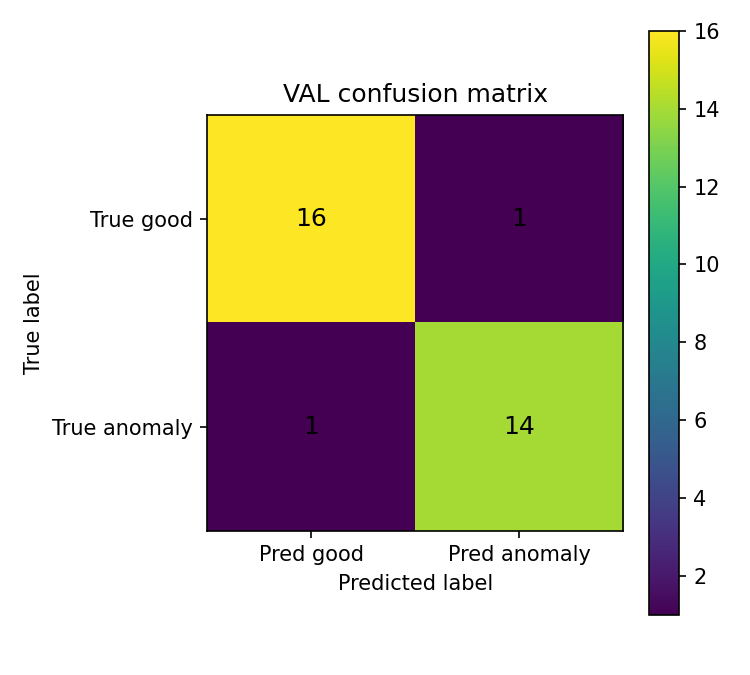

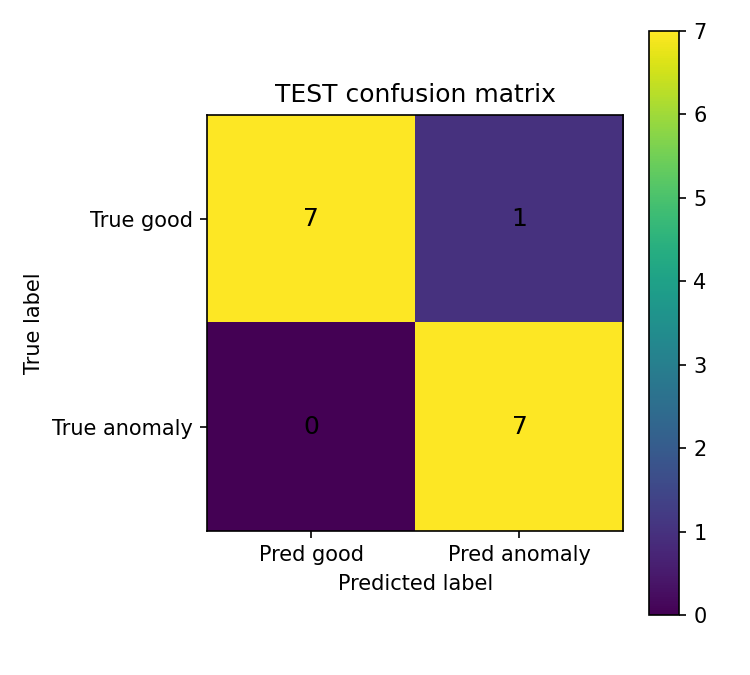

In [8]:

# =========================
# Zobrazenie confusion matrix obrázkov
# =========================
from IPython.display import display
for name in ['val_confusion_matrix.png', 'test_confusion_matrix.png']:
    p = Path(CFG['out_dir']) / name
    if p.exists():
        display(Image.open(p))


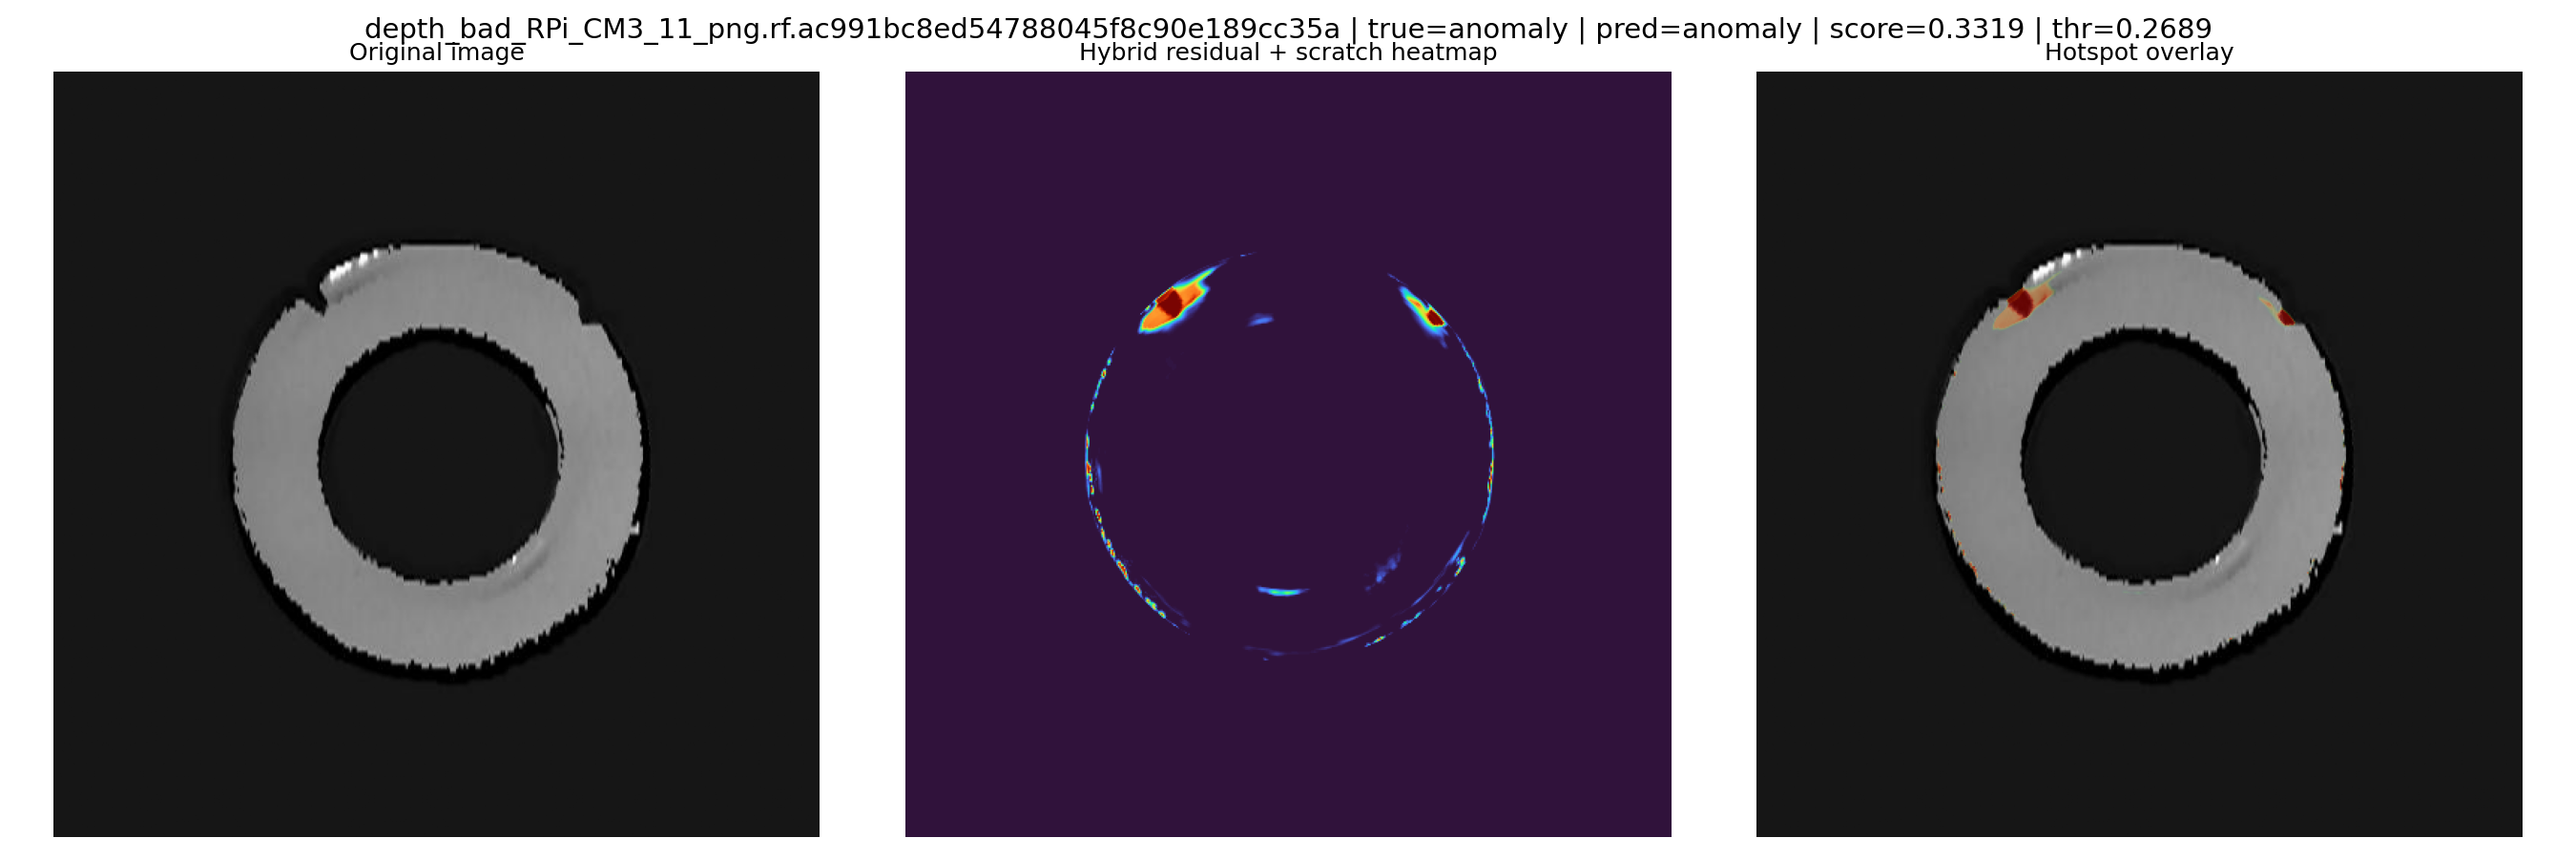

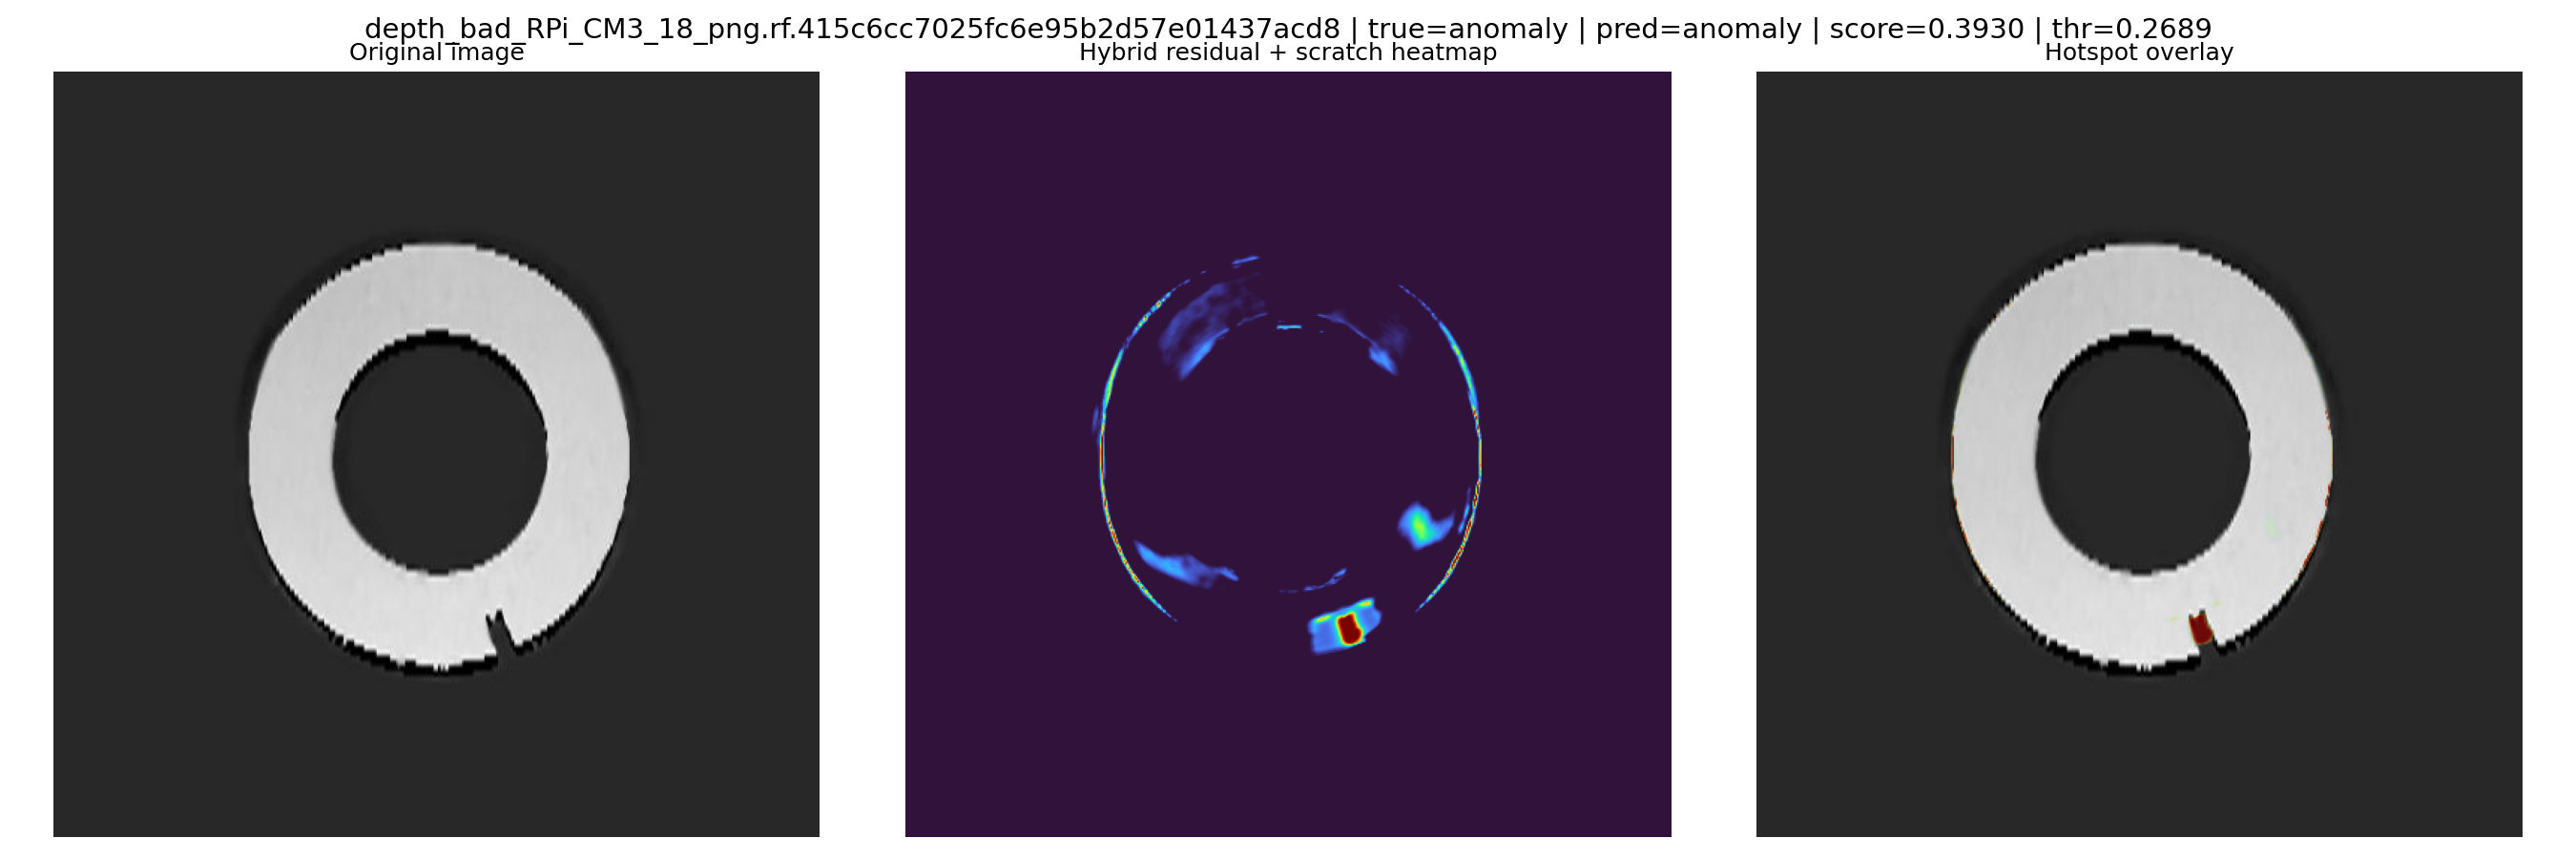

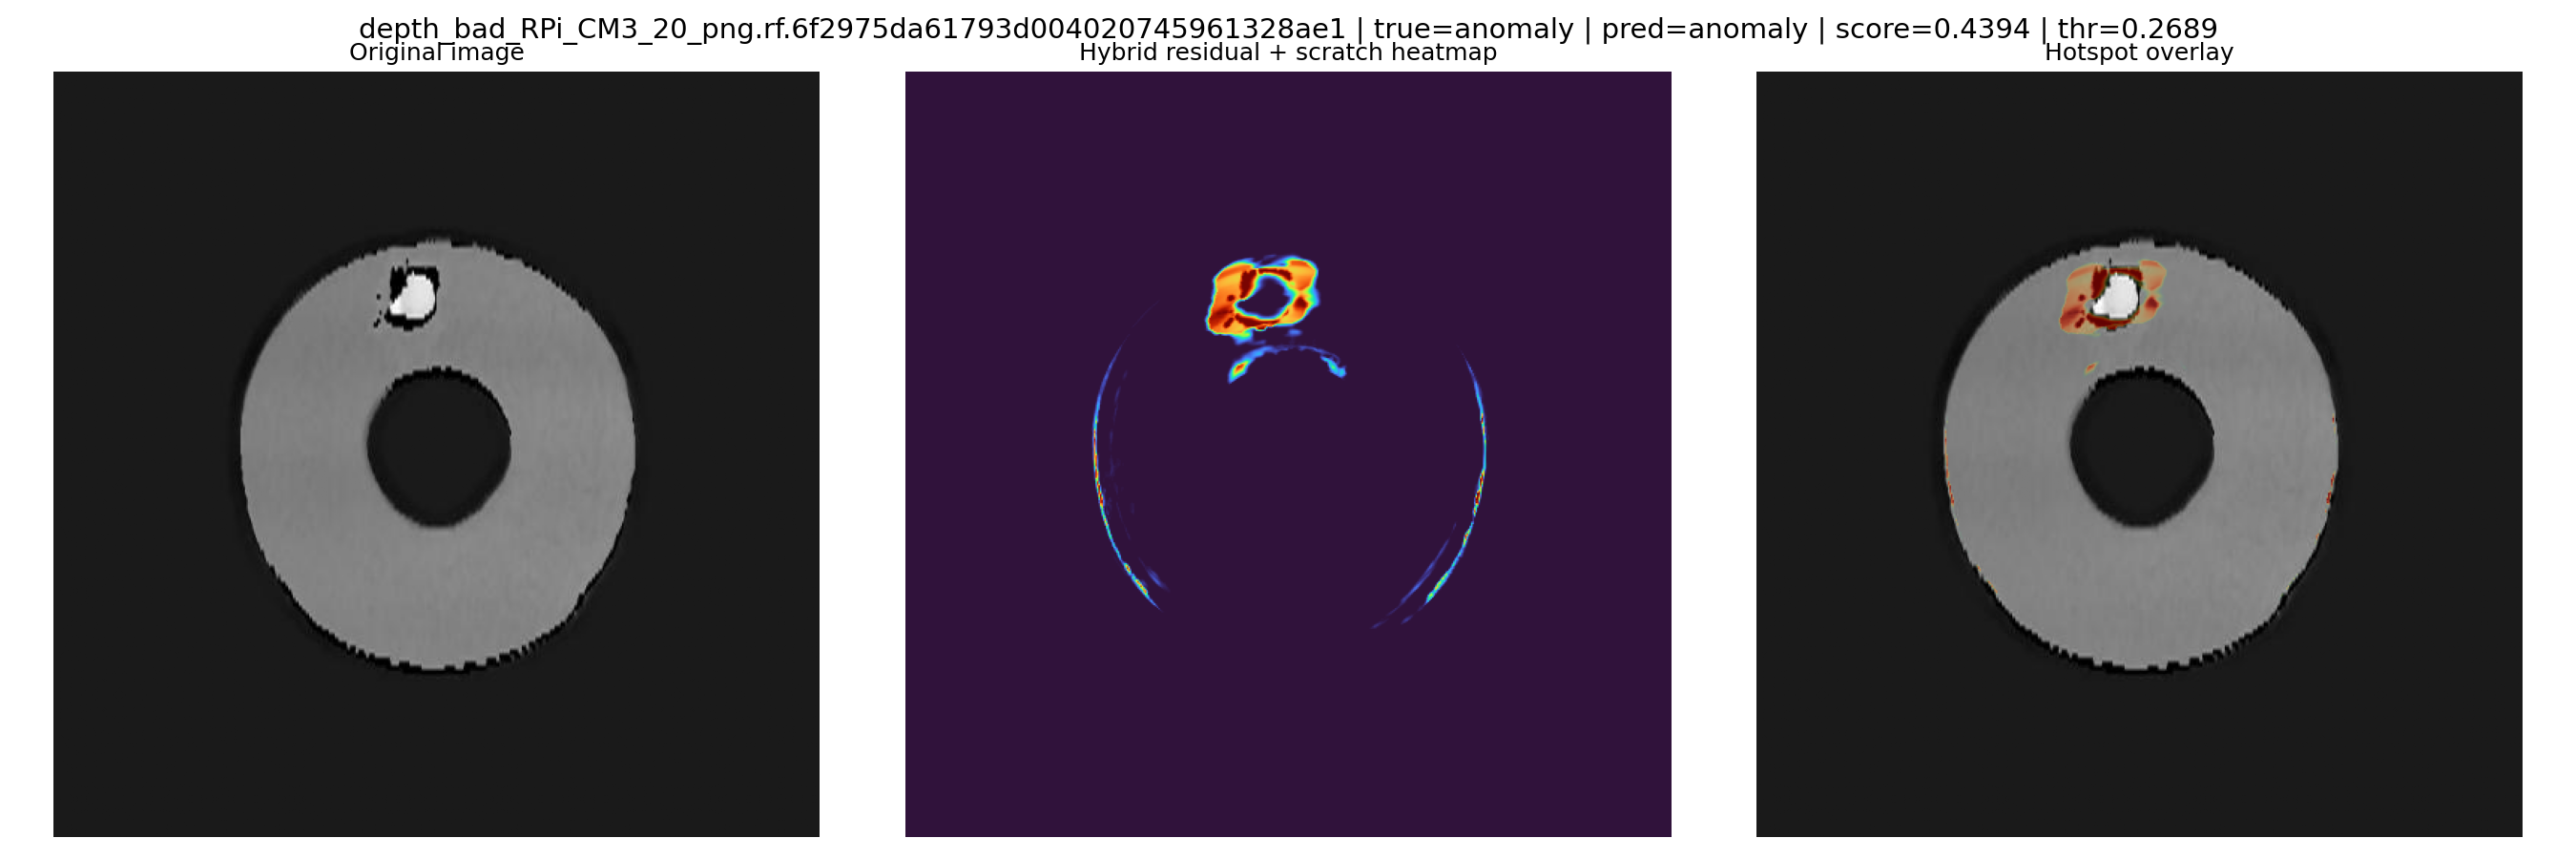

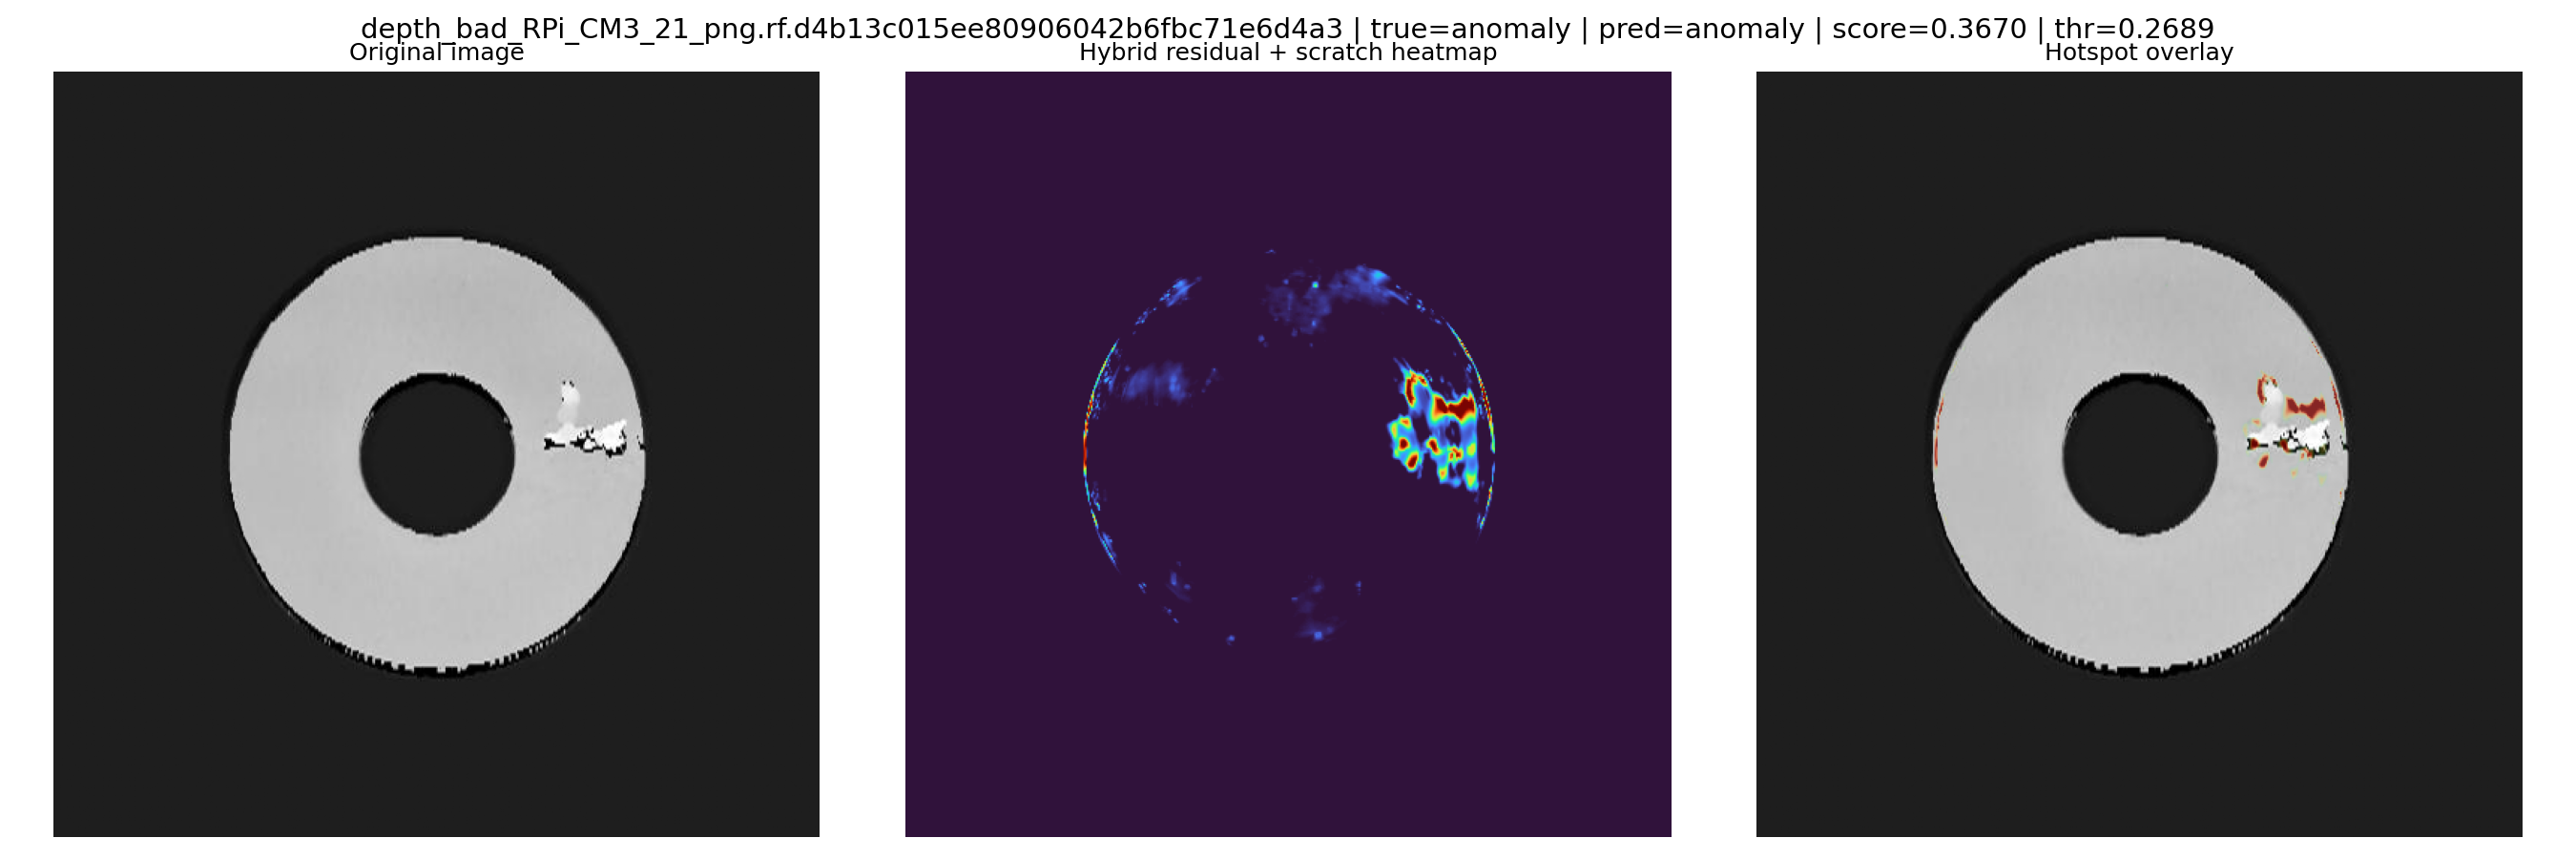

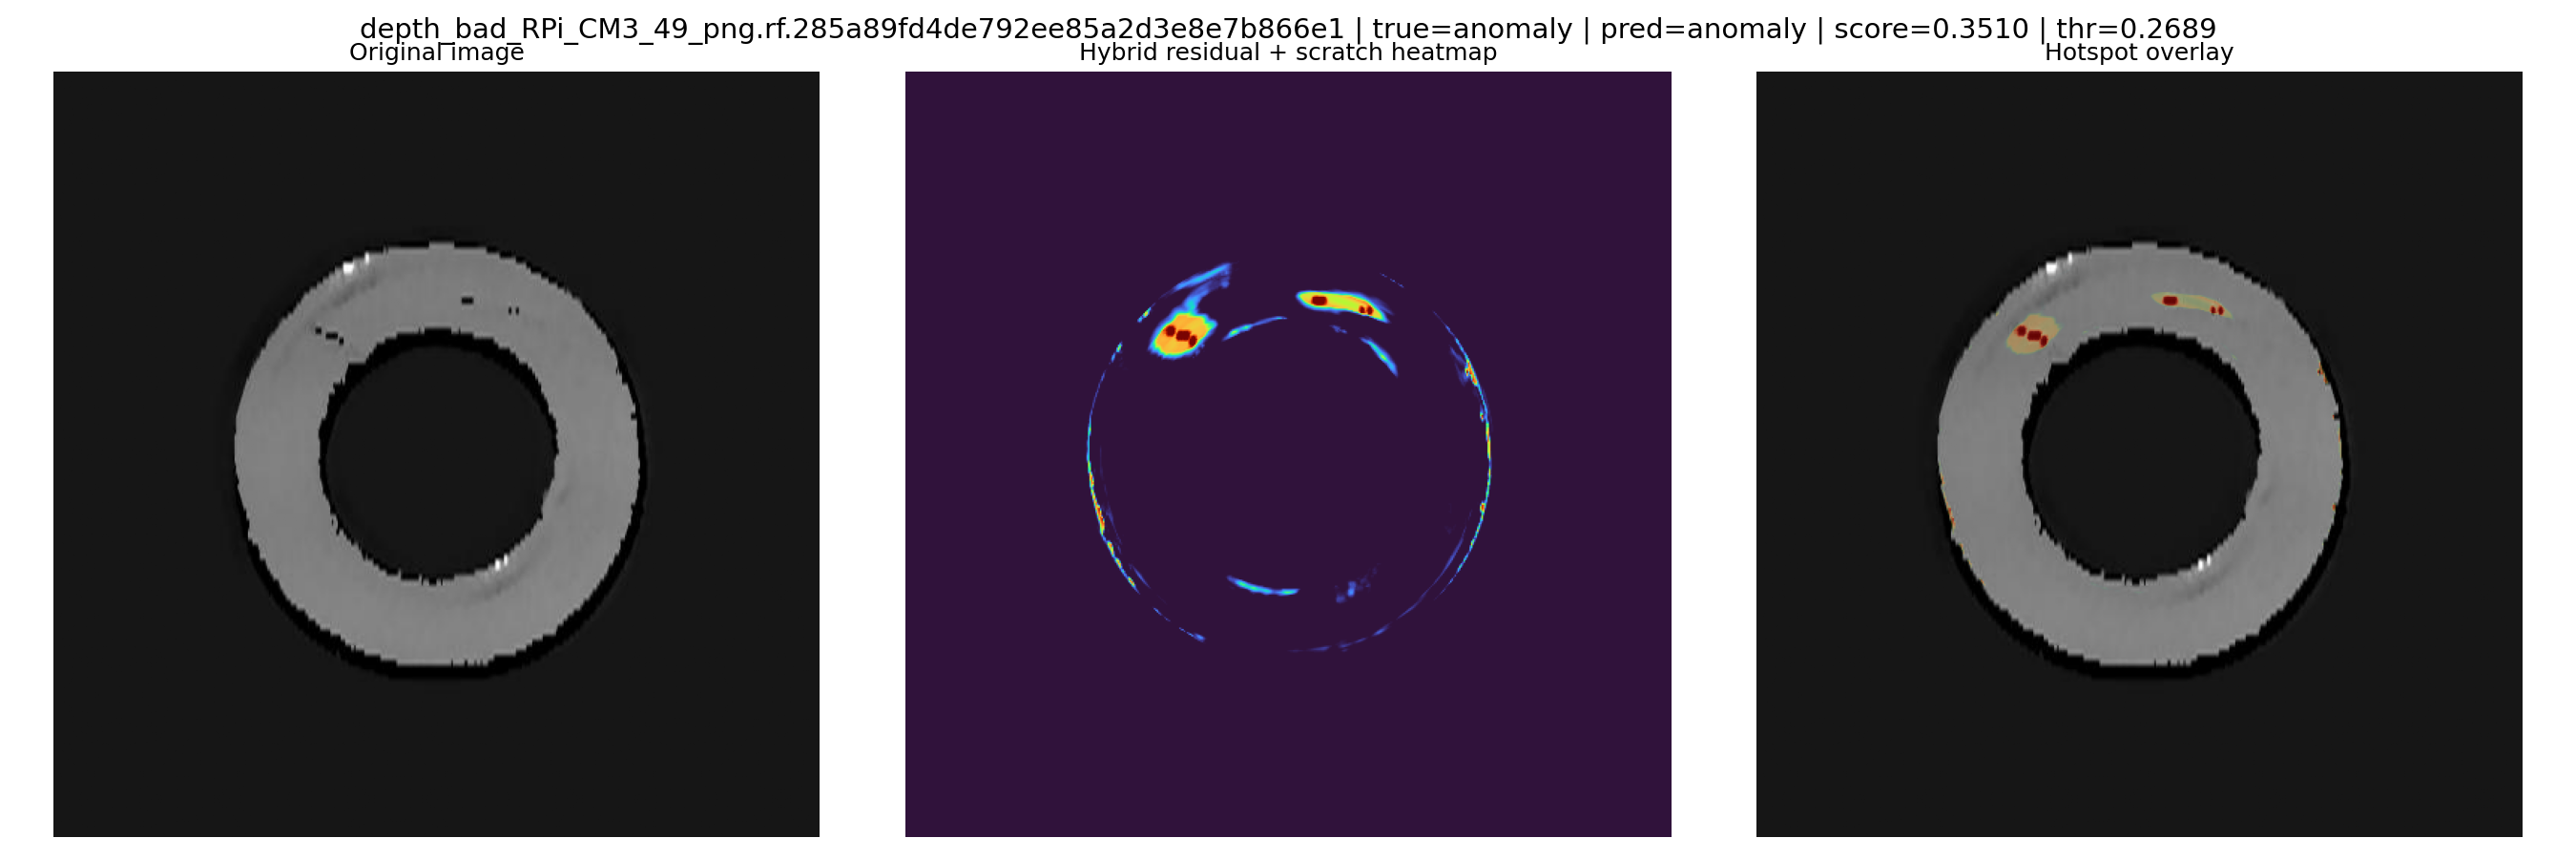

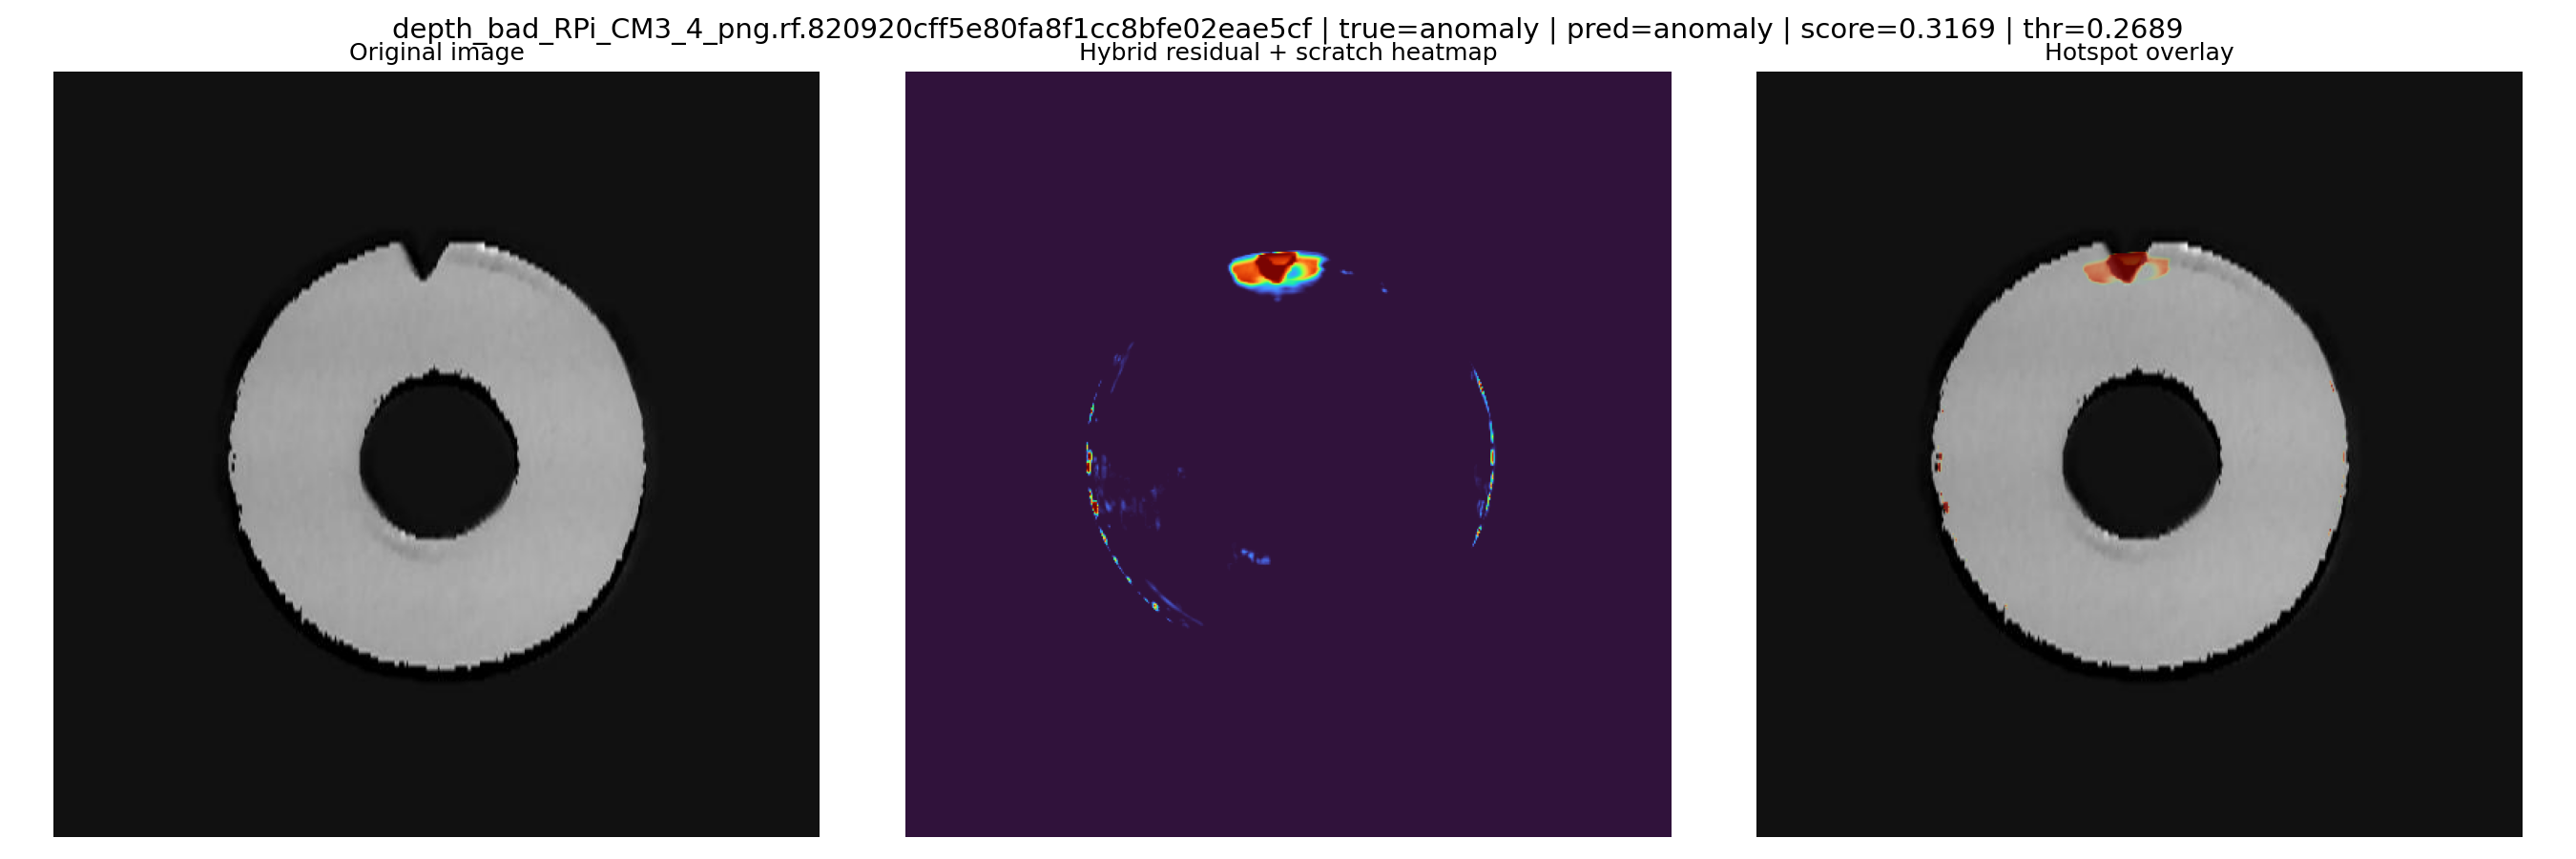

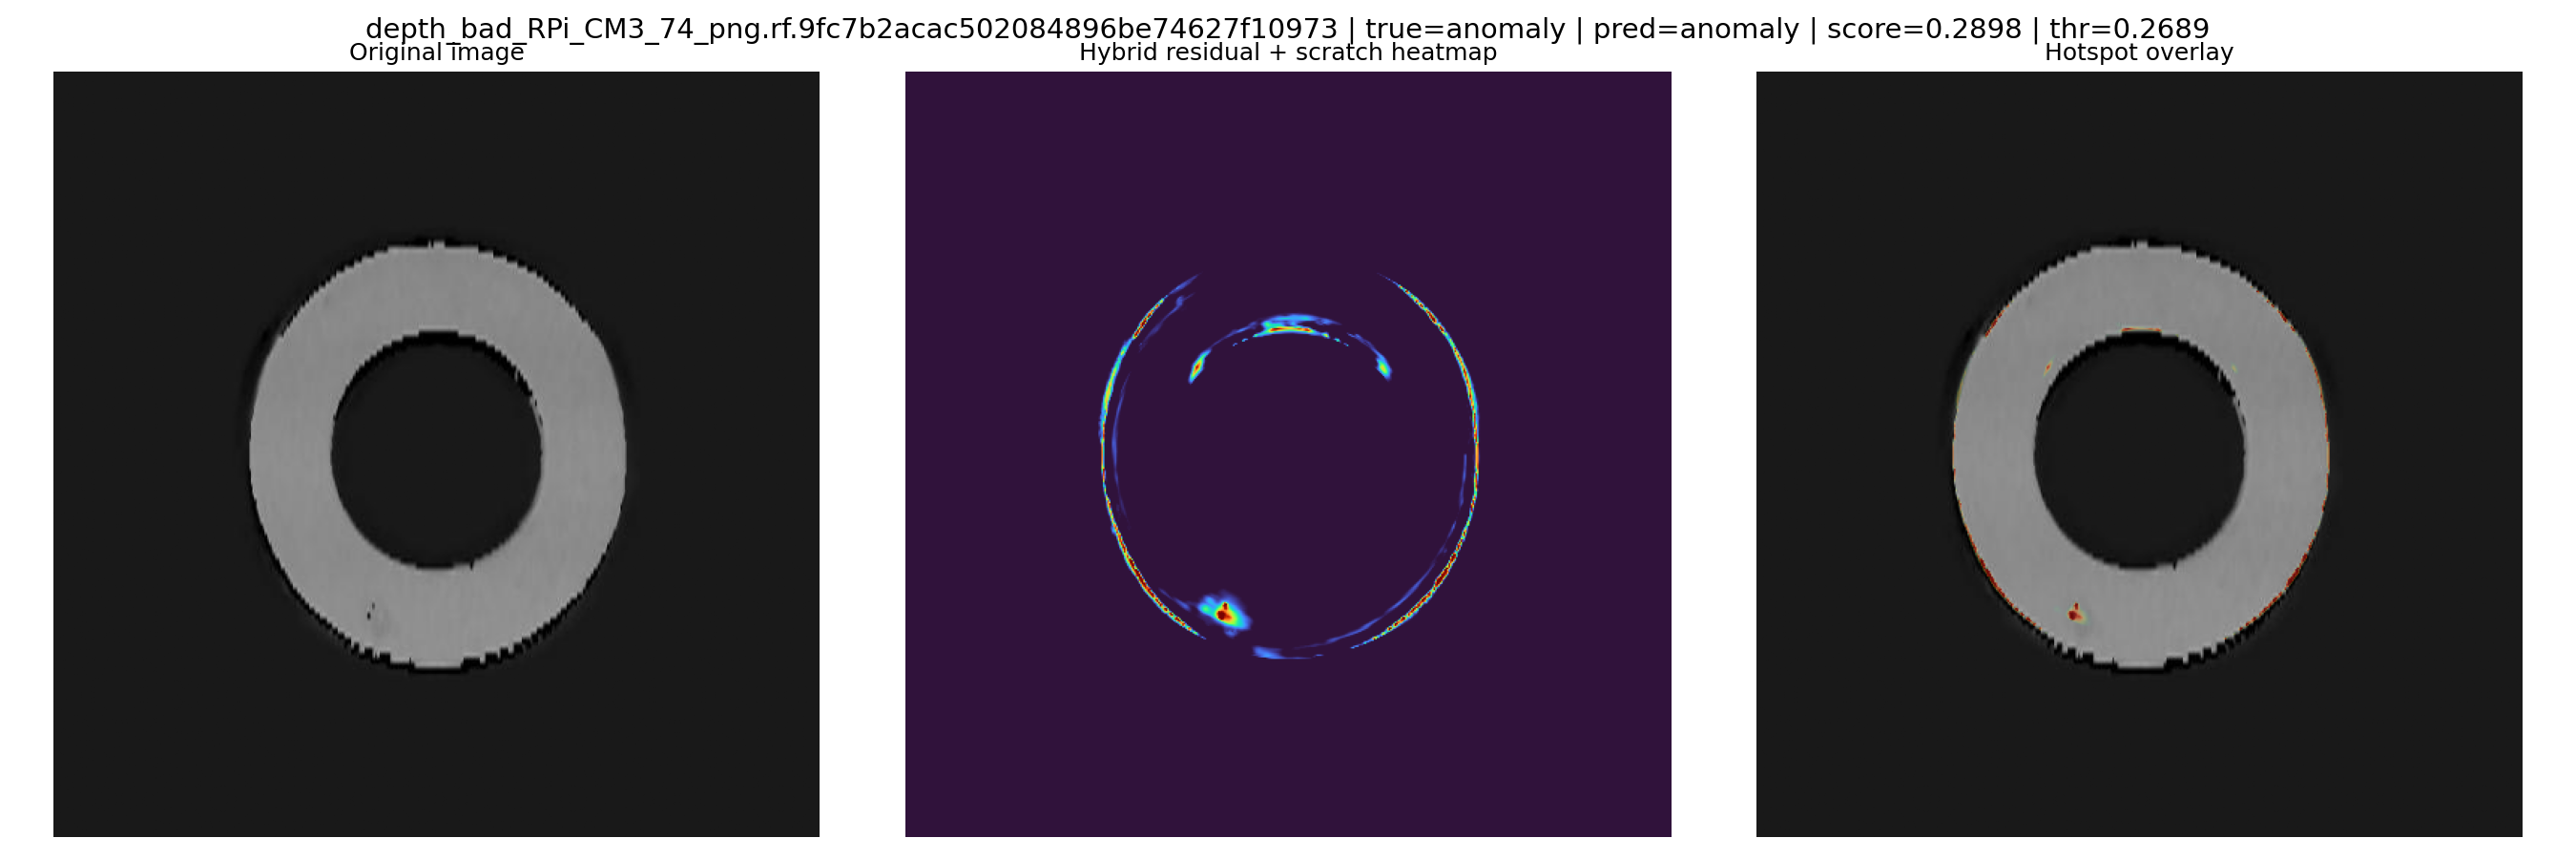

In [9]:

# =========================
# Ukážka pár heatmap panelov
# =========================
heat_root = Path(CFG['out_dir']) / 'heatmaps' / 'anomaly'
panels = sorted(heat_root.glob('*_panel.png'))[:10]
for p in panels:
    display(Image.open(p))


# Supervisor report exports



Using device: cuda
Report dir: runs\fcdd_tp26_depthmap_v1\supervisor_report
Classification score kwargs: {'edge_margin_frac': 0.02, 'topk_ratio': 0.015, 'center_trim_frac': 0.13, 'smooth_kernel': 5, 'edge_min_weight': 0.1}

=== THRESHOLDS ===
Balanced/specificity: {
  "threshold": 0.2689346969127655,
  "acc": 0.9375,
  "bal_acc": 0.9372549019607843,
  "recall": 0.9333333333333333,
  "specificity": 0.9411764705882353,
  "tn": 16,
  "fp": 1,
  "fn": 1,
  "tp": 14,
  "selected_by": "both_constraints_bal_acc",
  "min_anomaly_recall": 0.8,
  "min_specificity": 0.6,
  "mode": "specificity_guard"
}
Defect-sensitive: {
  "threshold": 0.2689346969127655,
  "acc": 0.9375,
  "bal_acc": 0.9372549019607843,
  "auc": 0.9215686274509803,
  "recall": 0.9333333333333333,
  "specificity": 0.9411764705882353,
  "tn": 16,
  "fp": 1,
  "fn": 1,
  "tp": 14,
  "selected_by": "target_recall_0.90_max_specificity",
  "target_recall": 0.9
}
TP: vybratých 7 / dostupných 7
TN: vybratých 7 / dostupných 7
FP: vybrat

## Supervisor report hotový
Výstupy: `runs\fcdd_tp26_depthmap_v1\supervisor_report`

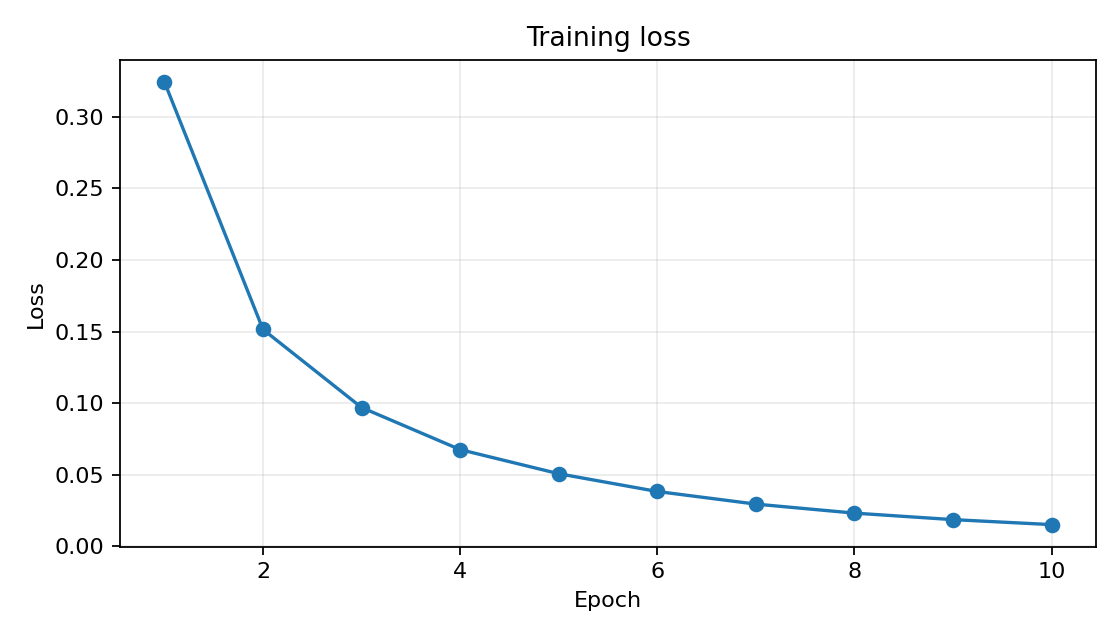

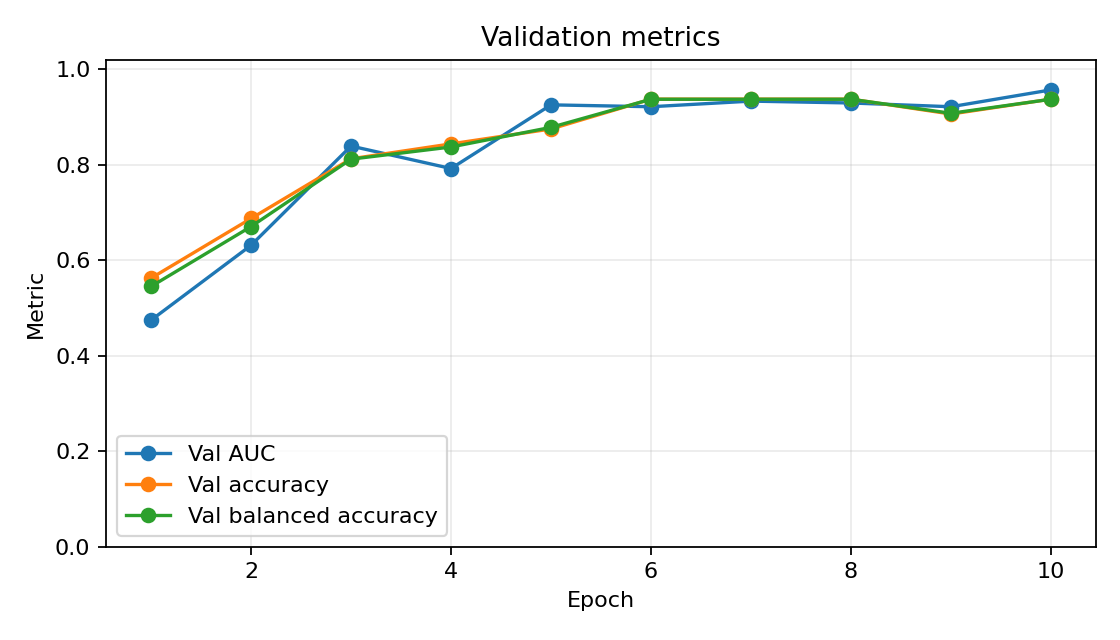

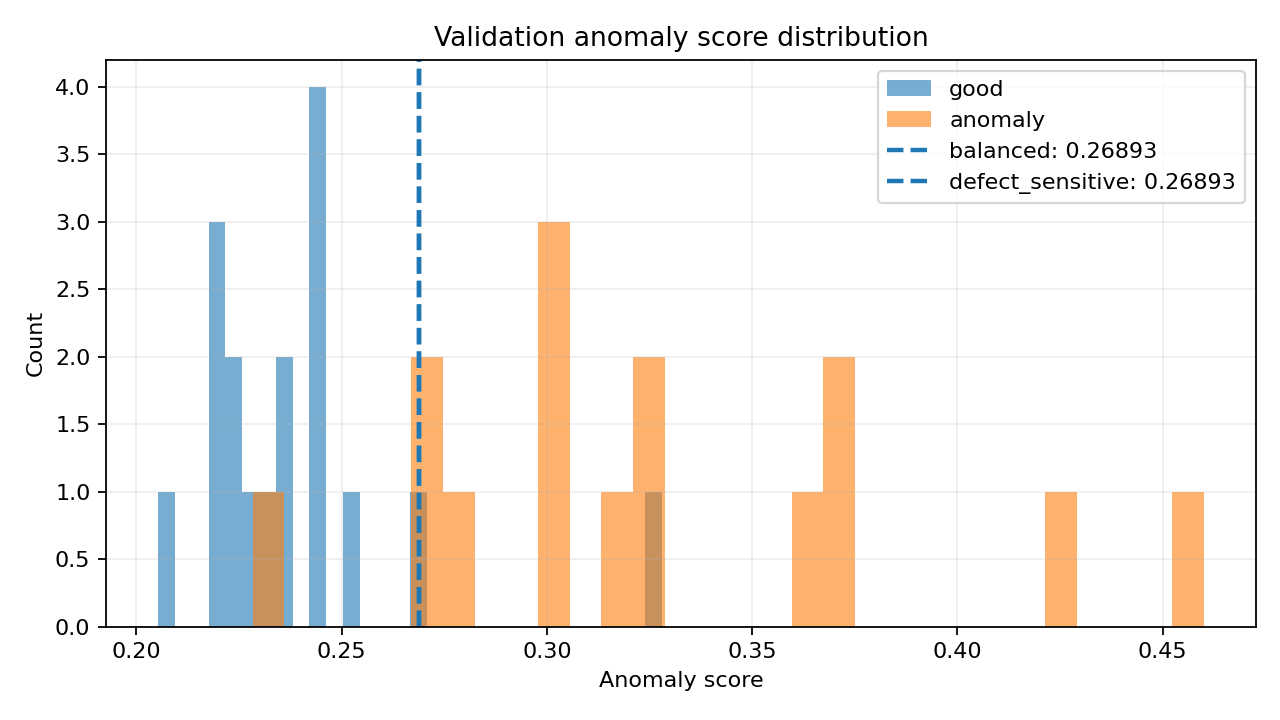

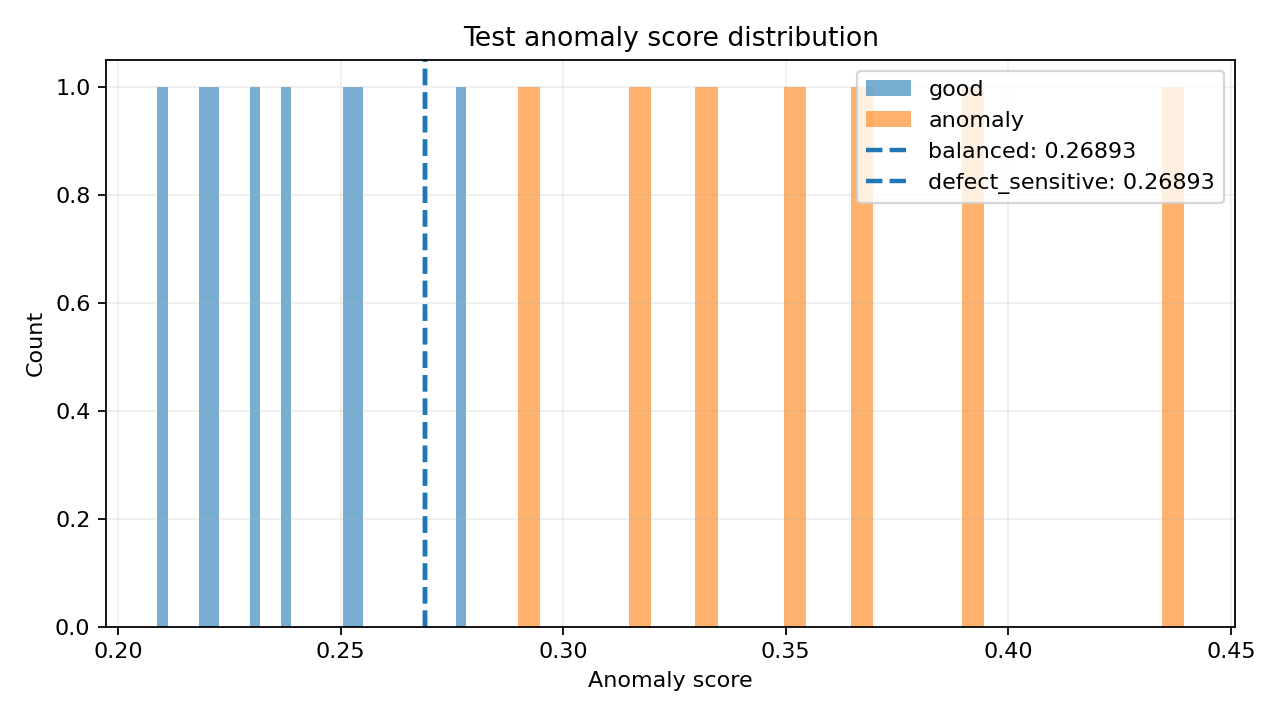

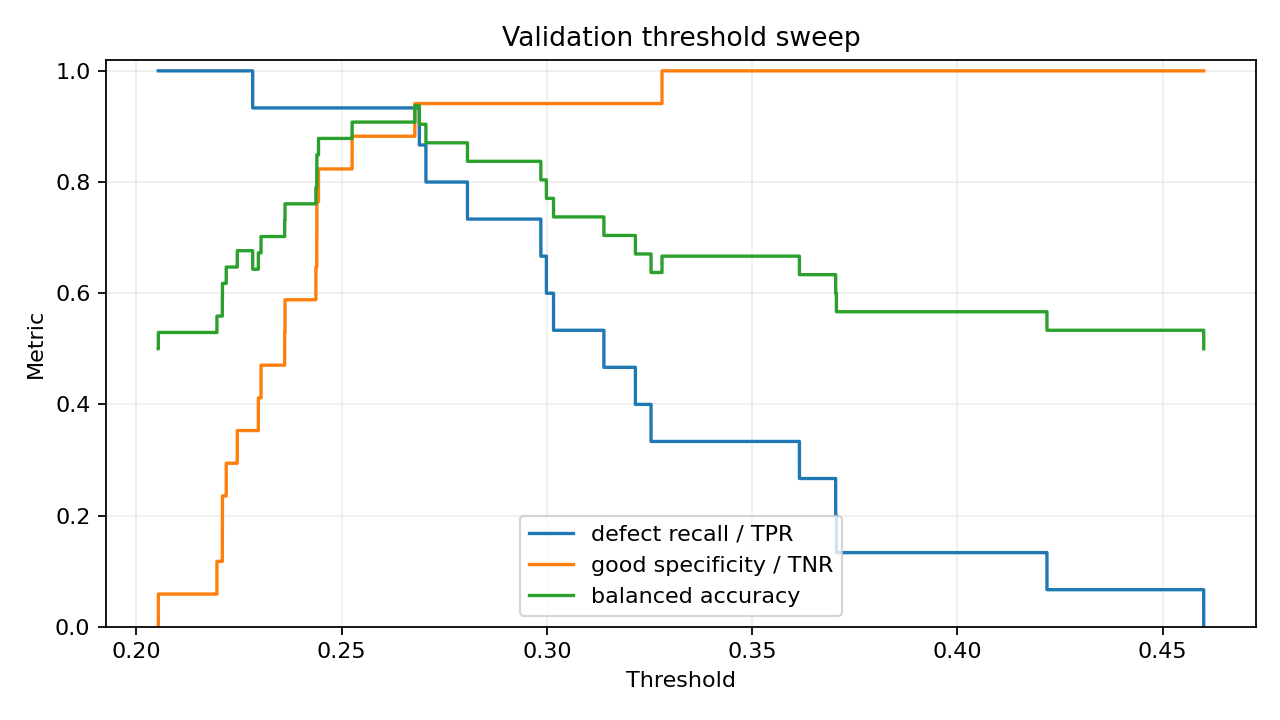

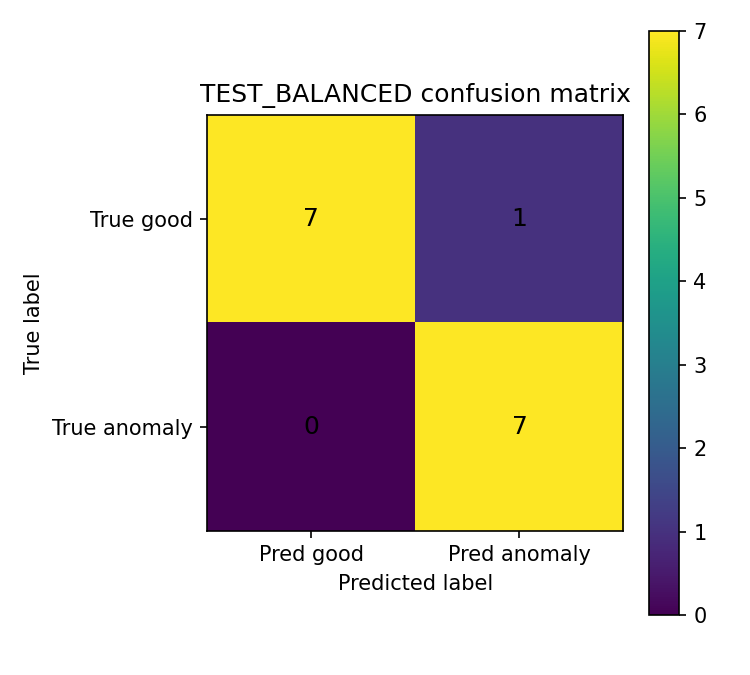

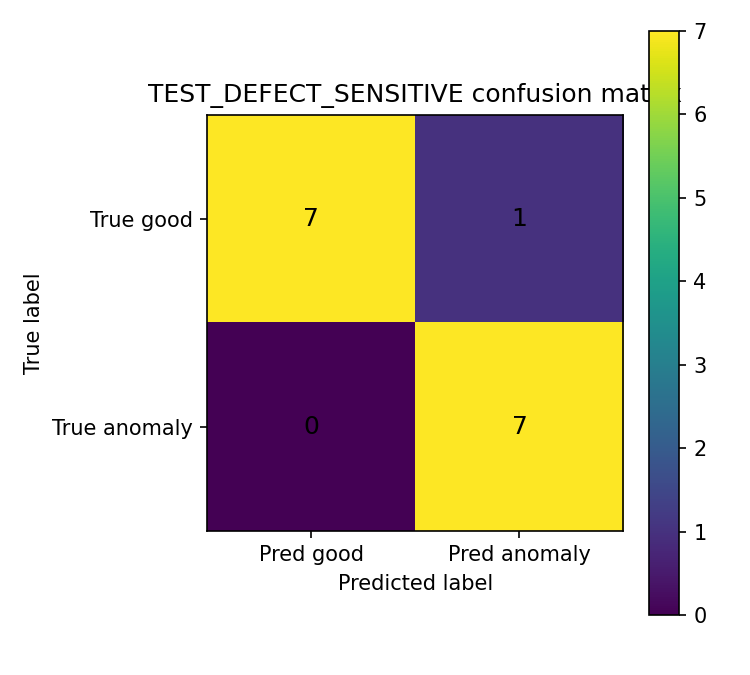

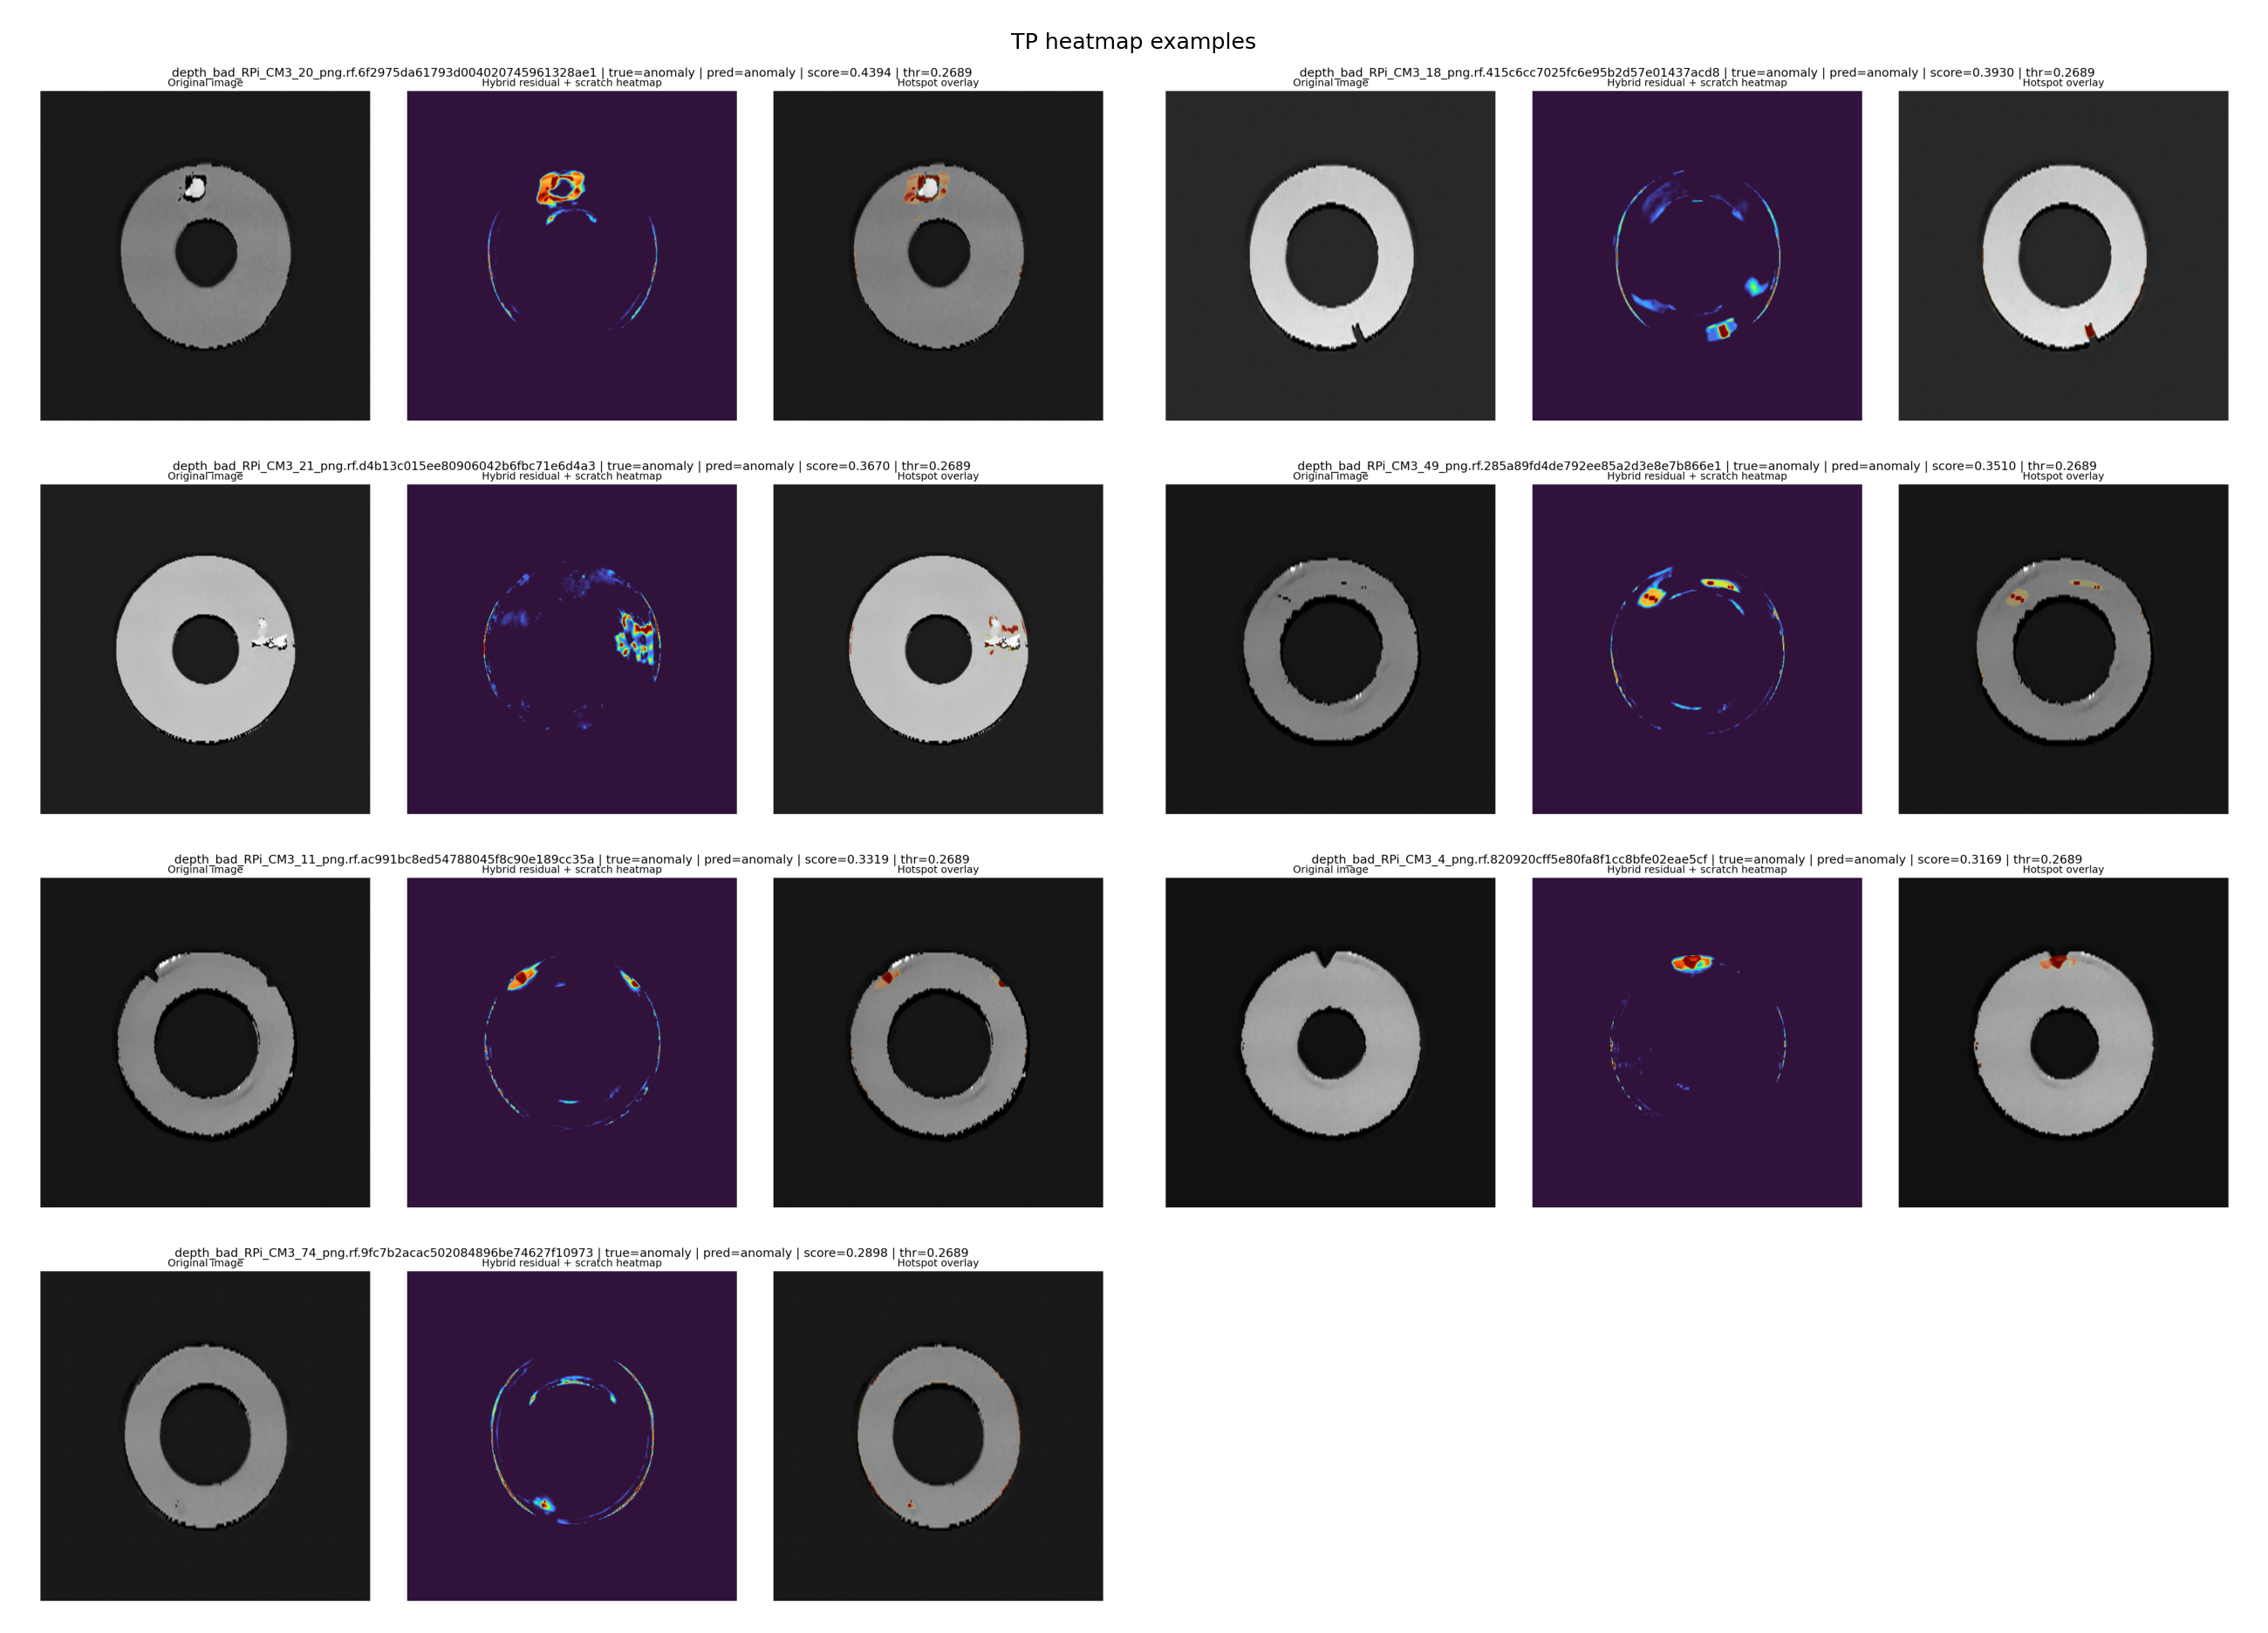

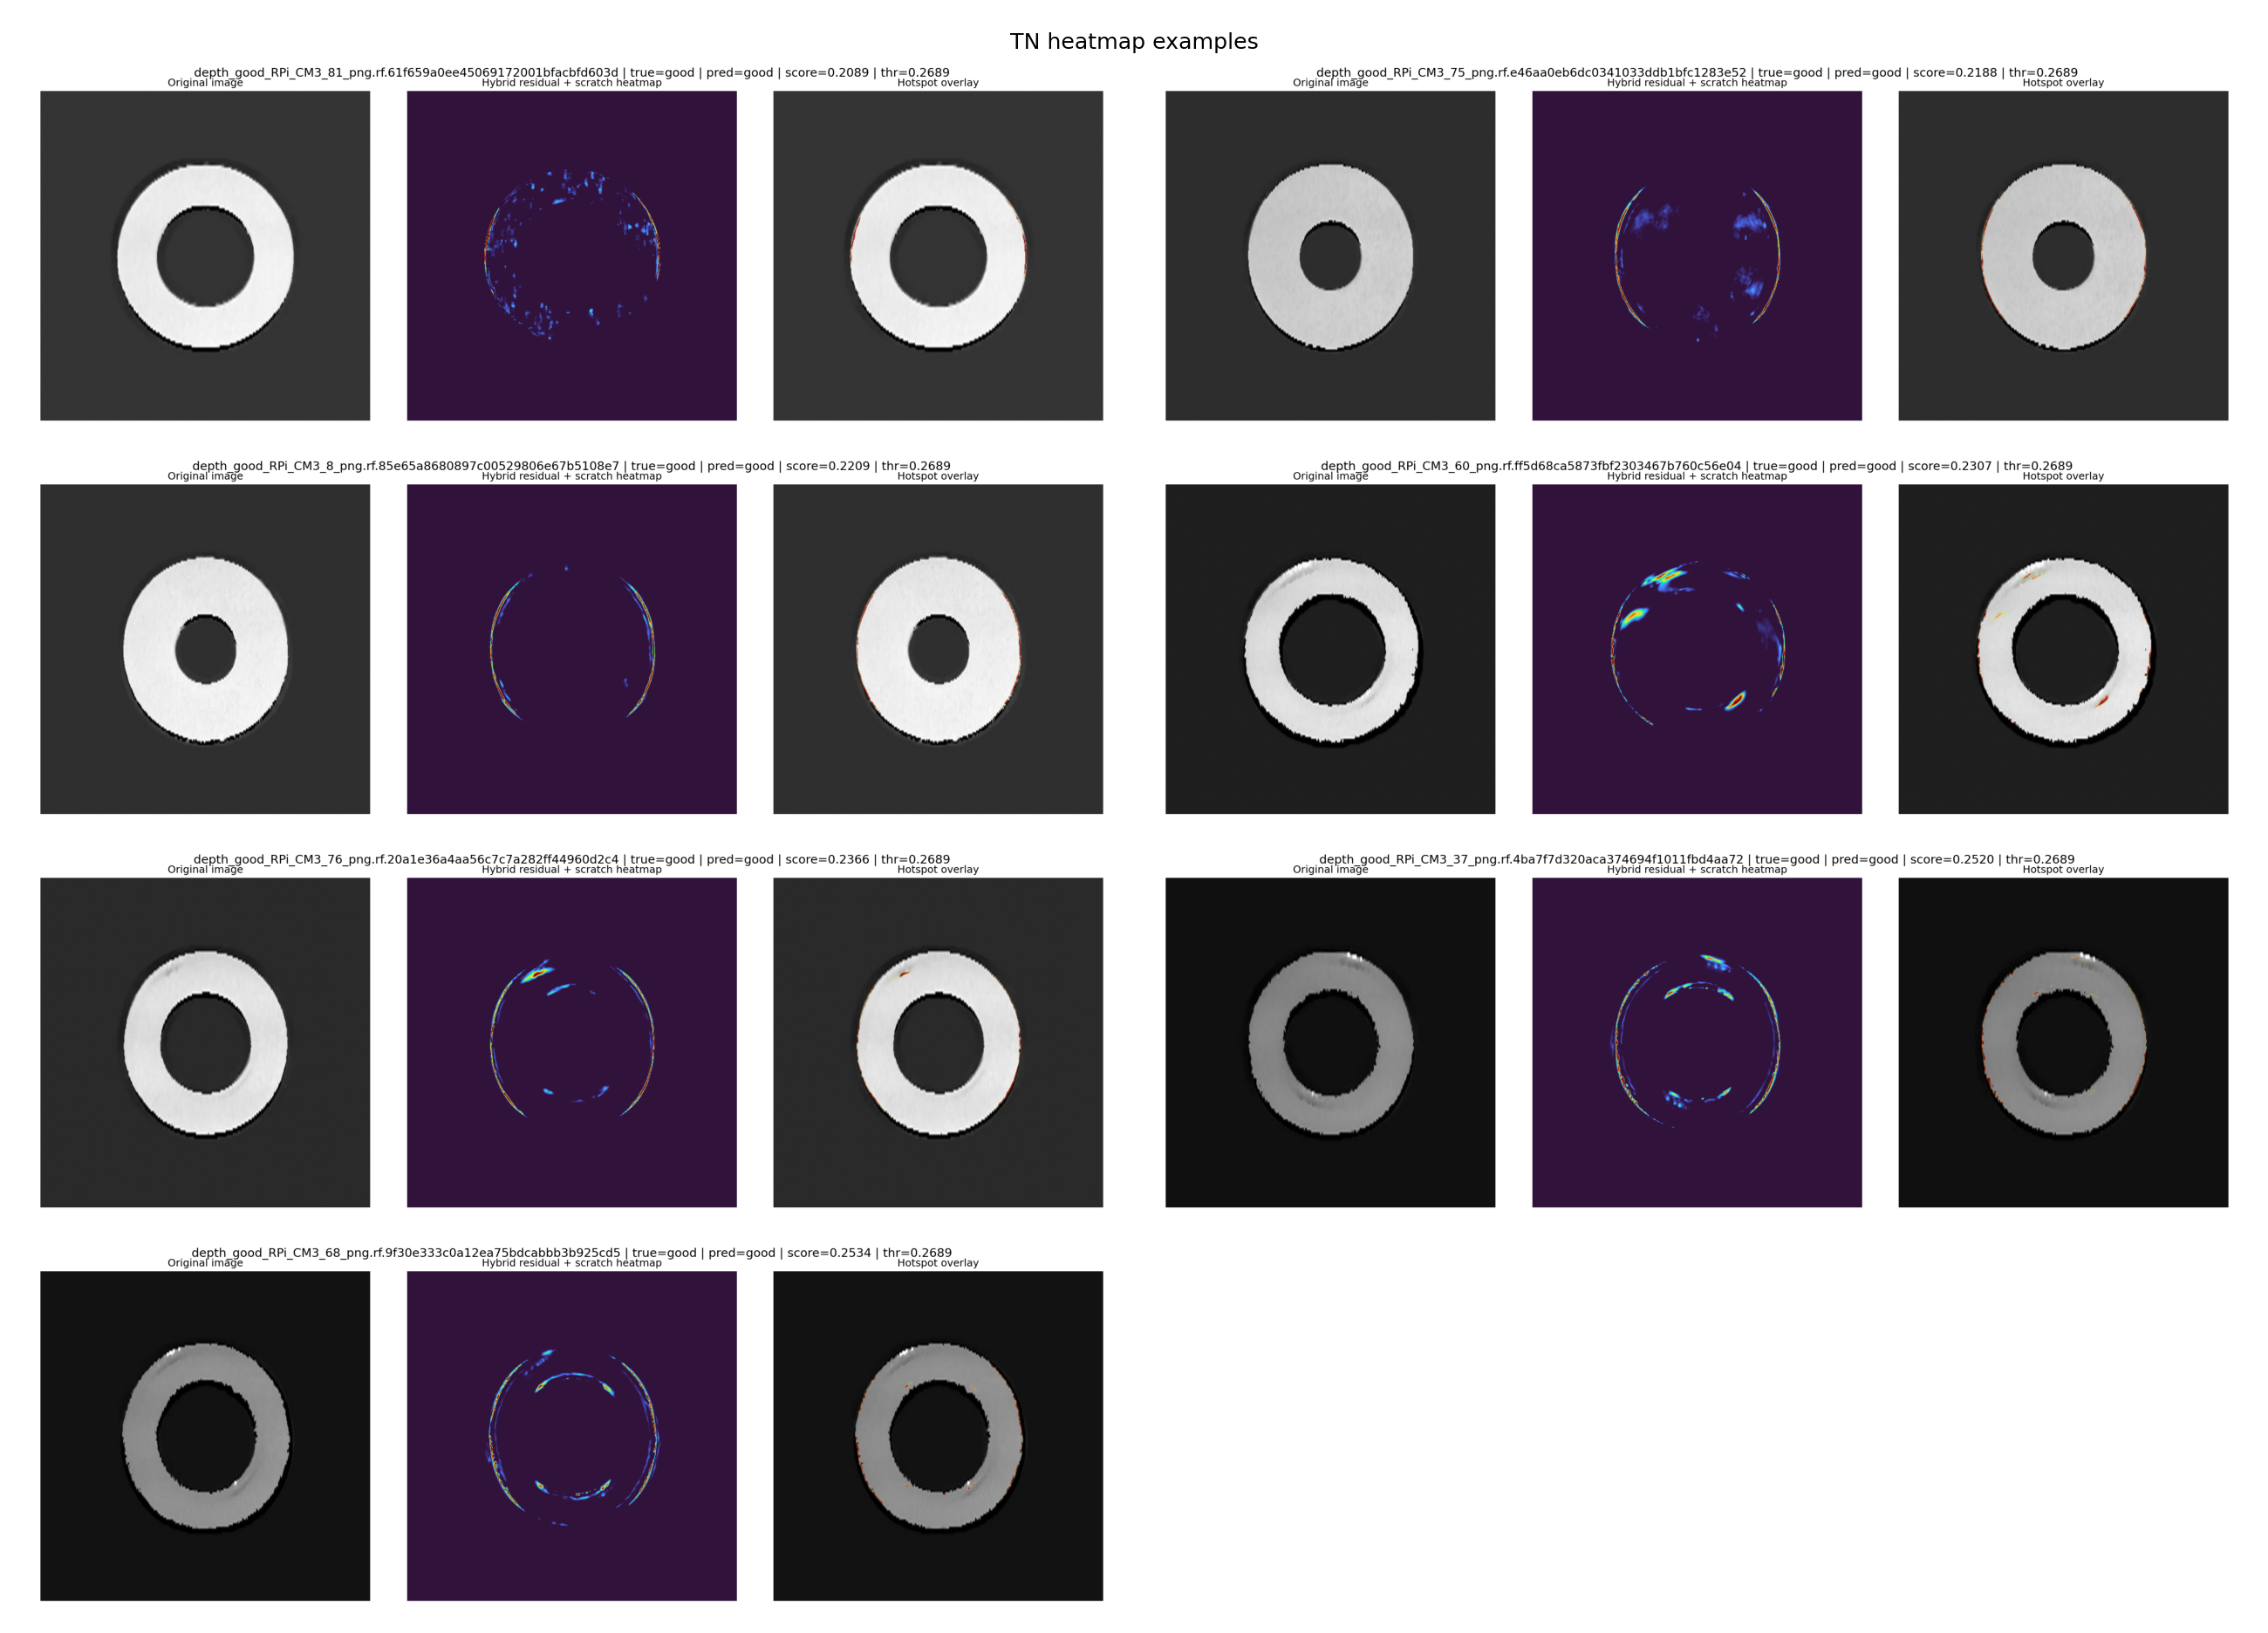

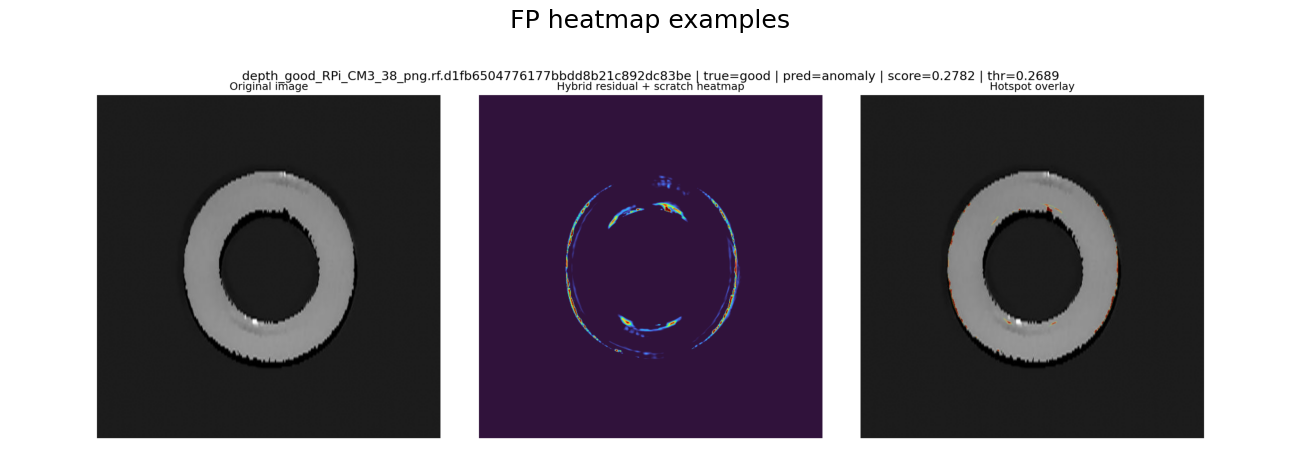

{'report_dir': 'runs\\fcdd_tp26_depthmap_v1\\supervisor_report',
 'balanced_threshold': 0.2689346969127655,
 'defect_sensitive_threshold': 0.2689346969127655,
 'metrics_summary': [{'threshold': 0.2689346969127655,
   'acc': 0.9375,
   'bal_acc': 0.9372549019607843,
   'auc': 0.9215686274509803,
   'recall': 0.9333333333333333,
   'specificity': 0.9411764705882353,
   'tn': 16,
   'fp': 1,
   'fn': 1,
   'tp': 14,
   'split': 'val',
   'mode': 'balanced'},
  {'threshold': 0.2689346969127655,
   'acc': 0.9375,
   'bal_acc': 0.9372549019607843,
   'auc': 0.9215686274509803,
   'recall': 0.9333333333333333,
   'specificity': 0.9411764705882353,
   'tn': 16,
   'fp': 1,
   'fn': 1,
   'tp': 14,
   'split': 'val',
   'mode': 'defect_sensitive'},
  {'threshold': 0.2689346969127655,
   'acc': 0.9333333333333333,
   'bal_acc': 0.9375,
   'auc': 1.0,
   'recall': 1.0,
   'specificity': 0.875,
   'tn': 7,
   'fp': 1,
   'fn': 0,
   'tp': 7,
   'split': 'test',
   'mode': 'balanced'},
  {'threshol

In [10]:
# =========================
# POST-HOC REPORT EXPORTS PRE SKOLITELA
# =========================
# Tento blok neretrénuje model. Použije existujúci checkpoint a vygeneruje:
# - balanced/specificity threshold výsledky,
# - defect-sensitive threshold výsledky,
# - histogram score distribúcie,
# - threshold sweep graf,
# - confusion matrices,
# - TP/TN/FP/FN heatmap príklady,
# - dokumentačný markdown so zhrnutím parametrov a výsledkov.

import csv
from collections import defaultdict
from torch.utils.data import Subset
from IPython.display import display, Markdown


def _safe_key(path_like):
    return str(path_like).replace('\\', '/').lower()


def heatmap_kwargs_from_args(args):
    """Zbalenie všetkých parametrov, ktoré ovplyvňujú iba vizualizáciu heatmáp.

    Tieto parametre nemenia image-level classification score. Slúžia len na to,
    aby overlay nebol príliš plošný a aby menej chytal odlesky/okraje.
    """
    return dict(
        use_hybrid_heatmap=getattr(args, 'use_hybrid_heatmap', True),
        heatmap_model_weight=getattr(args, 'heatmap_model_weight', 0.78),
        heatmap_scratch_weight=getattr(args, 'heatmap_scratch_weight', 0.22),
        heatmap_scratch_peak_boost=getattr(args, 'heatmap_scratch_peak_boost', 0.68),
        heatmap_sparse_q=getattr(args, 'heatmap_sparse_q', 0.75),
        heatmap_display_gamma=getattr(args, 'heatmap_display_gamma', 1.30),
        heatmap_min_component_area=getattr(args, 'heatmap_min_component_area', 3),
        heatmap_min_component_peak=getattr(args, 'heatmap_min_component_peak', 0.10),
        overlay_activation_floor=getattr(args, 'overlay_activation_floor', 0.22),
        overlay_gamma=getattr(args, 'overlay_gamma', 1.65),
        heatmap_edge_fade_frac=getattr(args, 'heatmap_edge_fade_frac', 0.075),
        heatmap_edge_min_weight=getattr(args, 'heatmap_edge_min_weight', 0.15),
        heatmap_suppress_circular_bg=getattr(args, 'heatmap_suppress_circular_bg', True),
        heatmap_circular_bg_strength=getattr(args, 'heatmap_circular_bg_strength', 0.48),
        heatmap_circular_bg_sigma_t=getattr(args, 'heatmap_circular_bg_sigma_t', 26.0),
        heatmap_circular_bg_q=getattr(args, 'heatmap_circular_bg_q', 0.55),
        scratch_detail_blur_r=getattr(args, 'scratch_detail_blur_r', 1.0),
        scratch_detail_blur_t=getattr(args, 'scratch_detail_blur_t', 16.0),
        scratch_detail_dark_weight=getattr(args, 'scratch_detail_dark_weight', 1.15),
        scratch_detail_bright_weight=getattr(args, 'scratch_detail_bright_weight', 0.18),
        scratch_detail_q_hi=getattr(args, 'scratch_detail_q_hi', 0.995),
        scratch_detail_gradient_weight=getattr(args, 'scratch_detail_gradient_weight', 0.22),
        scratch_detail_keep_q=getattr(args, 'scratch_detail_keep_q', 0.72),
        scratch_detail_gamma=getattr(args, 'scratch_detail_gamma', 1.25),
        scratch_specular_suppress=getattr(args, 'scratch_specular_suppress', True),
        scratch_specular_q=getattr(args, 'scratch_specular_q', 0.985),
        scratch_specular_strength=getattr(args, 'scratch_specular_strength', 0.85),
        scratch_preprocess_reflections=getattr(args, 'scratch_preprocess_reflections', False),
        illum_sigma_px=getattr(args, 'illum_sigma_px', 35.0),
        illum_blend=getattr(args, 'illum_blend', 0.50),
        glare_clip_q=getattr(args, 'glare_clip_q', 0.985),
        glare_blur_sigma_px=getattr(args, 'glare_blur_sigma_px', 5.0),
        glare_dilate_px=getattr(args, 'glare_dilate_px', 2),
        glare_min_v=getattr(args, 'glare_min_v', 0.72),
        glare_sat_max=getattr(args, 'glare_sat_max', 0.80),
        heatmap_glare_suppress=getattr(args, 'heatmap_glare_suppress', True),
        heatmap_glare_q=getattr(args, 'heatmap_glare_q', 0.965),
        heatmap_glare_min_v=getattr(args, 'heatmap_glare_min_v', 0.66),
        heatmap_glare_sat_max=getattr(args, 'heatmap_glare_sat_max', 0.82),
        heatmap_glare_strength=getattr(args, 'heatmap_glare_strength', 0.72),
        heatmap_glare_dilate_px=getattr(args, 'heatmap_glare_dilate_px', 2),
        heatmap_glare_blur_sigma=getattr(args, 'heatmap_glare_blur_sigma', 2.2),
        heatmap_glare_preserve_scratch_thr=getattr(args, 'heatmap_glare_preserve_scratch_thr', 0.38),
        heatmap_wrap_margin_frac=getattr(args, 'heatmap_wrap_margin_frac', 0.028),
    )


@torch.no_grad()
def collect_score_rows(model, loader, device, score_kwargs):
    """Získa image-level anomaly score pre každý obrázok v poradí datasetu."""
    model.eval()
    rows = []
    running_idx = 0

    for batch in loader:
        x, y, paths, meta_paths = batch
        x = x.to(device)
        hm = model(x)
        scores = masked_topk_score(hm, **score_kwargs).detach().cpu().numpy()

        for label, path, meta_path, score in zip(y, paths, meta_paths, scores):
            rows.append({
                'idx': int(running_idx),
                'file': str(path),
                'meta_path': str(meta_path),
                'true': int(label),
                'true_label': 'good' if int(label) == 0 else 'anomaly',
                'score': float(score),
            })
            running_idx += 1

    return rows


def metrics_from_rows(rows, threshold):
    y_true = np.asarray([r['true'] for r in rows], dtype=np.int64)
    y_score = np.asarray([r['score'] for r in rows], dtype=np.float32)
    y_pred = (y_score >= float(threshold)).astype(np.int64)
    c = confusion_counts(y_true, y_pred)
    acc = float((y_true == y_pred).mean()) if len(y_true) else 0.0
    bal = float(balanced_accuracy_from_counts(c))
    recall = float(c['tp'] / max(c['tp'] + c['fn'], 1))
    specificity = float(c['tn'] / max(c['tn'] + c['fp'], 1))
    auc = float(binary_auc(y_true.tolist(), y_score.tolist())) if len(y_true) else float('nan')
    out = {
        'threshold': float(threshold),
        'acc': acc,
        'bal_acc': bal,
        'auc': auc,
        'recall': recall,
        'specificity': specificity,
    }
    out.update(c)
    return out


def threshold_sweep_from_rows(rows):
    y_score = np.asarray([r['score'] for r in rows], dtype=np.float32)
    if y_score.size == 0:
        return []

    eps = max(float(np.std(y_score)) * 1e-4, 1e-6)
    candidates = np.unique(np.concatenate([y_score, y_score - eps, y_score + eps]))

    sweep = []
    for thr in candidates:
        m = metrics_from_rows(rows, float(thr))
        sweep.append(m)
    return sweep


def select_defect_sensitive_threshold(rows, target_recall=0.90):
    """Vyberie threshold na validácii tak, aby sa preferovalo zachytenie defektov.

    Logika:
    - hľadáme všetky thresholdy, kde recall defektov >= target_recall,
    - z nich vyberáme ten s najvyššou specificity, aby FP nenarástli zbytočne,
    - ak sa target recall nedá splniť, berieme threshold s najvyšším dosiahnuteľným recall.
    """
    sweep = threshold_sweep_from_rows(rows)
    if not sweep:
        return 0.0, {'selected_by': 'empty_scores'}

    eligible = [r for r in sweep if r['recall'] >= float(target_recall)]
    if eligible:
        chosen = max(
            eligible,
            key=lambda r: (r['specificity'], r['bal_acc'], r['acc'], r['threshold'])
        )
        selected_by = f'target_recall_{target_recall:.2f}_max_specificity'
    else:
        chosen = max(
            sweep,
            key=lambda r: (r['recall'], r['specificity'], r['bal_acc'], r['acc'])
        )
        selected_by = f'fallback_max_recall_target_{target_recall:.2f}_not_reached'

    chosen = dict(chosen)
    chosen['selected_by'] = selected_by
    chosen['target_recall'] = float(target_recall)
    return float(chosen['threshold']), chosen


def attach_predictions(rows, threshold):
    out = []
    for r in rows:
        rr = dict(r)
        pred = int(float(rr['score']) >= float(threshold))
        rr['pred'] = pred
        rr['pred_label'] = 'good' if pred == 0 else 'anomaly'
        if rr['true'] == 1 and pred == 1:
            rr['category'] = 'TP'
        elif rr['true'] == 0 and pred == 0:
            rr['category'] = 'TN'
        elif rr['true'] == 0 and pred == 1:
            rr['category'] = 'FP'
        else:
            rr['category'] = 'FN'
        out.append(rr)
    return out


def save_rows_csv(rows, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def save_metrics_csv(metric_rows, path):
    fieldnames = ['split', 'mode', 'threshold', 'acc', 'bal_acc', 'auc', 'recall', 'specificity', 'tn', 'fp', 'fn', 'tp']
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in metric_rows:
            writer.writerow({k: r.get(k, '') for k in fieldnames})


def plot_training_history(out_dir, report_dir):
    history_path = Path(out_dir) / 'history.json'
    if not history_path.exists():
        print('history.json sa nenašiel, training graf preskakujem:', history_path)
        return None, None

    with open(history_path, 'r', encoding='utf-8') as f:
        history = json.load(f)
    if not history:
        return None, None

    epochs = [h['epoch'] for h in history]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, [h['train_loss'] for h in history], marker='o')
    ax.set_title('Training loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    loss_path = Path(report_dir) / 'training_loss.png'
    fig.savefig(loss_path, dpi=160)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4))
    for key, label in [('val_auc', 'Val AUC'), ('val_acc', 'Val accuracy'), ('val_bal_acc', 'Val balanced accuracy')]:
        if key in history[0]:
            ax.plot(epochs, [h[key] for h in history], marker='o', label=label)
    ax.set_title('Validation metrics')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Metric')
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    metrics_path = Path(report_dir) / 'validation_metrics.png'
    fig.savefig(metrics_path, dpi=160)
    plt.close(fig)

    return loss_path, metrics_path


def plot_score_histogram(rows, thresholds, path, title):
    good_scores = [r['score'] for r in rows if r['true'] == 0]
    anom_scores = [r['score'] for r in rows if r['true'] == 1]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(good_scores, bins=30, alpha=0.60, label='good')
    ax.hist(anom_scores, bins=30, alpha=0.60, label='anomaly')
    for label, thr in thresholds.items():
        ax.axvline(float(thr), linestyle='--', linewidth=2, label=f'{label}: {float(thr):.5f}')
    ax.set_title(title)
    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.20)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_sweep(sweep, path, title):
    if not sweep:
        return
    xs = [r['threshold'] for r in sweep]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(xs, [r['recall'] for r in sweep], label='defect recall / TPR')
    ax.plot(xs, [r['specificity'] for r in sweep], label='good specificity / TNR')
    ax.plot(xs, [r['bal_acc'] for r in sweep], label='balanced accuracy')
    ax.set_title(title)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Metric')
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.20)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def make_subset_loader(base_loader, selected_indices, cfg):
    subset = Subset(base_loader.dataset, selected_indices)
    loader_kwargs = dict(batch_size=cfg['batch_size'], num_workers=cfg['num_workers'])
    if cfg['num_workers'] > 0:
        loader_kwargs['pin_memory'] = bool(cfg['pin_memory'])
        loader_kwargs['persistent_workers'] = bool(cfg['persistent_workers'])
    return DataLoader(subset, shuffle=False, **loader_kwargs)


def pick_confusion_examples(rows_with_pred, per_category=8):
    """Vyberie reprezentatívne príklady pre TP/TN/FP/FN.

    TP: najvyššie score; TN: najnižšie score; FP/FN: najbližšie k thresholdu, aby bolo vidieť hraničné chyby.
    """
    by_cat = defaultdict(list)
    for r in rows_with_pred:
        by_cat[r['category']].append(r)

    selected = []
    for cat in ['TP', 'TN', 'FP', 'FN']:
        items = list(by_cat.get(cat, []))
        if cat == 'TP':
            items.sort(key=lambda r: -r['score'])
        elif cat == 'TN':
            items.sort(key=lambda r: r['score'])
        else:
            items.sort(key=lambda r: abs(r['score'] - r.get('threshold_for_sort', 0.0)))
        chosen = items[:int(per_category)]
        print(f'{cat}: vybratých {len(chosen)} / dostupných {len(items)}')
        selected.extend(chosen)
    return selected


def copy_and_grid_confusion_heatmaps(raw_heatmap_dir, selected_rows, categorized_dir, per_category=8):
    raw_heatmap_dir = Path(raw_heatmap_dir)
    categorized_dir = Path(categorized_dir)
    categorized_dir.mkdir(parents=True, exist_ok=True)

    index_path = raw_heatmap_dir / 'heatmaps_index.json'
    if not index_path.exists():
        print('Chýba heatmaps_index.json:', index_path)
        return []

    with open(index_path, 'r', encoding='utf-8') as f:
        index_rows = json.load(f)

    selected_by_file = {_safe_key(r['file']): r for r in selected_rows}
    copied = []

    for item in index_rows:
        key = _safe_key(item['file'])
        src_info = selected_by_file.get(key)
        if src_info is None:
            continue
        cat = src_info['category']
        cat_dir = categorized_dir / cat
        cat_dir.mkdir(parents=True, exist_ok=True)
        src_panel = Path(item['panel'])
        dst_panel = cat_dir / src_panel.name
        if src_panel.exists():
            shutil.copy2(src_panel, dst_panel)
            copied.append({'category': cat, 'panel': str(dst_panel), **src_info})

    # vytvor jeden grid obrázok pre každú kategóriu
    for cat in ['TP', 'TN', 'FP', 'FN']:
        panels = [Path(r['panel']) for r in copied if r['category'] == cat]
        panels = panels[:int(per_category)]
        if not panels:
            continue

        n = len(panels)
        ncols = 1 if n <= 3 else 2
        nrows = int(math.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 3.6 * nrows))
        axes = np.asarray(axes).reshape(-1)
        for ax, panel_path in zip(axes, panels):
            img = Image.open(panel_path).convert('RGB')
            ax.imshow(img)
            ax.axis('off')
        for ax in axes[len(panels):]:
            ax.axis('off')
        fig.suptitle(f'{cat} heatmap examples', fontsize=14)
        fig.tight_layout()
        grid_path = categorized_dir / f'{cat}_grid.png'
        fig.savefig(grid_path, dpi=130)
        plt.close(fig)

    save_rows_csv(copied, categorized_dir / 'selected_heatmap_examples.csv')
    return copied


def write_documentation_note(report_dir, cfg, metric_rows, balanced_threshold, defect_threshold, defect_target_recall):
    report_dir = Path(report_dir)
    lines = []
    lines.append('# FCDD polar unwrap – výsledky a dokumentačné poznámky')
    lines.append('')
    lines.append('## Stručný popis riešenia')
    lines.append('Model používa FCDD prístup pre detekciu anomálií. Vstupný kruhový prstenec sa najprv prevedie do polar unwrap reprezentácie, kde horizontálna os reprezentuje uhol a vertikálna os radiálnu šírku prstenca. Sieť následne generuje anomálovú mapu. Z tejto mapy sa image-level skóre počíta ako priemer najvyšších hodnôt v maskovanej oblasti.')
    lines.append('')
    lines.append('## Threshold')
    lines.append(f'- Balanced/specificity threshold: `{balanced_threshold:.6f}`')
    lines.append(f'- Defect-sensitive threshold: `{defect_threshold:.6f}`')
    lines.append(f'- Defect-sensitive režim bol vybraný na validácii s cieľom dosiahnuť recall defektov približne `{defect_target_recall:.2f}` alebo vyšší, aj za cenu vyššieho počtu false positives.')
    lines.append('')
    lines.append('V praktickej kontrole kvality je vhodnejšie zachytiť viac potenciálne defektných kusov a poslať ich na manuálnu kontrolu, než pustiť defektný kus ako dobrý.')
    lines.append('')
    lines.append('## Hlavné parametre')
    for key in [
        'radial_bins', 'angular_bins', 'unwrap_margin_frac', 'base_channels', 'batch_size',
        'epochs', 'lr', 'weight_decay', 'topk_ratio', 'score_center_trim_frac',
        'score_edge_min_weight', 'score_smooth_kernel', 'suppress_reflections',
        'illum_sigma_px', 'illum_blend', 'hp_sigma_r', 'hp_sigma_t', 'hp_blend'
    ]:
        if key in cfg:
            lines.append(f'- `{key}`: `{cfg[key]}`')
    lines.append('')
    lines.append('## Výsledky')
    lines.append('| split | mode | threshold | acc | bal_acc | auc | recall | specificity | TN | FP | FN | TP |')
    lines.append('|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|')
    for r in metric_rows:
        lines.append(
            f"| {r['split']} | {r['mode']} | {r['threshold']:.6f} | {r['acc']:.4f} | "
            f"{r['bal_acc']:.4f} | {r['auc']:.4f} | {r['recall']:.4f} | {r['specificity']:.4f} | "
            f"{r['tn']} | {r['fp']} | {r['fn']} | {r['tp']} |"
        )
    lines.append('')
    lines.append('## Vygenerované obrázky')
    lines.append('- `training_loss.png` – priebeh tréningovej chyby')
    lines.append('- `validation_metrics.png` – validačné metriky počas trénovania')
    lines.append('- `val_score_histogram.png`, `test_score_histogram.png` – rozdelenie skóre pre good/anomaly')
    lines.append('- `val_threshold_sweep.png` – vplyv thresholdu na recall/specificity/balanced accuracy')
    lines.append('- `*_confusion_matrix.png` – confusion matrices pre oba režimy')
    lines.append('- `heatmap_examples_categories/TP|TN|FP|FN` – príklady heatmáp podľa typu rozhodnutia')

    note_path = report_dir / 'documentation_notes.md'
    with open(note_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    return note_path


def generate_supervisor_report(cfg, defect_target_recall=0.90, examples_per_category=8):
    args = SimpleNamespace(**cfg)
    seed_everything(args.seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    out_dir = Path(args.out_dir)
    report_dir = out_dir / 'supervisor_report'
    report_dir.mkdir(parents=True, exist_ok=True)

    print('Using device:', device)
    print('Report dir:', report_dir)

    _, val_loader, test_loader, val_good_loader = make_cached_loaders(cfg)
    score_kwargs = score_kwargs_from_args(args)
    print('Classification score kwargs:', score_kwargs)

    model = FCDDPolarNet(in_channels=(1 if args.grayscale else 3), base=args.base_channels).to(device)
    checkpoint = torch.load(out_dir / 'best_fcdd_polar_cached.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    # 1) Scores pre val/test
    val_rows = collect_score_rows(model, val_loader, device, score_kwargs)
    test_rows = collect_score_rows(model, test_loader, device, score_kwargs)

    # 2) Balanced/specificity threshold = aktuálny kalibrovaný threshold podľa CFG
    balanced_threshold, balanced_info = calibrate_threshold_from_val(model, val_loader, device, args, score_kwargs)

    # 3) Defect-sensitive threshold = nižší threshold s vyšším recallom defektov
    defect_threshold, defect_info = select_defect_sensitive_threshold(val_rows, target_recall=defect_target_recall)

    print('\n=== THRESHOLDS ===')
    print('Balanced/specificity:', json.dumps(balanced_info, indent=2))
    print('Defect-sensitive:', json.dumps(defect_info, indent=2))

    thresholds = {
        'balanced': balanced_threshold,
        'defect_sensitive': defect_threshold,
    }

    # 4) Metrics pre oba thresholdy na val aj test
    metric_rows = []
    for split_name, rows in [('val', val_rows), ('test', test_rows)]:
        for mode_name, thr in thresholds.items():
            m = metrics_from_rows(rows, thr)
            m['split'] = split_name
            m['mode'] = mode_name
            metric_rows.append(m)
            save_confusion_outputs(m, report_dir, f'{split_name}_{mode_name}')

    save_metrics_csv(metric_rows, report_dir / 'metrics_summary.csv')
    with open(report_dir / 'thresholds_summary.json', 'w', encoding='utf-8') as f:
        json.dump({
            'balanced_threshold': float(balanced_threshold),
            'balanced_info': balanced_info,
            'defect_sensitive_threshold': float(defect_threshold),
            'defect_sensitive_info': defect_info,
            'score_kwargs': score_kwargs,
        }, f, indent=2)

    # 5) Scores CSV + grafy
    save_rows_csv(attach_predictions(val_rows, defect_threshold), report_dir / 'val_scores_defect_sensitive.csv')
    save_rows_csv(attach_predictions(test_rows, defect_threshold), report_dir / 'test_scores_defect_sensitive.csv')

    plot_training_history(out_dir, report_dir)
    plot_score_histogram(val_rows, thresholds, report_dir / 'val_score_histogram.png', 'Validation anomaly score distribution')
    plot_score_histogram(test_rows, thresholds, report_dir / 'test_score_histogram.png', 'Test anomaly score distribution')

    val_sweep = threshold_sweep_from_rows(val_rows)
    save_rows_csv(val_sweep, report_dir / 'val_threshold_sweep.csv')
    plot_threshold_sweep(val_sweep, report_dir / 'val_threshold_sweep.png', 'Validation threshold sweep')

    # 6) TP/TN/FP/FN heatmap príklady pre defect-sensitive režim
    test_pred_rows = attach_predictions(test_rows, defect_threshold)
    for r in test_pred_rows:
        r['threshold_for_sort'] = float(defect_threshold)
    selected_examples = pick_confusion_examples(test_pred_rows, per_category=examples_per_category)
    selected_indices = [r['idx'] for r in selected_examples]

    if selected_indices:
        example_loader = make_subset_loader(test_loader, selected_indices, cfg)
        raw_heatmap_dir = report_dir / 'heatmap_examples_raw_defect_sensitive'
        save_heatmaps(
            model,
            example_loader,
            val_good_loader,
            device,
            raw_heatmap_dir,
            threshold=float(defect_threshold),
            radial_bins=args.radial_bins,
            angular_bins=args.angular_bins,
            **score_kwargs,
            limit_per_class=max(999, examples_per_category * 4),
            **heatmap_kwargs_from_args(args),
        )
        copy_and_grid_confusion_heatmaps(
            raw_heatmap_dir=raw_heatmap_dir,
            selected_rows=selected_examples,
            categorized_dir=report_dir / 'heatmap_examples_categories',
            per_category=examples_per_category,
        )

    # 7) Markdown text do dokumentácie
    note_path = write_documentation_note(
        report_dir=report_dir,
        cfg=cfg,
        metric_rows=metric_rows,
        balanced_threshold=float(balanced_threshold),
        defect_threshold=float(defect_threshold),
        defect_target_recall=float(defect_target_recall),
    )

    print('\n=== METRICS SUMMARY ===')
    for r in metric_rows:
        print(
            f"{r['split']:>4} | {r['mode']:<16} | thr={r['threshold']:.6f} | "
            f"acc={r['acc']:.4f} | bal={r['bal_acc']:.4f} | auc={r['auc']:.4f} | "
            f"recall={r['recall']:.4f} | spec={r['specificity']:.4f} | "
            f"TN={r['tn']} FP={r['fp']} FN={r['fn']} TP={r['tp']}"
        )

    print('\nHotovo. Výstupy sú v:', report_dir)
    print('Dokumentačný text:', note_path)

    # zobraz hlavné obrázky priamo v notebooku
    display(Markdown(f'## Supervisor report hotový\nVýstupy: `{report_dir}`'))
    for img_name in [
        'training_loss.png',
        'validation_metrics.png',
        'val_score_histogram.png',
        'test_score_histogram.png',
        'val_threshold_sweep.png',
        'test_balanced_confusion_matrix.png',
        'test_defect_sensitive_confusion_matrix.png',
        'heatmap_examples_categories/TP_grid.png',
        'heatmap_examples_categories/TN_grid.png',
        'heatmap_examples_categories/FP_grid.png',
        'heatmap_examples_categories/FN_grid.png',
    ]:
        p = report_dir / img_name
        if p.exists():
            display(Image.open(p))

    return {
        'report_dir': str(report_dir),
        'balanced_threshold': float(balanced_threshold),
        'defect_sensitive_threshold': float(defect_threshold),
        'metrics_summary': metric_rows,
        'documentation_notes': str(note_path),
    }


# Ak chceš agresívnejšie zachytávanie defektov daj vyššie číslo.
REPORT_RESULTS = generate_supervisor_report(
    CFG,
    defect_target_recall=0.90,
    examples_per_category=8,
)

REPORT_RESULTS
